## __Data Science: Capstone Part 2: Lightning Talk 2__

### Overview

On the **One** topic you have selected you would need to:
1. Refine your problem statement. for more info [ML-Framing-a-Data-Science-Problem]() **<--- will cover on Tuesday**
2. Create / Compile a data dictionary
3. Clean the data and Perform in-depth EDA (Insights + EDA for Modeling)
4. Outline proposed preprocessing/feature engineering and models

### Presentation Requirements (5 Minutes)
* Refined Problem Statement  (including Success Metrics)
* Potential Audience
* Goals & Objectives
    * Type of Models (e.g: Regression/Classification)
    * Number of models
    * Evaluation Metrics
* About the data (Data Dictionary and EDA for Modeling) - Keep this short 
* Progress report (Challenges & Next Steps)



___Note: EDA for Image based Topics___
* Classes (Target)
* Settings (Transformation)
* Data Limitations


# [Predicting Loans Default]
Data Source : [https://www.kaggle.com/datasets/adarshsng/lending-club-loan-data-csv?select=loan.csv]

# Problem Statement

Consumer credit and peer-to-peer lending platforms face significant financial exposure from non-performing loans and credit defaults.

## Objectives
Build, optimize, and benchmark high-performance gradient boosting architectures and glass-box models to intercept 75% of bad loans while maintaining sustainable loan origination volume.

# Data Inspection

In [2]:
# organize your imports in this cell
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LassoCV, RidgeCV,Lasso,Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, OneHotEncoder, OrdinalEncoder
from sklearn.model_selection import GridSearchCV, train_test_split
pd.set_option('display.max_columns', 150)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)
sns.set_theme(style='whitegrid')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.titlesize'] = 14

## Data Overview
Load and inspect the dataset
- Source and format
- .head(), .info(), .describe(),…

In [2]:
df = pd.read_csv('./data/LendingClub_loan.csv', low_memory= False)
df.head()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_earliest_cr_line,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,hardship_flag,hardship_type,hardship_reason,hardship_status,deferral_term,hardship_amount,hardship_start_date,hardship_end_date,payment_plan_start_date,hardship_length,hardship_dpd,hardship_loan_status,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,NaN,NaN,2500,2500,2500.00,36 months,13.56,84.92,C,C1,Chef,10+ years,RENT,55000.00,Not Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,109xx,NY,18.24,0.00,Apr-2001,1.00,NaN,45.00,9.00,1.00,4341,10.30,34.00,w,2386.02,2386.02,167.02,167.02,113.98,53.04,0.00,0.00,0.00,Feb-2019,84.92,Mar-2019,Feb-2019,0.00,NaN,1,Individual,NaN,NaN,NaN,0.00,0.00,16901.00,2.00,2.00,1.00,2.00,2.00,12560.00,69.00,2.00,7.00,2137.00,28.00,42000.00,1.00,11.00,2.00,9.00,1878.00,34360.00,5.90,0.00,0.00,140.00,212.00,1.00,1.00,0.00,1.00,NaN,2.00,NaN,0.00,2.00,5.00,3.00,3.00,16.00,7.00,18.00,5.00,9.00,0.00,0.00,0.00,3.00,100.00,0.00,1.00,0.00,60124.00,16901.00,36500.00,18124.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,30000,30000,30000.00,60 months,18.94,777.23,D,D2,Postmaster,10+ years,MORTGAGE,90000.00,Source Verified,Dec-2018,Current,n,NaN,NaN,debt_consolidation,Debt consolidation,713xx,LA,26.52,0.00,Jun-1987,0.00,71.00,75.00,13.00,1.00,12315,24.20,44.00,w,29387.75,29387.75,1507.11,1507.11,612.25,894.86,0.00,0.00,0.00,Feb-2019,777.23,Mar-2019,Feb-2019,0.00,NaN,1,Individual,NaN,NaN,NaN,0.00,1208.00,321915.00,4.00,4.00,2.00,3.00,3.00,87153.00,88.00,4.00,5.00,998.00,57.00,50800.00,2.00,15.00,2.00,10.00,24763.00,13761.00,8.30,0.00,0.00,163.00,378.00,4.00,3.00,3.00,4.00,NaN,4.00,NaN,0.00,2.00,4.00,4.00,9.00,27.00,8.00,14.00,4.00,13.00,0.00,0.00,0.00,6.00,95.00,0.00,1.00,0.00,372872.00,99468.00,15000.00,94072.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,5000,5000,5000.00,36 mo

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2260668 entries, 0 to 2260667
Columns: 145 entries, id to settlement_term
dtypes: float64(105), int64(4), str(36)
memory usage: 2.8 GB


In [4]:
df.describe()

,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,url,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_act_il,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,acc_open_past_24mths,avg_cur_bal,bc_open_to_buy,bc_util,chargeoff_within_12_mths,delinq_amnt,mo_sin_old_il_acct,mo_sin_old_rev_tl_op,mo_sin_rcnt_rev_tl_op,mo_sin_rcnt_tl,mort_acc,mths_since_recent_bc,mths_since_recent_bc_dlq,mths_since_recent_inq,mths_since_recent_revol_delinq,num_accts_ever_120_pd,num_actv_bc_tl,num_actv_rev_tl,num_bc_sats,num_bc_tl,num_il_tl,num_op_rev_tl,num_rev_accts,num_rev_tl_bal_gt_0,num_sats,num_tl_120dpd_2m,num_tl_30dpd,num_tl_90g_dpd_24m,num_tl_op_past_12m,pct_tl_nvr_dlq,percent_bc_gt_75,pub_rec_bankruptcies,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,revol_bal_joint,sec_app_inq_last_6mths,sec_app_mort_acc,sec_app_open_acc,sec_app_revol_util,sec_app_open_act_il,sec_app_num_rev_accts,sec_app_chargeoff_within_12_mths,sec_app_collections_12_mths_ex_med,sec_app_mths_since_last_major_derog,deferral_term,hardship_amount,hardship_length,hardship_dpd,orig_projected_additional_accrued_interest,hardship_payoff_balance_amount,hardship_last_payment_amount,settlement_amount,settlement_percentage,settlement_term
count,0.00,0.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260664.00,0.00,2258957.00,2260639.00,2260638.00,1102166.00,359156.00,2260639.00,2260639.00,2260668.00,2258866.00,2260639.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260668.00,2260523.00,580775.00,2260668.00,120710.00,120706.00,2260639.00,2190392.00,2190392.00,1394538.00,1394539.00,1394539.00,1394539.00,1350744.00,1394539.00,1191818.00,1394539.00,1394539.00,1394539.00,1394320.00,2190392.00,1394539.00,1394538.00,1394538.00,2210638.00,2190322.00,2185733.00,2184597.00,2260523.00,2260639.00,2121597.00,2190391.00,2190391.00,2190392.00,2210638.00,2187256.00,519701.00,1965233.00,740359.00,2190392.00,2190392.00,2190392.00,2202078.00,2190392.00,2190392.00,2190392.00,2190391.00,2190392.00,2202078.00,2107011.00,2190392.00,2190392.00,2190392.00,2190237.00,2185289.00,2259303.00,2260563.00,2190392.00,2210638.00,2210638.00,2190392.00,108020.00,108021.00,108021.00,108021.00,106184.00,108021.00,108021.00,108021.00,108021.00,35942.00,10613.00,10613.00,10613.00,10613.00,8426.00,10613.00,10613.00,33056.00,33056.00,33056.00
mean,NaN,NaN,15046.93,15041.66,15023.44,13.09,445.81,77992.43,NaN,18.82,0.31,0.58,34.54,72.31,11.61,0.20,16658.46,50.34,24.16,4446.29,4445.29,11824.03,11805.94,9300.14,2386.35,1.46,136.07,22.59,3364.02,0.02,44.16,1.00,123624.64,19.25,0.00,232.73,142492.20,0.93,2.78,0.68,1.56,21.22,35506.65,69.14,1.29,2.75,5806.39,57.03,34573.94,1.01,1.48,2.04,4.52,13547.80,11394.26,57.90,0.01,12.37,125.74,181.49,14.02,8.30,1.56,24.84,39.30,7.02,35.78,0.50,3.68,5.63,4.77,7.73,8.41,8.25,14.00,5.58,11.63,0.00,0.00,0.08,2.08,94.11,42.44,0.13,0.05,178242.75,51022.94,23193.77,43732.01,33617.28,0.63,1.54,11.47,58.17,3.01,12.53,0.05,0.08,36.94,3.00,155.01,3.00,13.69,454.84,11628.04,193.61,5030.61,47.78,13.15
std,NaN,NaN,9190.25,9188.41,9192.33,4.83,267.17,112696.20,NaN,14.18,0.87,0.89,21.90,26.46,5.64,0.57,22948.31,24.71,11.99,7547.61,7546.66,9889.60,9884.83,8304.89,2663.09,11.50,725.83,127.11,5971.76,0.15,21.53,0.00,74161.35,7.82,0.07,8518.46,160692.64,1.14,3.00,0.93,1.58,26.05,44097.46,23.75,1.51,2.60,5690.56,20.90,36728.50,1.49,2.67,2.38,3.16,16474.08,16599.53,28.58,0.10,726.46,53.38,97.12,17.

# Data Cleaning
Handle missing values, outliers, and inconsistencies

In [ ]:
# handle missing values

# Exploratory Data Analysis (EDA)
Answer objectives using visual and statistical insights
- Trends, relationships, anomalies
- Outlier and missing values treatment
- Univariate, bivariate, or multivariate analysis
    - Histograms, box plots, bar charts
    - Correlation matrix for continuous columns (required if applicable)


In [6]:
print(f"\nDuplicate Rows Count: {df.duplicated().sum()}")


 Duplicate Rows Count: 0


In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist();
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist();
dt_cols = df.select_dtypes(include=["datetime64"]).columns.tolist();

print(f"\nNumerical Columns {len(num_cols)}");
print(f"Categorical Columns {len(cat_cols)}");
print(f"Datetime Columns {len(dt_cols)}");


Numerical Columns 109
Categorical Columns 36
Datetime Columns 0


C:\Users\hu7\AppData\Local\Temp\ipykernel_7580\1109293769.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist();


In [7]:
missing = pd.DataFrame(
    {
        "Missing_Count": df.isnull().sum(),
        "Missing_Percentage (%)": (df.isnull().sum() / len(df) * 100).round(2),
    }
).sort_values(by="Missing_Count", ascending=False)

print("\nMissing Values Audit:")
display(missing[missing["Missing_Count"] > 0])


Missing Values Audit:


,Missing_Count,Missing_Percentage (%)
id,2260668,100.00
member_id,2260668,100.00
url,2260668,100.00
orig_projected_additional_accrued_interest,2252242,99.63
hardship_amount,2250055,99.53
...,...,...
earliest_cr_line,29,0.00
pub_rec,29,0.00
open_acc,29,0.00
annual_inc,4,0.00


,Count,Percentage (%),Ratio (1 : X)
loan_status,,,
Fully Paid,"1,041,952",46.09%,1 : 1.0
Current,"919,695",40.68%,1 : 1.1
Charged Off,"261,655",11.57%,1 : 4.0
Late (31-120 days),"21,897",0.97%,1 : 47.6
In Grace Period,"8,952",0.40%,1 : 116.4
Late (16-30 days),"3,737",0.17%,1 : 278.8
Does not meet the credit policy. Status:Fully Paid,"1,988",0.09%,1 : 524.1
Does not meet the credit policy. Status:Charged Off,761,0.03%,1 : 1369.2
Default,31,0.00%,1 : 33611.4


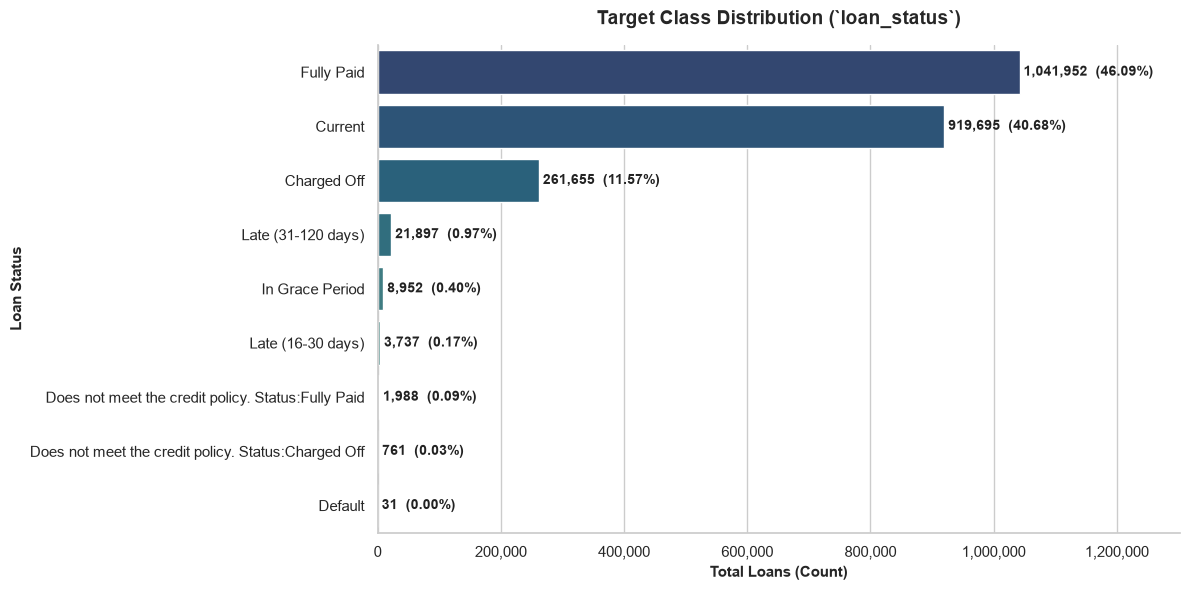

In [19]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns

# ==============================================================================
# 1. DATA AUDIT TABLE
# ==============================================================================
counts = df["loan_status"].value_counts(dropna=False)
percentages = df["loan_status"].value_counts(normalize=True, dropna=False) * 100

summary_df = pd.DataFrame(
    {
        "Count": counts,
        "Percentage (%)": percentages.round(2),
        "Ratio (1 : X)": (counts.max() / counts).round(1),
    }
)

display(
    summary_df.style.format(
        {"Count": "{:,}", "Percentage (%)": "{:.2f}%", "Ratio (1 : X)": "1 : {:.1f}"}
    ).background_gradient(cmap="Blues", subset=["Percentage (%)"])
)

# ==============================================================================
# 2. HORIZONTAL BAR CHART (ELIMINATES LABEL OVERLAP)
# ==============================================================================
plt.figure(figsize=(12, 6))

# Plot horizontal bars
ax = sns.barplot(
    y=counts.index.astype(str),
    x=counts.values,
    palette="crest_r",
    hue=counts.index.astype(str),
    legend=False,
)

# Format X-axis with standard commas (e.g., 1,000,000 instead of scientific 1e6)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))
plt.title(
    "Target Class Distribution (`loan_status`)",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel("Total Loans (Count)", fontsize=11, fontweight="bold")
plt.ylabel("Loan Status", fontsize=11, fontweight="bold")

# Dynamic x-limit to leave headroom for annotations
max_count = counts.max()
plt.xlim(0, max_count * 1.25)

# Annotate each bar clearly at the end
total_samples = len(df)
for p in ax.patches:
    width = p.get_width()
    pct = (width / total_samples) * 100
    ax.annotate(
        f" {int(width):,}  ({pct:.2f}%)",
        (width, p.get_y() + p.get_height() / 2.0),
        va="center",
        ha="left",
        fontsize=10,
        fontweight="bold",
        color="#222222",
    )

sns.despine(left=False, bottom=False)
plt.tight_layout()
plt.show()

In [20]:
import numpy as np
import pandas as pd

# 1. Compute correlation matrix across all numeric columns
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# 2. Mask self-correlation diagonal safely without modifying read-only memory
diag_mask = np.eye(len(corr_matrix), dtype=bool)
corr_matrix_no_diag = corr_matrix.mask(diag_mask)

# 3. Iterate through EVERY column in the dataset (sorted alphabetically)
report = []
for col in sorted(df.columns):
    dtype = df[col].dtype
    null_pct = round((df[col].isnull().sum() / len(df)) * 100, 2)

    if pd.api.types.is_numeric_dtype(df[col]):
        var = round(df[col].var(), 4)
        skew = round(df[col].skew(), 4)

        if col in corr_matrix_no_diag.columns:
            corrs = corr_matrix_no_diag[col].dropna()

            if not corrs.empty:
                abs_corrs = corrs.abs()
                top_col = abs_corrs.idxmax()
                top_val = corrs.loc[top_col]
                top_corr_pct = f"{top_val * 100:+.2f}%"
            else:
                top_col, top_corr_pct = "None (Zero Variance)", "N/A"
        else:
            top_col, top_corr_pct = "N/A", "N/A"
    else:
        var, skew, top_col, top_corr_pct = (
            "N/A (Non-numeric)",
            "N/A",
            "N/A (Categorical/Date)",
            "N/A",
        )

    report.append(
        {
            "Column Name": col,
            "Type": str(dtype),
            "Null (%)": null_pct,
            "Variance": var,
            "Skewness": skew,
            "Most Correlated Feature": top_col,
            "Correlation (%)": top_corr_pct,
        }
    )

# 4. Create and display full report
full_summary_df = pd.DataFrame(report).set_index("Column Name")

with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", 1000
):
    display(full_summary_df)

,Type,Null (%),Variance,Skewness,Most Correlated Feature,Correlation (%)
Column Name,,,,,,
acc_now_delinq,float64,0.00,0.00,22.91,num_tl_30dpd,+80.18%
acc_open_past_24mths,float64,2.21,10.01,1.40,open_rv_24m,+84.94%
addr_state,str,0.00,N/A (Non-numeric),N/A,N/A (Categorical/Date),N/A
all_util,float64,38.32,437.01,-0.12,revol_util,+66.82%
annual_inc,float64,0.00,12700433398.50,493.89,annual_inc_joint,+78.16%
annual_inc_joint,float64,94.66,5499905289.15,21.74,annual_inc,+78.16%
application_type,str,0.00,N/A (Non-numeric),N/A,N/A (Categorical/Date),N/A
avg_cur_bal,float64,3.11,271395147.42,3.87,tot_cur_bal,+82.82%
bc_open_to_buy,float64,3.31,275544542.31,3.74,total_bc_limit,+84.37%


# Data Preprocessing & Feature Engineering
Transforming, encoding, standardization and preparing features
- **You only need to outline your approach here. No need to execute**

In [9]:
df = df[df["loan_status"] != "Current"]
df.shape

(1298438, 148)

In [15]:
df['earliest_cr_line']

0          Apr-2001
1          Jun-1987
2          Apr-2011
3          Feb-2006
4          Dec-2000
             ...   
2260663    Jan-2004
2260664    Mar-2003
2260665    Feb-1995
2260666    Jul-2003
2260667    Apr-2014
Name: earliest_cr_line, Length: 2260668, dtype: str

In [8]:
df["issue_d"].dtype

<StringDtype(na_value=nan)>

In [10]:
# 1. Parse 'issue_d' string into a standard datetime format (defaults missing day to the 1st of the month)
df['issue_d'] = pd.to_datetime(df['issue_d'], format='%b-%Y')
# 2. Parse 'earliest_cr_line' string into a standard datetime format to allow date arithmetic
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], format='%b-%Y')
# 3. Filter out pre-2012 legacy loans to keep only modern credit policy cohorts, using .copy() to avoid SettingWithCopyWarning
df = df[df['issue_d'].dt.year >= 2012].copy()
df.shape

KeyError: 'issue_d'

In [11]:
# 1. Standardize dates
df["issue_dt"] = pd.to_datetime(df["issue_d"], format="%b-%Y")
df["earliest_cr_line_dt"] = pd.to_datetime(
    df["earliest_cr_line"], format="%b-%Y", errors="coerce"
)

# 2. Create join keys
df["year_month"] = df["issue_dt"].dt.to_period("M")
df["issue_year"] = df["issue_dt"].dt.year.astype(int)
df["issue_month"] = df["issue_dt"].dt.month.astype(int)

# 3. Compute credit maturity in months
df["credit_history_months"] = (
    df["issue_dt"].dt.year - df["earliest_cr_line_dt"].dt.year
) * 12 + (df["issue_dt"].dt.month - df["earliest_cr_line_dt"].dt.month)
df["credit_history_months"] = df["credit_history_months"].fillna(
    df["credit_history_months"].median()
)

# 4. Drop raw text date columns
df = df.drop(
    columns=["issue_d", "earliest_cr_line", "earliest_cr_line_dt"],
    errors="ignore",
)

KeyError: 'issue_d'

In [12]:
#pip install fredapi
from fredapi import Fred
# 1. Initialize FRED API
fred = Fred(api_key="a892c899b65968664a0f51a8cf7a5e56")

# 2. List of all 50 US States + DC
us_states = [
    "AL",
    "AK",
    "AZ",
    "AR",
    "CA",
    "CO",
    "CT",
    "DE",
    "DC",
    "FL",
    "GA",
    "HI",
    "ID",
    "IL",
    "IN",
    "IA",
    "KS",
    "KY",
    "LA",
    "ME",
    "MD",
    "MA",
    "MI",
    "MN",
    "MS",
    "MO",
    "MT",
    "NE",
    "NV",
    "NH",
    "NJ",
    "NM",
    "NY",
    "NC",
    "ND",
    "OH",
    "OK",
    "OR",
    "PA",
    "RI",
    "SC",
    "SD",
    "TN",
    "TX",
    "UT",
    "VT",
    "VA",
    "WA",
    "WV",
    "WI",
    "WY",
]

In [13]:
cpi = fred.get_series("CPIAUCSL")
fed_funds = fred.get_series("FEDFUNDS")
treasury_10 = fred.get_series("GS10")
nat_unemployment = fred.get_series("UNRATE")  # National Civilian Unemployment Rate

macro_monthly_df = pd.DataFrame(
    {
        "cpi": cpi,
        "fed_funds_rate": fed_funds,
        "treasury_10y_yield": treasury_10,
        "national_unemployment_rate": nat_unemployment,
    }
).dropna()

macro_monthly_df["year_month"] = macro_monthly_df.index.to_period("M")
macro_monthly_df = macro_monthly_df.reset_index(drop=True)

In [14]:
state_records = []
for state in us_states:
    try:
        series = fred.get_series(f"{state}UR")
        temp_df = pd.DataFrame({"state_unemployment_rate": series})
        temp_df["addr_state"] = state
        temp_df["year_month"] = temp_df.index.to_period("M")
        state_records.append(temp_df)
    except Exception:
        continue

state_monthly_df = pd.concat(state_records, ignore_index=True)
display(state_monthly_df.head())

,state_unemployment_rate,addr_state,year_month
0,6.70,AL,1976-01
1,6.60,AL,1976-02
2,6.60,AL,1976-03
3,6.50,AL,1976-04
4,6.40,AL,1976-05


In [15]:
#Pull annual median household income for every state dynamically
state_income_records = []

for state in us_states:
    try:
        # Standard Census Bureau Median Household Income series code in FRED
        series_id = f"MEHOINUS{state}A672N"
        series = fred.get_series(series_id)

        temp_df = pd.DataFrame({"state_median_income": series})
        temp_df["addr_state"] = state
        temp_df["issue_year"] = temp_df.index.year.astype(int)
        state_income_records.append(temp_df)
    except Exception as e:
        # Fallback for alternative annual code format if needed
        try:
            series_id_alt = f"MEHOINUS{state}A052N"
            series = fred.get_series(series_id_alt)
            temp_df = pd.DataFrame({"state_median_income": series})
            temp_df["addr_state"] = state
            temp_df["issue_year"] = temp_df.index.year.astype(int)
            state_income_records.append(temp_df)
        except Exception:
            continue

# 4. Concatenate into a structured (Year x State) DataFrame
state_yearly_income_df = pd.concat(state_income_records, ignore_index=True)
state_yearly_income_df = state_yearly_income_df.dropna().drop_duplicates(
    subset=["addr_state", "issue_year"]
)

print(
    f"Successfully fetched dynamic yearly median income: {state_yearly_income_df.shape}"
)
display(state_yearly_income_df.head())

Successfully fetched dynamic yearly median income: (2091, 3)


,state_median_income,addr_state,issue_year
0,46660.00,AL,1984
1,47790.00,AL,1985
2,49070.00,AL,1986
3,48960.00,AL,1987
4,47720.00,AL,1988


In [16]:
state_rpp_records = []

for state in us_states:
    try:
        # BEA Regional Price Parities (All Items) series format in FRED
        series_id = f"{state}RPPALL"
        series = fred.get_series(series_id)

        temp_df = pd.DataFrame({"cost_of_living_index": series})
        temp_df["addr_state"] = state
        temp_df["issue_year"] = temp_df.index.year.astype(int)
        state_rpp_records.append(temp_df)
    except Exception:
        continue

# Concatenate and deduplicate into structured (Year x State) DataFrame
state_yearly_rpp_df = pd.concat(state_rpp_records, ignore_index=True)
state_yearly_rpp_df = state_yearly_rpp_df.dropna().drop_duplicates(
    subset=["addr_state", "issue_year"]
)

print(
    f"Successfully fetched yearly dynamic Cost of Living (RPP): {state_yearly_rpp_df.shape}"
)
display(state_yearly_rpp_df.head())

Successfully fetched yearly dynamic Cost of Living (RPP): (867, 3)


,cost_of_living_index,addr_state,issue_year
0,88.90,AL,2008
1,87.79,AL,2009
2,89.78,AL,2010
3,90.01,AL,2011
4,90.56,AL,2012


In [17]:
# -------------------------------------------------------------------------
# Step 1: Merge National Monthly Macro Data (Including national_unemployment_rate)
# -------------------------------------------------------------------------
df = df.merge(
    macro_monthly_df[
        [
            "year_month",
            "cpi",
            "fed_funds_rate",
            "treasury_10y_yield",
            "national_unemployment_rate",
        ]
    ],
    on="year_month",
    how="left",
)

# -------------------------------------------------------------------------
# Step 2: Merge State Monthly Unemployment Rate
# -------------------------------------------------------------------------
df = df.merge(
    state_monthly_df[["year_month", "addr_state", "state_unemployment_rate"]],
    on=["year_month", "addr_state"],
    how="left",
)

# -------------------------------------------------------------------------
# Step 3: Merge Exact Year-by-State Census Median Income
# -------------------------------------------------------------------------
df = df.merge(
    state_yearly_income_df[
        ["issue_year", "addr_state", "state_median_income"]
    ],
    on=["issue_year", "addr_state"],
    how="left",
)

# -------------------------------------------------------------------------
# Step 4: Merge Exact Year-by-State Cost of Living (RPP)
# -------------------------------------------------------------------------
df = df.merge(
    state_yearly_rpp_df[
        ["issue_year", "addr_state", "cost_of_living_index"]
    ],
    on=["issue_year", "addr_state"],
    how="left",
)

# -------------------------------------------------------------------------
# Step 5: Engineer Domain & Spatial Cross-Features
# -------------------------------------------------------------------------
# 1. Income-to-State-Median Ratio
df["income_to_state_median_ratio"] = df["annual_inc"] / (
    df["state_median_income"] + 1
)

# 2. Relative Debt Pressure (Adjusted DTI)
df["adjusted_dti"] = df["dti"] * (
    df["state_unemployment_rate"] / (df["national_unemployment_rate"] + 1e-5)
)

# 3. Real purchasing power adjusted by state Cost of Living (RPP)
df["cost_adjusted_annual_inc"] = df["annual_inc"] / (
    df["cost_of_living_index"] / 100.0
)

# 4. Interest rate spread over 10Y Treasury risk-free benchmark
df["interest_rate_spread"] = df["int_rate"] - df["treasury_10y_yield"]

print(f"All external datasets successfully merged. Current shape: {df.shape}")

All external datasets successfully merged. Current shape: (1298438, 159)


Target distribution (is_default):
is_default
0   0.78
1   0.22
Name: proportion, dtype: float64


findfont: Failed to find font weight heavy, now using 700.


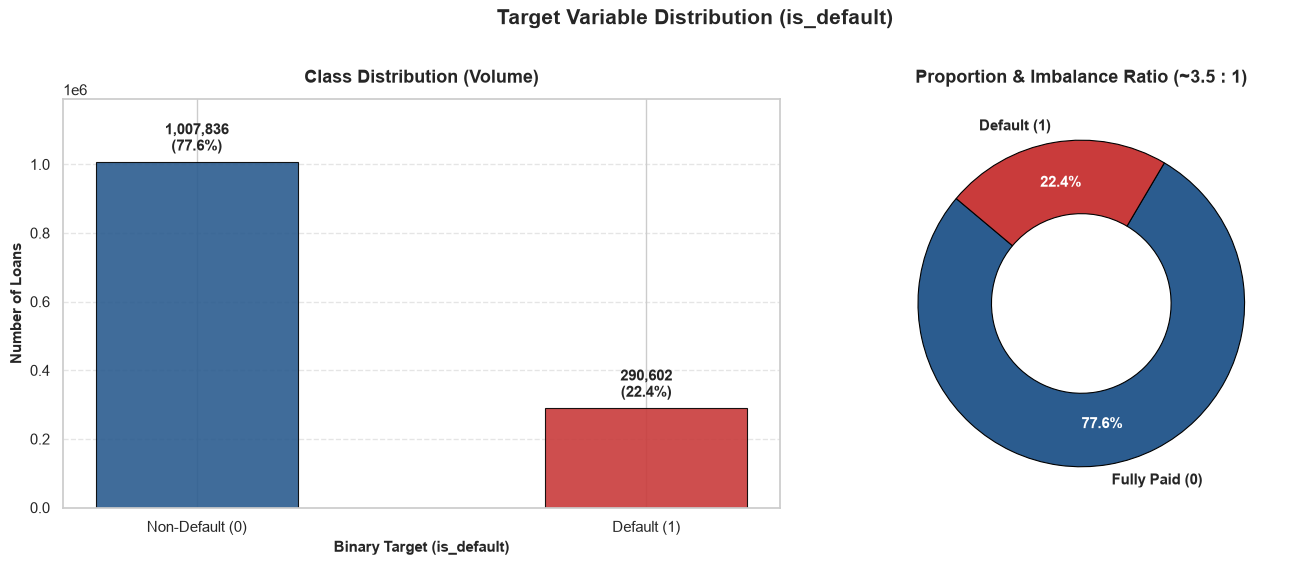

In [18]:
# 1. Define unambiguous target mappings (dropping pre-policy & Current)
status_map = {
    # Good Loans (0)
    "Fully Paid": 0,
    # Bad Loans / Defaulted / Severe Delinquency (1)
    "Charged Off": 1,
    "Default": 1,
    "Late (31-120 days)": 1,
    "Late (16-30 days)": 1,
    "In Grace Period": 1,  # or exclude if using strict terminal states
}

# 2. Filter dataset to include only valid modern cohorts with defined targets
df = df[df["loan_status"].isin(status_map.keys())].copy()
df["is_default"] = df["loan_status"].map(status_map).astype(int)

# 3. Drop the original raw text column
df = df.drop(columns=["loan_status"])

print(f"Target distribution (is_default):\n{df['is_default'].value_counts(normalize=True).round(4)}")


#########################
##PLOTTING##

# Compute counts and percentages
target_counts = df["is_default"].value_counts().sort_index()
total_records = len(df)
percentages = df["is_default"].value_counts(normalize=True).sort_index() * 100
imbalance_ratio = target_counts[0] / target_counts[1]

# Set up dual-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5), gridspec_kw={"width_ratios": [1.2, 1]})
colors = ["#2b5c8f", "#c93b3b"]

# 1. Bar Chart with formatted count & percentage annotations
bars = ax1.bar(
    ["Non-Default (0)", "Default (1)"],
    target_counts.values,
    color=colors,
    width=0.45,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9
)
ax1.set_title("Class Distribution (Volume)", fontsize=13, fontweight="bold", pad=12)
ax1.set_ylabel("Number of Loans", fontsize=11, fontweight="bold")
ax1.set_xlabel("Binary Target (is_default)", fontsize=11, fontweight="bold")
ax1.grid(axis="y", linestyle="--", alpha=0.5)
ax1.set_ylim(0, max(target_counts.values) * 1.18)

for bar in bars:
    height = bar.get_height()
    ax1.annotate(
        f"{height:,.0f}\n({height/total_records*100:.1f}%)",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 5),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontsize=10.5,
        fontweight="bold"
    )

# 2. Modern Donut Chart
wedges, texts, autotexts = ax2.pie(
    target_counts.values,
    labels=["Fully Paid (0)", "Default (1)"],
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    wedgeprops=dict(width=0.45, edgecolor="black", linewidth=0.8),
    textprops={"fontsize": 11, "fontweight": "bold"},
    pctdistance=0.75
)
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontweight("bold")
    autotext.set_fontsize(11)

ax2.set_title(f"Proportion & Imbalance Ratio (~{imbalance_ratio:.1f} : 1)", fontsize=13, fontweight="bold", pad=12)

plt.suptitle("Target Variable Distribution (is_default)", fontsize=15, fontweight="heavy", y=1.02)
plt.tight_layout()
plt.show()

In [33]:
print(f" emp_lenght format: {df["emp_length"].unique()}")
print(f" sub_grade format: {df["sub_grade"].unique()}")
print(f" initial_list_status format: {df["initial_list_status"].unique()}")
print(f" disbursement_method format: {df["disbursement_method"].unique()}")
print(f" application_type format: {df["application_type"].unique()}")
print(f" home_ownership format: {df["home_ownership"].unique()}")
print(f" purpose format: {df["purpose"].unique()}")
print(f" verification_status format: {df["verification_status"].unique()}")


 emp_lenght format: <ArrowStringArray>
[  '5 years',  '< 1 year', '10+ years',   '3 years',   '4 years',    '1 year',
   '8 years',         nan,   '2 years',   '6 years',   '9 years',   '7 years']
Length: 12, dtype: str
 sub_grade format: <ArrowStringArray>
['D5', 'C4', 'A3', 'B3', 'E5', 'D1', 'C1', 'A4', 'E1', 'B5', 'E4', 'B1', 'D2',
 'B4', 'B2', 'C3', 'A5', 'C2', 'A2', 'C5', 'D3', 'D4', 'E3', 'E2', 'A1', 'G2',
 'G1', 'F1', 'G4', 'F2', 'F5', 'F4', 'F3', 'G5', 'G3']
Length: 35, dtype: str
 initial_list_status format: <ArrowStringArray>
['w', 'f']
Length: 2, dtype: str
 disbursement_method format: <ArrowStringArray>
['Cash', 'DirectPay']
Length: 2, dtype: str
 application_type format: <ArrowStringArray>
['Joint App', 'Individual']
Length: 2, dtype: str
 home_ownership format: <ArrowStringArray>
['MORTGAGE', 'RENT', 'OWN', 'ANY', 'NONE', 'OTHER']
Length: 6, dtype: str
 purpose format: <ArrowStringArray>
['debt_consolidation',        'credit_card',              'other',
              'hou

In [19]:
# 1. emp_length -> Ordinal numeric (0 to 10), missing filled with -1
emp_map = {
    "< 1 year": 0,
    "1 year": 1,
    "2 years": 2,
    "3 years": 3,
    "4 years": 4,
    "5 years": 5,
    "6 years": 6,
    "7 years": 7,
    "8 years": 8,
    "9 years": 9,
    "10+ years": 10,
}

if "emp_length" in df.columns:
    df["emp_length"] = df["emp_length"].map(emp_map).fillna(-1).astype("Int64")

# 2. sub_grade -> Monotonic risk integer (1 to 35) using nullable Int64
grades = ["A", "B", "C", "D", "E", "F", "G"]
sub_grades_order = [f"{g}{i}" for g in grades for i in range(1, 6)]
sub_grade_map = {sg: i + 1 for i, sg in enumerate(sub_grades_order)}

if "sub_grade" in df.columns:
    # Use "Int64" (capital I) to support any non-finite / missing values safely
    df["sub_grade"] = df["sub_grade"].map(sub_grade_map).astype("Int64")

# 3. Binary columns -> 0 / 1 mapping
if "initial_list_status" in df.columns:
    df["initial_list_status"] = (df["initial_list_status"] == "w").astype("Int64")

if "disbursement_method" in df.columns:
    df["disbursement_method"] = (df["disbursement_method"] == "DirectPay").astype("Int64")

if "application_type" in df.columns:
    df["application_type"] = (df["application_type"] == "Joint App").astype("Int64")

# 4. home_ownership -> Collapse rare categories
if "home_ownership" in df.columns:
    df["home_ownership"] = df["home_ownership"].replace(
        ["ANY", "NONE", "OTHER"], "OTHER"
    )

# 5. One-Hot Encoding for nominal columns
ohe_cols = [
    col
    for col in ["home_ownership", "purpose", "verification_status"]
    if col in df.columns
]
if ohe_cols:
    df = pd.get_dummies(df, columns=ohe_cols, drop_first=True, dtype=int)

# Create binary indicator for collections (1 if has collections, 0 if clean)
df['has_collections'] = (df['tot_coll_amt'] > 0).astype(int)

# Create binary indicator for severe 120+ days late accounts (1 if has derogatory mark, 0 if clean)
df['has_major_derogatory'] = (df['num_accts_ever_120_pd'] > 0).astype(int)

print(f"Feature engineering successful. Clean shape: {df.shape}")

Feature engineering successful. Clean shape: (1298438, 176)


In [20]:
# ---------------------------------------------------------
# Categorized Columns to Drop
# ---------------------------------------------------------

# 1. 100% Empty / Identifier Columns
empty_and_id_cols = ["id", "member_id", "url"]

# 2. Post-origination hardship, collection & settlement target leakage
target_leakage_cols = [
    "collection_recovery_fee",
    "debt_settlement_flag",
    "debt_settlement_flag_date",
    "deferral_term",
    "hardship_amount",
    "hardship_dpd",
    "hardship_end_date",
    "hardship_flag",
    "hardship_last_payment_amount",
    "hardship_length",
    "hardship_loan_status",
    "hardship_payoff_balance_amount",
    "hardship_reason",
    "hardship_start_date",
    "hardship_status",
    "hardship_type",
    "last_credit_pull_d",
    "last_pymnt_amnt",
    "last_pymnt_d",
    "next_pymnt_d",
    "orig_projected_additional_accrued_interest",
    "out_prncp",
    "out_prncp_inv",
    "payment_plan_start_date",
    "recoveries",
    "settlement_amount",
    "settlement_date",
    "settlement_percentage",
    "settlement_status",
    "settlement_term",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_int",
    "total_rec_late_fee",
    "total_rec_prncp",
]

# 3. High Missingness (>60% to >98% Null)
high_missingness_cols = [
    "all_util",
    "annual_inc_joint",
    "desc",
    "dti_joint",
    "il_util",
    "inq_fi",
    "inq_last_12m",
    "max_bal_bc",
    "mths_since_last_major_derog",
    "mths_since_last_record",
    "mths_since_rcnt_il",
    "mths_since_recent_bc_dlq",
    "mths_since_recent_revol_delinq",
    "open_acc_6m",
    "open_act_il",
    "open_il_12m",
    "open_il_24m",
    "open_rv_12m",
    "open_rv_24m",
    "revol_bal_joint",
    "sec_app_chargeoff_within_12_mths",
    "sec_app_collections_12_mths_ex_med",
    "sec_app_earliest_cr_line",
    "sec_app_inq_last_6mths",
    "sec_app_mort_acc",
    "sec_app_mths_since_last_major_derog",
    "sec_app_num_rev_accts",
    "sec_app_open_acc",
    "sec_app_open_act_il",
    "sec_app_revol_util",
    "total_bal_il",
    "total_cu_tl",
    "verification_status_joint",
]

# 4. Features with near-perfect collinearity / duplication (>95%)
collinear_redundant_cols = [
    "funded_amnt",  # 99.95% duplicate of loan_amnt
    "funded_amnt_inv",  # 99.88% duplicate of loan_amnt
    "grade",  # Subsumed by sub_grade
    "num_rev_tl_bal_gt_0",  # 98.20% duplicate of num_actv_rev_tl
    "num_sats",  # 99.87% duplicate of open_acc
    "tax_liens",  # Captured inside pub_rec
    "tot_cur_bal",  # 97.38% duplicate of tot_hi_cred_lim
    'annual_inc',                 # Preserved by 'cost_adjusted_annual_inc'
    'income_to_state_median_ratio',# Highly collinear with cost_adjusted_annual_inc (98.7%)
    'int_rate',                   # Preserved by 'interest_rate_spread'
    'installment',                # Preserved by 'loan_amnt' (95.3% collinear)
    'dti',                        # Preserved by 'adjusted_dti'
    'mo_sin_old_rev_tl_op',        # Preserved by 'credit_history_months' (91.7% collinear)
    'addr_state',
    'tot_coll_amt',
    'num_accts_ever_120_pd',
    
]

# 5. Near-zero variance / constant values (>99% constant)
zero_variance_cols = [
    "acc_now_delinq",
    "chargeoff_within_12_mths",
    "collections_12_mths_ex_med",
    "delinq_amnt",
    "num_tl_120dpd_2m",
    "num_tl_30dpd",
    "policy_code",
    "pymnt_plan",
    "purpose_educational",
    "home_ownership_OTHER",
    "purpose_wedding",
]

# 6. High-cardinality messy text prone to overfitting
high_cardinality_text_cols = ["emp_title", "title", "zip_code"]

# 7. Metadata / temporal columns used only for splitting and joining
temporal_split_cols = ["issue_d","issue_dt", "year_month", "issue_year"]

# ---------------------------------------------------------
# Combine and Drop
# ---------------------------------------------------------

drop_categories = {
    "Empty and ID": empty_and_id_cols,
    "Target Leakage": target_leakage_cols,
    "High Missingness": high_missingness_cols,
    "Collinear Redundancy": collinear_redundant_cols,
    "Zero / Near-Zero Variance": zero_variance_cols,
    "High Cardinality Text": high_cardinality_text_cols,
    "Temporal Metadata": temporal_split_cols,
}

all_cols_to_drop = []
for category_name, col_list in drop_categories.items():
    all_cols_to_drop.extend(col_list)

# Remove any accidental duplicates in the list
all_cols_to_drop = list(dict.fromkeys(all_cols_to_drop))

# Drop from df
for col in all_cols_to_drop:
    if col in df.columns:
        df = df.drop(columns=[col])

print(f"Total columns removed: {len(all_cols_to_drop)}")
print(f"Remaining clean feature count: {df.shape[1]}")

Total columns removed: 105
Remaining clean feature count: 72


In [21]:
def skew_calc(df):
    """Diagnoses skewness for numeric columns and recommends transformations based on

    data constraints (strictly positive, zeros present, negative values).
    """
    numeric_df = df.select_dtypes(include="number")
    results = []

    for col in numeric_df.columns:
        # Skip binary or ID columns (2 or fewer unique values)
        if numeric_df[col].nunique() <= 2:
            continue

        val = numeric_df[col].skew()
        min_val = numeric_df[col].min()

        # Classify Degree and Direction
        if val < -1:
            degree, direction = "Highly", "Left"
        elif -1 <= val <= -0.5:
            degree, direction = "Moderately", "Left"
        elif -0.5 < val < 0.5:
            degree, direction = "Symmetrical", "None"
        elif 0.5 <= val <= 1:
            degree, direction = "Moderately", "Right"
        else:
            degree, direction = "Highly", "Right"

        # Recommend Transformation based on Decision Matrix
        if degree == "Symmetrical":
            rec_trans = "None"
        elif min_val < 0:
            # Contains negative values -> Yeo-Johnson
            rec_trans = "Yeo-Johnson"
        elif min_val == 0:
            # Contains zeros, but no negatives
            if degree == "Highly" and direction == "Right":
                rec_trans = "Log Plus One (log(x + 1))"
            else:
                rec_trans = "Yeo-Johnson"
        else:
            # Strictly positive (min_val > 0) -> Box-Cox
            rec_trans = "Box-Cox"

        results.append(
            {
                "Feature": col,
                "Skewness": round(val, 4),
                "Degree": degree,
                "Direction": direction,
                "Min_Value": min_val,
                "Recommended_Transformation": rec_trans,
            }
        )

    return pd.DataFrame(results)

In [22]:
def plot_transformations(df, skew_table):
    """
    Applies the recommended transformation to each column, then plots the before and after 
    distributions side by side with the skewness degree on each subplot.
    """
# Your code here
    num_rows= len(skew_table)
    normal_table = df.copy()
    for i in range(0, num_rows):
        row = skew_table.iloc[i]
        feature_name = row["Feature"]
        rec = row["Recommended_Transformation"]
        if rec == 'Log Plus One (log(x + 1))':
            normal_table[feature_name] = np.log1p(normal_table[feature_name])
        elif rec == 'Yeo-Johnson':
            pt_yeo= PowerTransformer(method = 'yeo-johnson')
            normal_table[feature_name] = pt_yeo.fit_transform(normal_table[[feature_name]])
        elif rec == 'Box-Cox':
            pt_boxcox= PowerTransformer(method = 'box-cox')
            normal_table[feature_name] = pt_boxcox.fit_transform(normal_table[[feature_name]])
        else:
            normal_table[feature_name] = normal_table[feature_name]
                                                              
             # ----------------- PLOTTING -----------------
        
        # 1. Calculate dynamic statistics
        orig_skew = df[feature_name].skew()
        trans_skew = normal_table[feature_name].skew()
        
        # 2. Initialize figure with custom background
        fig, axes = plt.subplots(1, 2, figsize=(12, 5), facecolor="#F8F9FA")
        
        # --- Left Plot: Original Feature Distribution ---
        ax0 = axes[0]
        ax0.set_facecolor("#FFFFFF")
        sns.histplot(
            df[feature_name],
            ax=ax0,
            kde=True,
            color="#2B5C8F",  # Professional Deep Blue
            edgecolor="white",
            linewidth=0.8,
            stat="density",
            line_kws={"linewidth": 2, "color": "#12283E"},  # Darker KDE line
        )
        
        ax0.set_title(
            f"ORIGINAL DISTRIBUTION\n{feature_name.upper()}",
            fontsize=11,
            fontweight="bold",
            color="#2C3E50",
            pad=12,
        )
        ax0.set_xlabel(f"{feature_name} (Original Scale)", fontsize=10, labelpad=8)
        ax0.set_ylabel("Density", fontsize=10, labelpad=8)
        
        # Add a metric badge/text box inside the plot
        ax0.text(
            0.95,
            0.92,
            f"Skewness: {orig_skew:+.2f}",
            transform=ax0.transAxes,
            fontsize=9.5,
            fontweight="bold",
            color="#900C3F" if abs(orig_skew) > 0.5 else "#1E8449",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="#FADBD8" if abs(orig_skew) > 0.5 else "#D4EFDF",
                edgecolor="none",
                alpha=0.85,
            ),
            ha="right",
            va="top",
        )
        
        # --- Right Plot: Transformed Feature Distribution ---
        ax1 = axes[1]
        ax1.set_facecolor("#FFFFFF")
        sns.histplot(
            normal_table[feature_name],
            ax=ax1,
            kde=True,
            color="#27AE60",  # Professional Emerald Green
            edgecolor="white",
            linewidth=0.8,
            stat="density",
            line_kws={"linewidth": 2, "color": "#195B32"},  # Darker KDE line
        )
        
        ax1.set_title(
            f"TRANSFORMED [{rec.upper()}]\n{feature_name.upper()}",
            fontsize=11,
            fontweight="bold",
            color="#2C3E50",
            pad=12,
        )
        ax1.set_xlabel(f"{feature_name} ({rec} Scale)", fontsize=10, labelpad=8)
        ax1.set_ylabel("Density", fontsize=10, labelpad=8)
        
        # Add a metric badge/text box inside the transformed plot
        ax1.text(
            0.95,
            0.92,
            f"Skewness: {trans_skew:+.2f}",
            transform=ax1.transAxes,
            fontsize=9.5,
            fontweight="bold",
            color="#1E8449" if abs(trans_skew) <= 0.5 else "#900C3F",
            bbox=dict(
                boxstyle="round,pad=0.4",
                facecolor="#D4EFDF" if abs(trans_skew) <= 0.5 else "#FADBD8",
                edgecolor="none",
                alpha=0.85,
            ),
            ha="right",
            va="top",
        )
        
        # Fine-tune gridlines and borders for both plots
        for ax in axes:
            ax.grid(True, linestyle="--", alpha=0.5, color="#BDC3C7")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
            ax.spines["left"].set_color("#BDC3C7")
            ax.spines["bottom"].set_color("#BDC3C7")
        
        plt.tight_layout()
        plt.show()
                                                                  


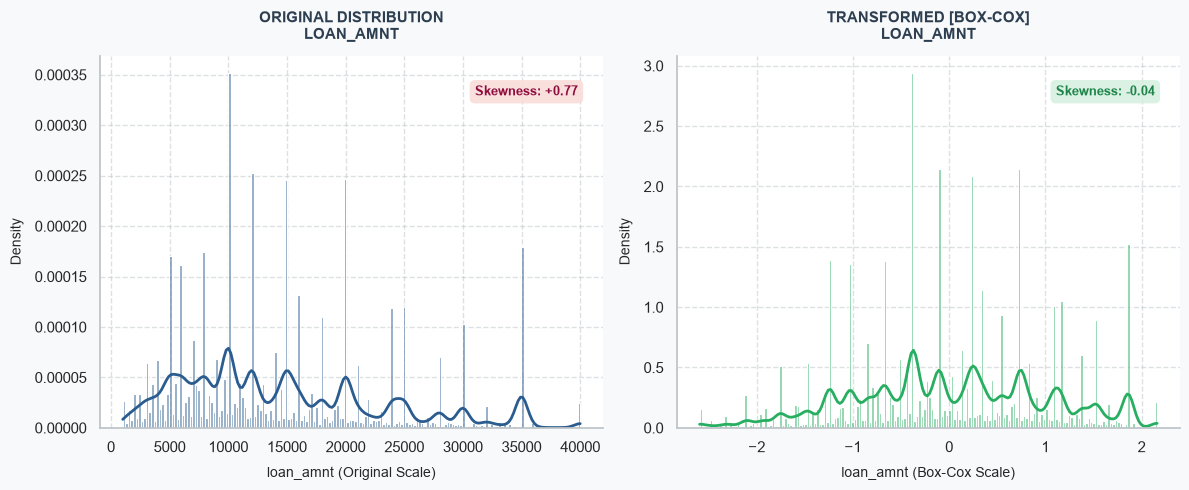

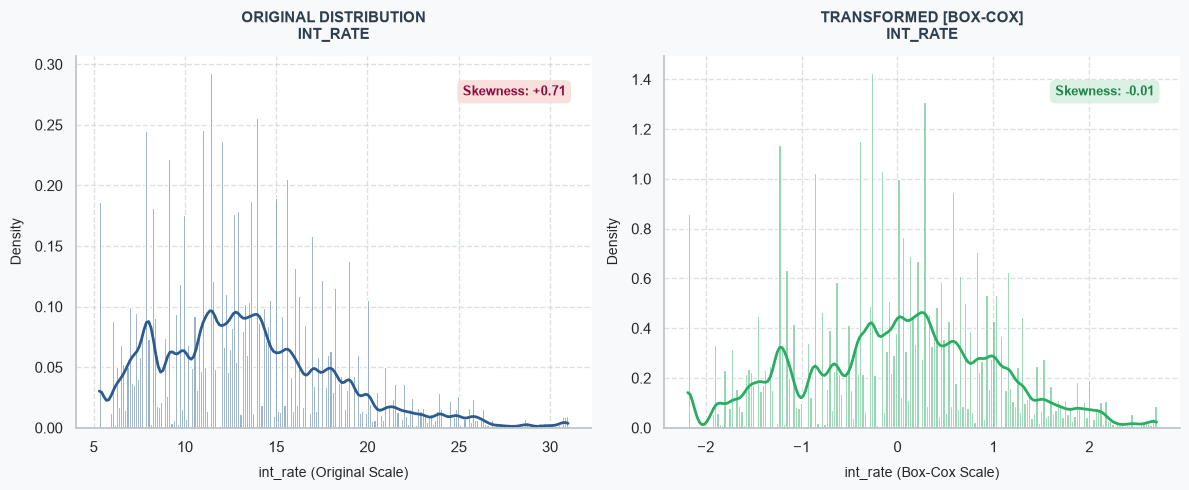

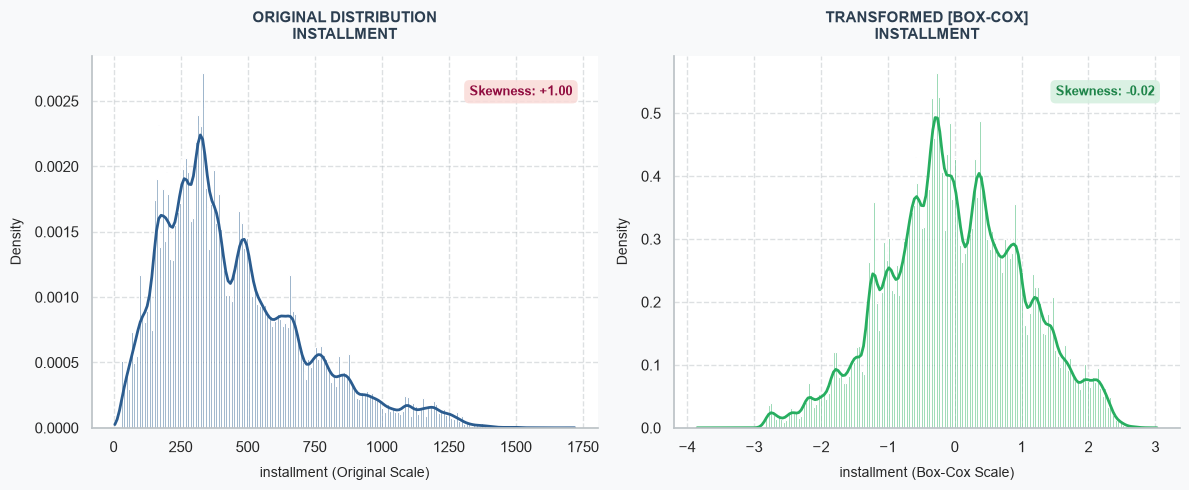

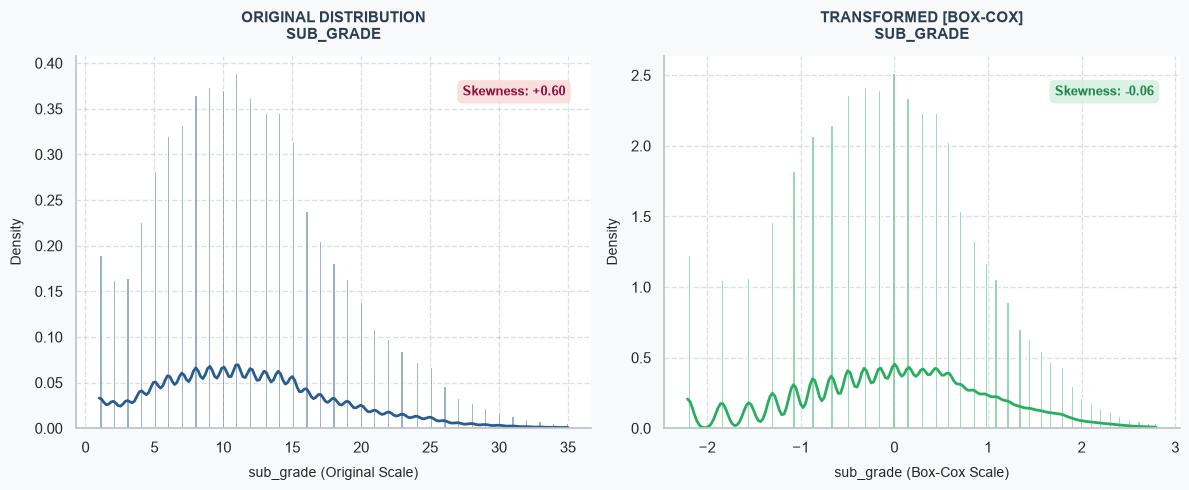

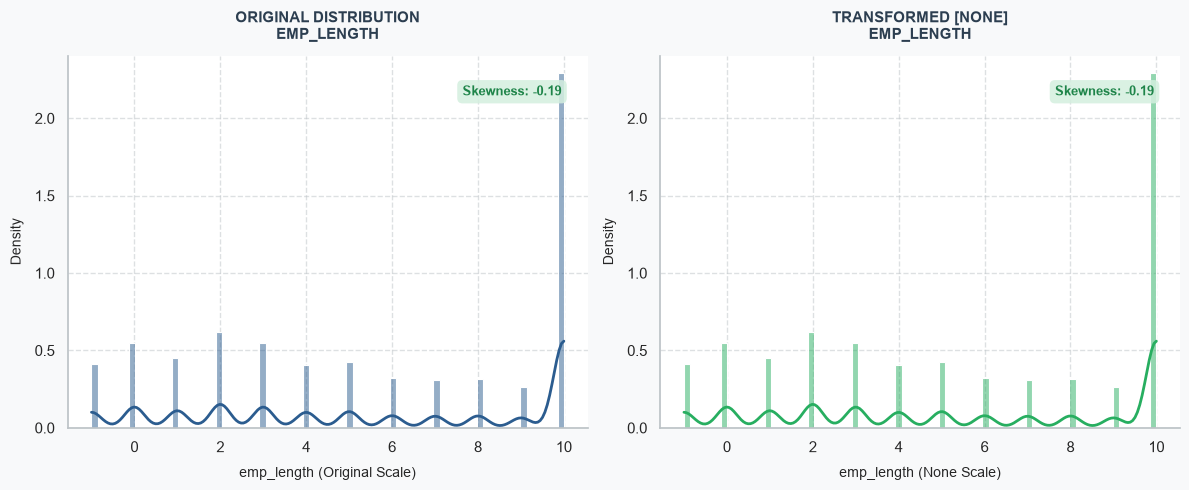

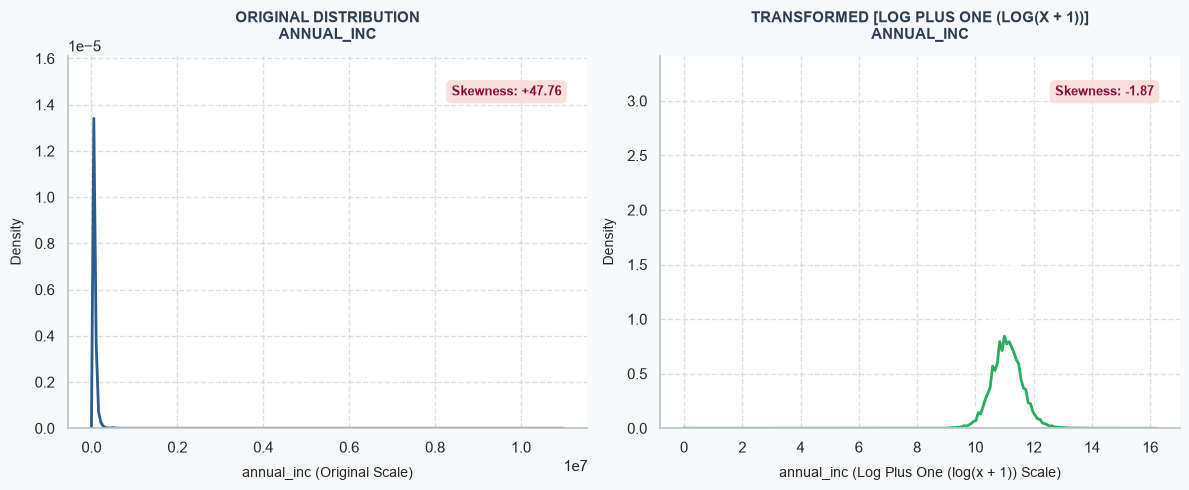

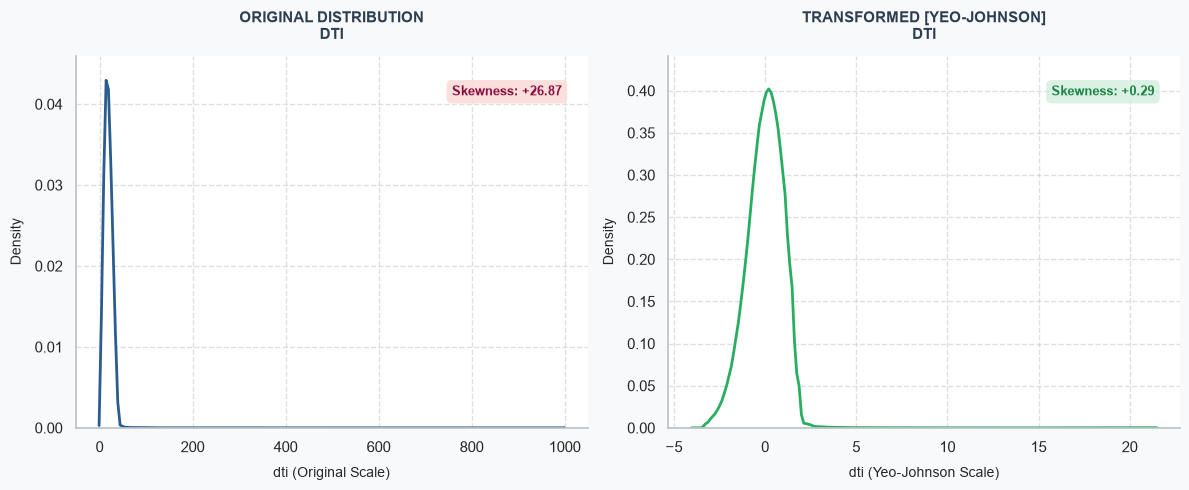

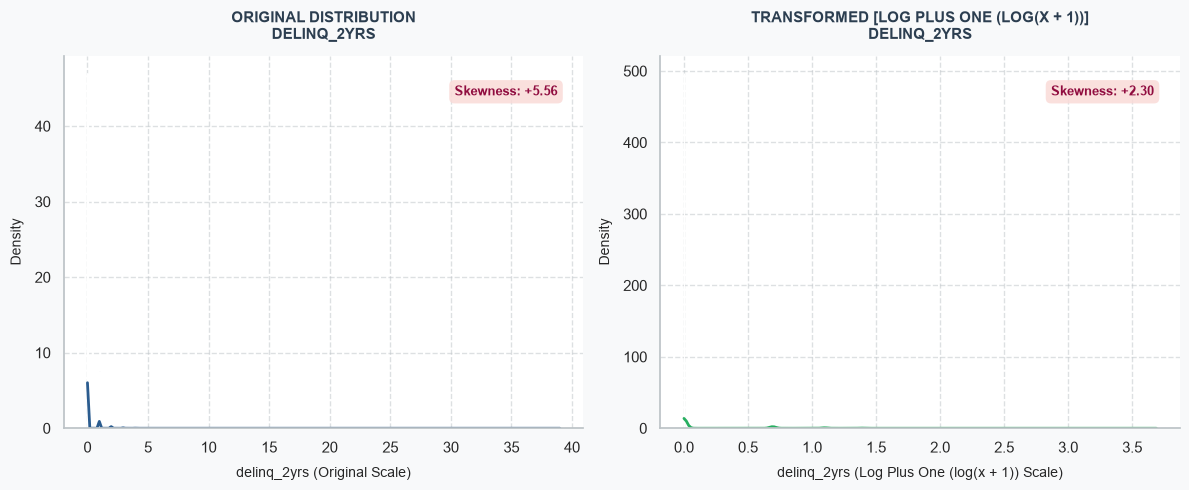

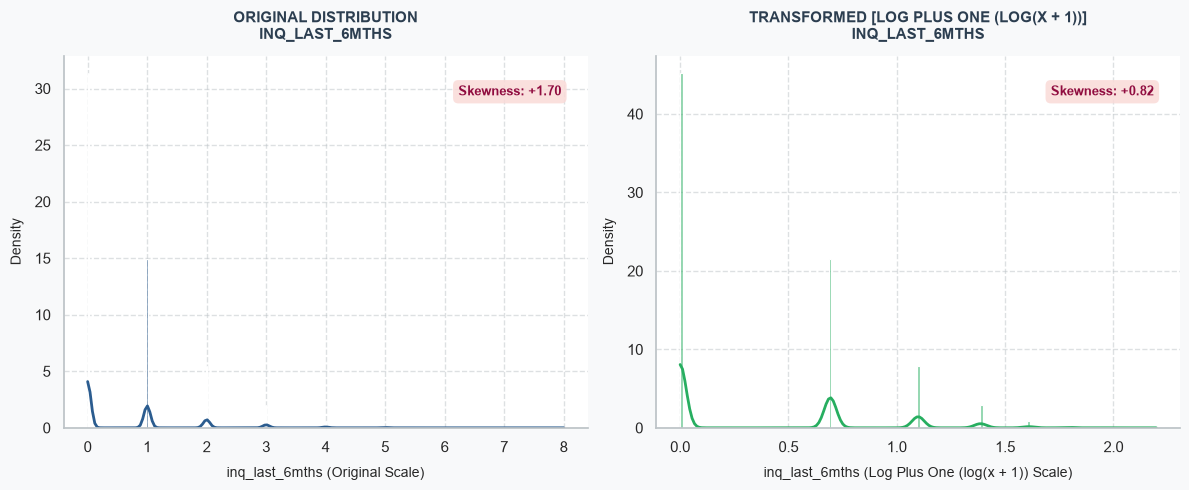

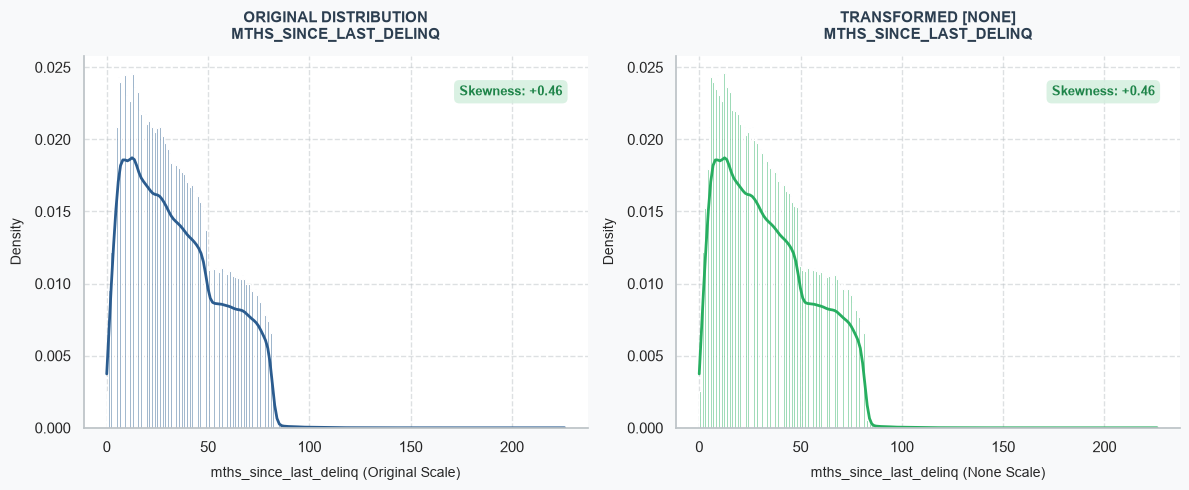

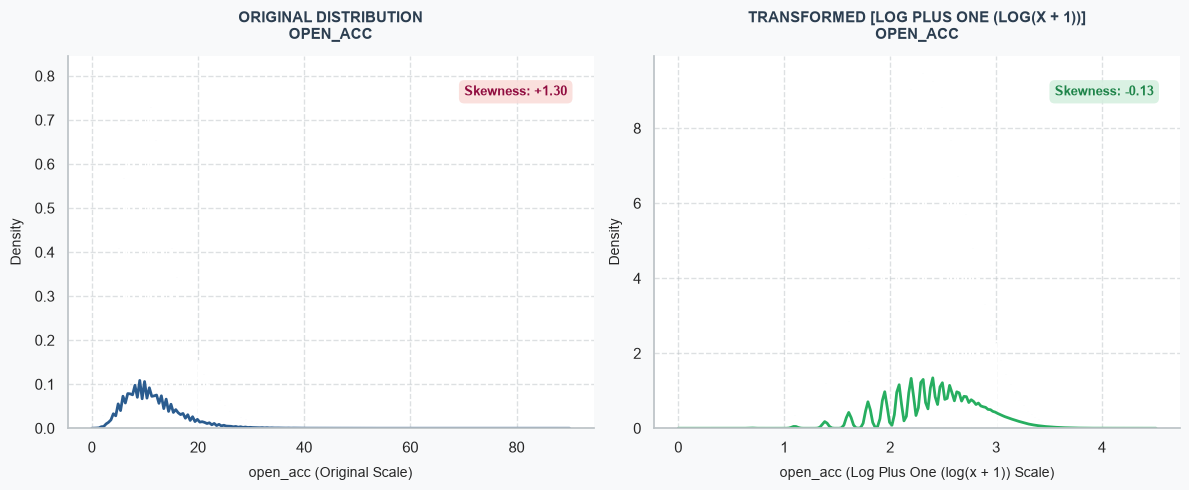

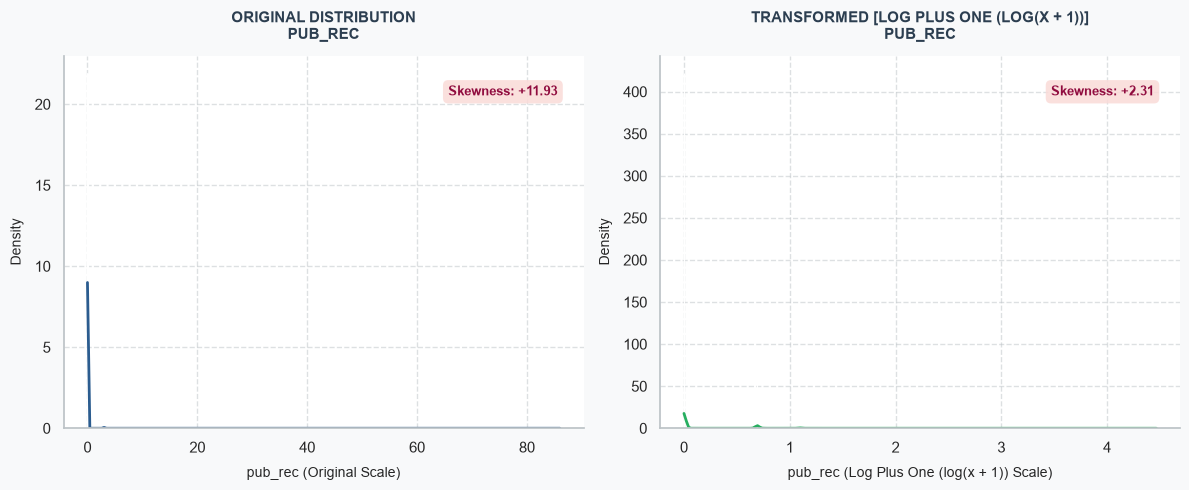

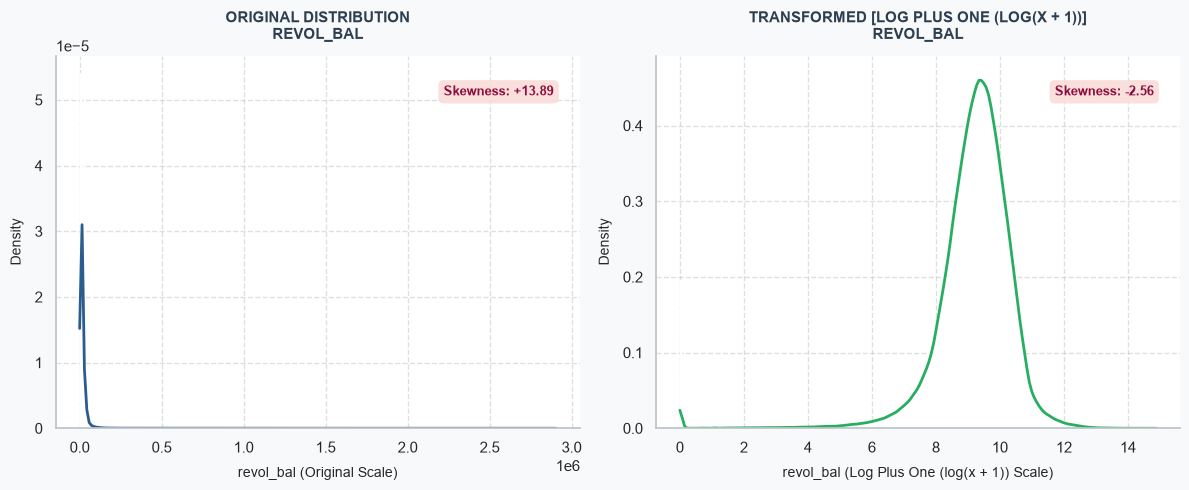

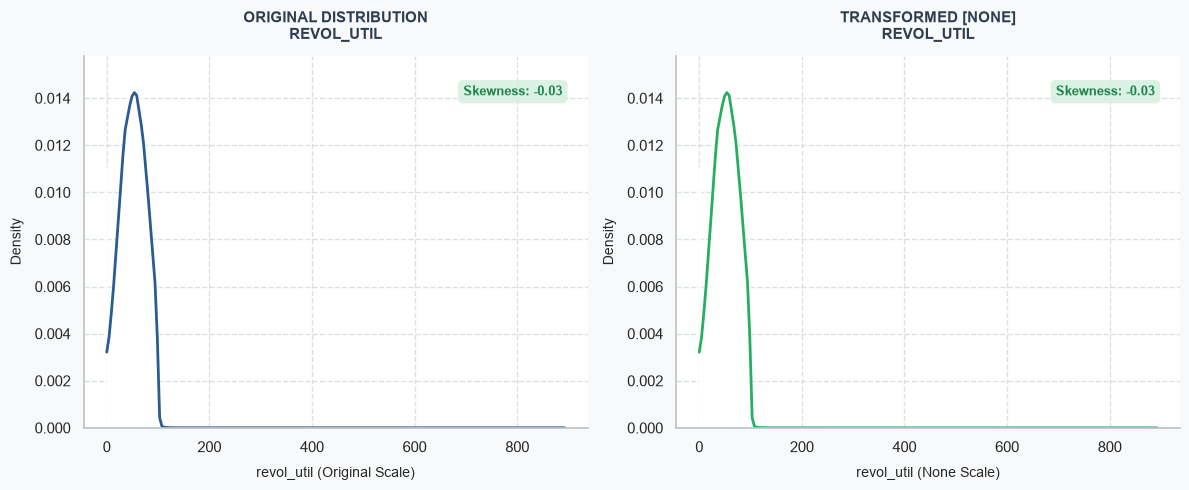

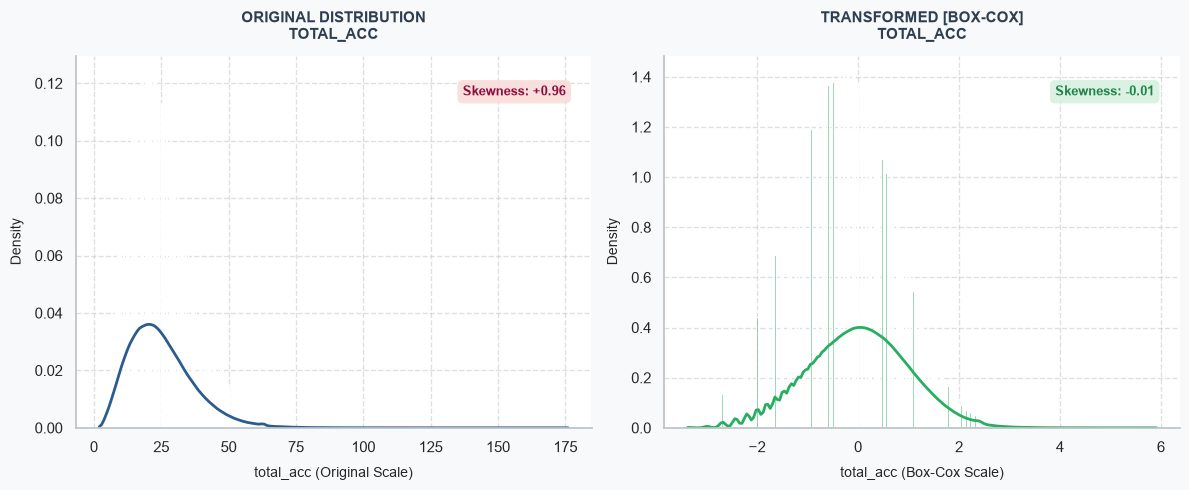

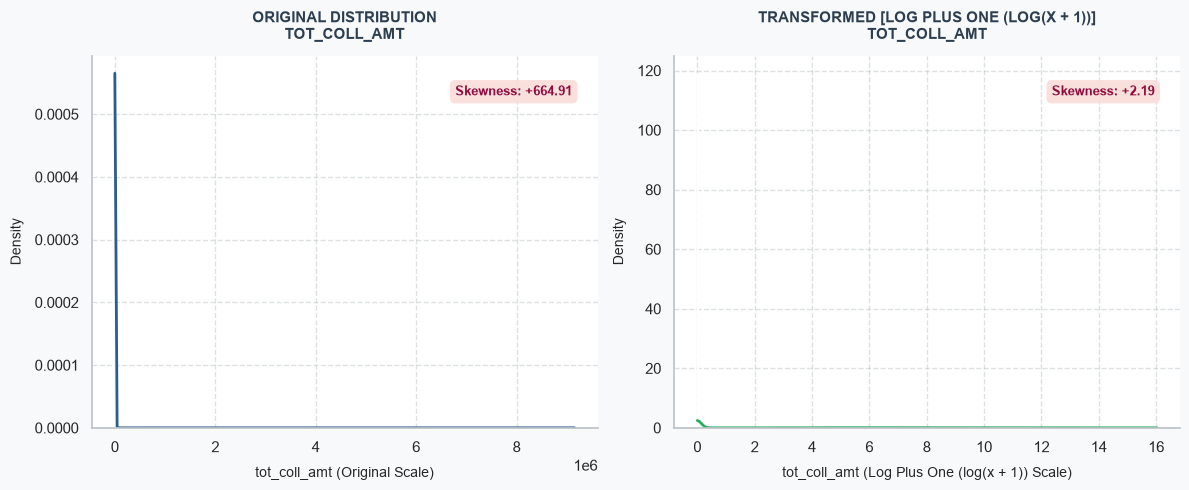

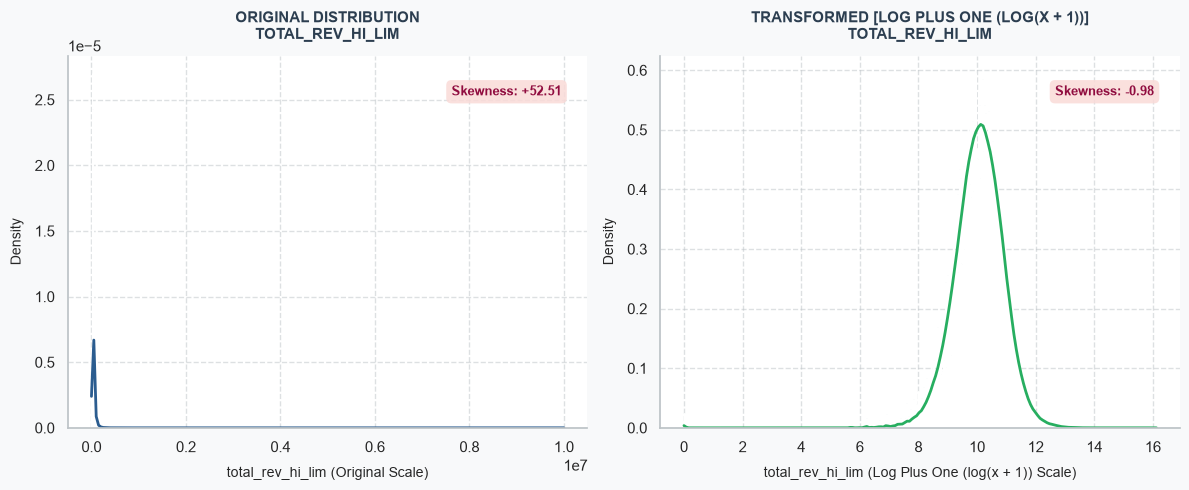

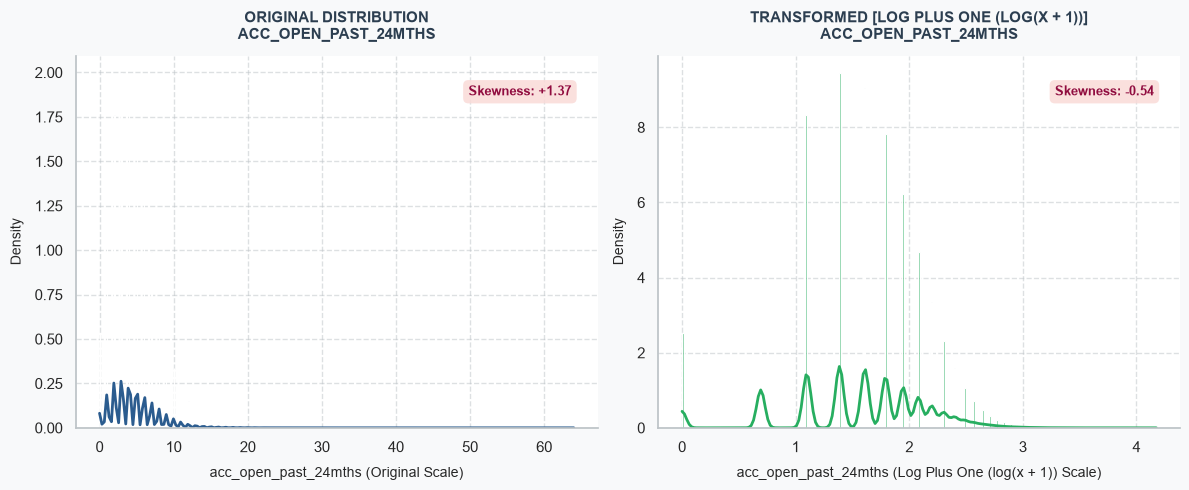

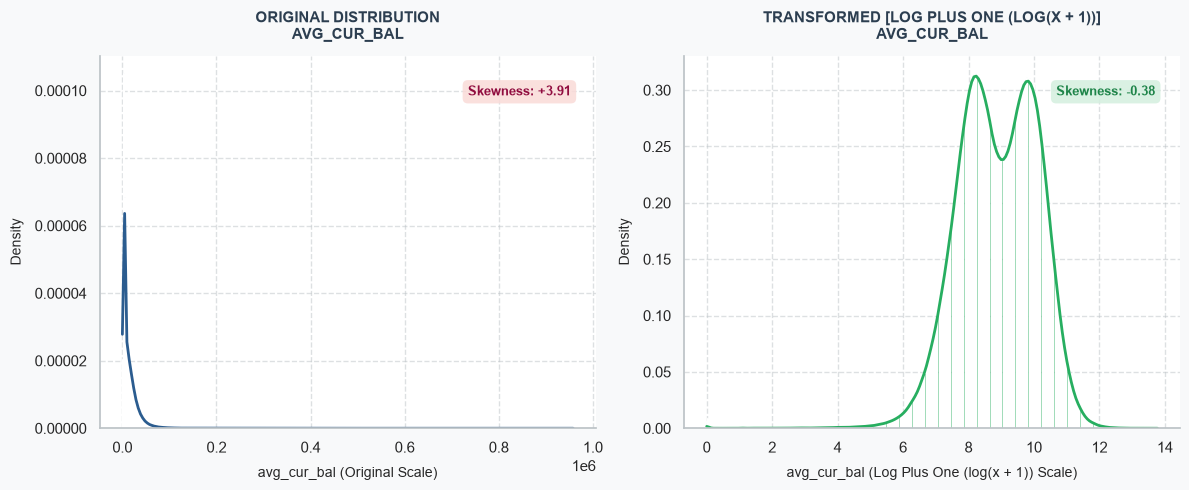

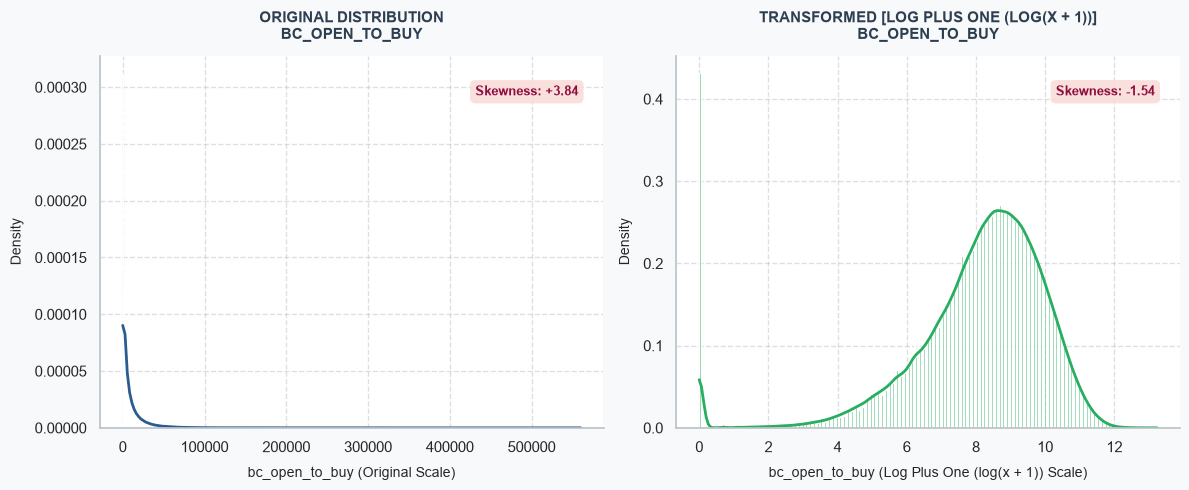

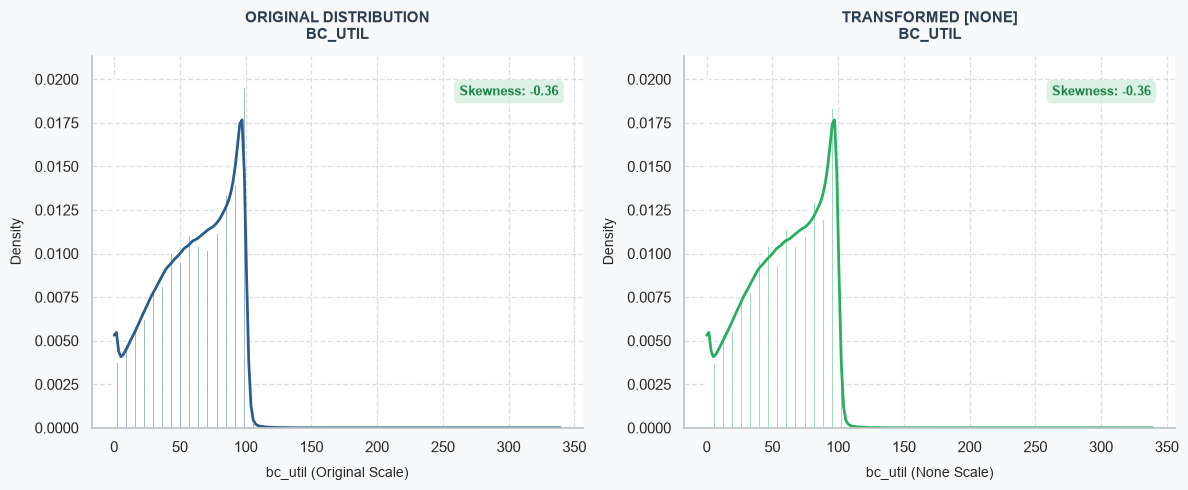

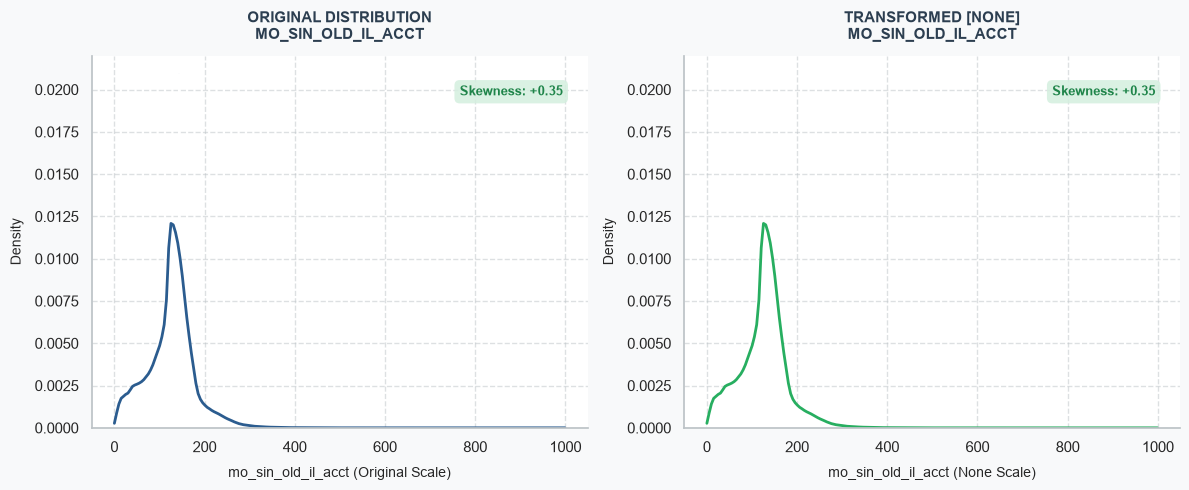

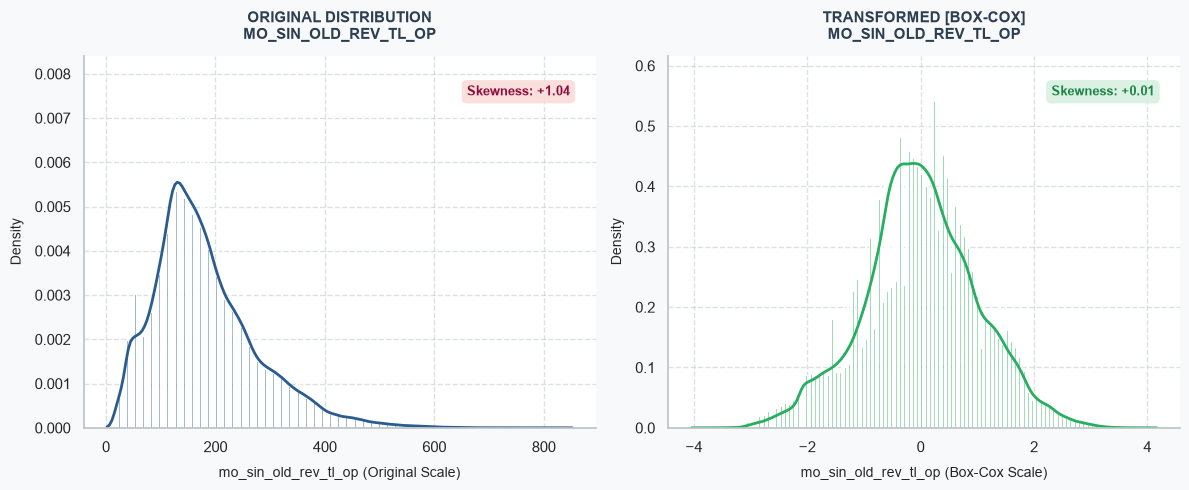

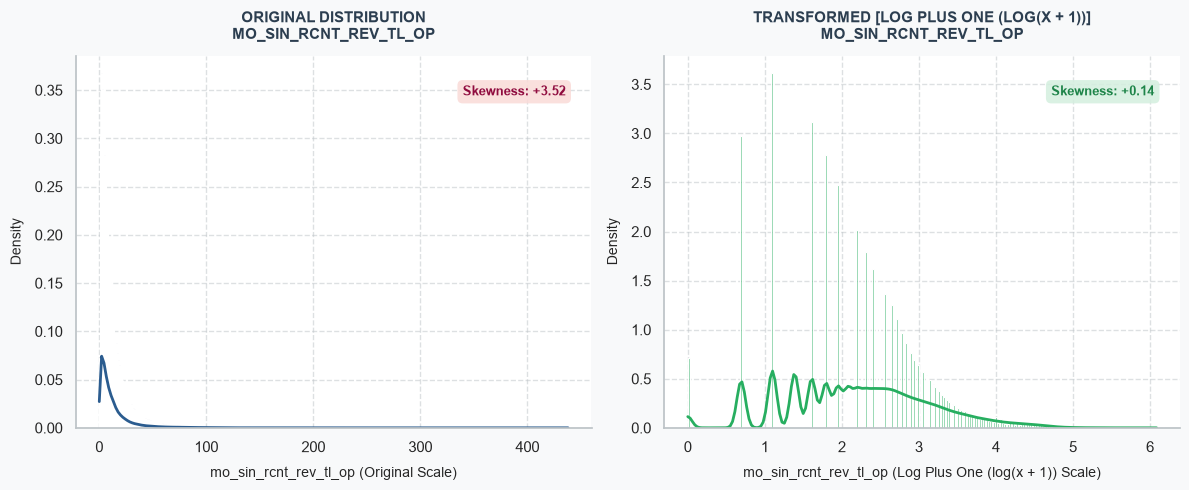

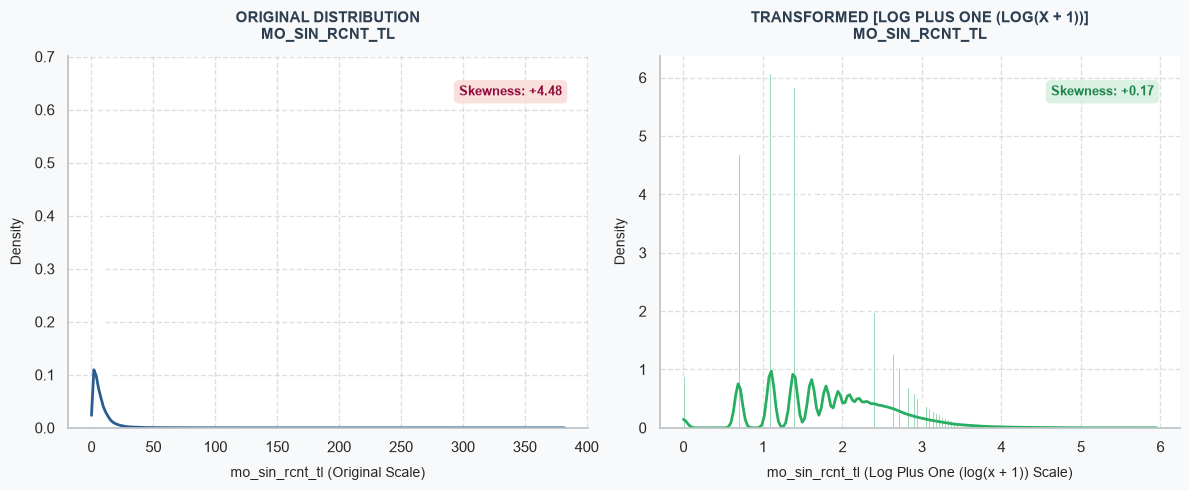

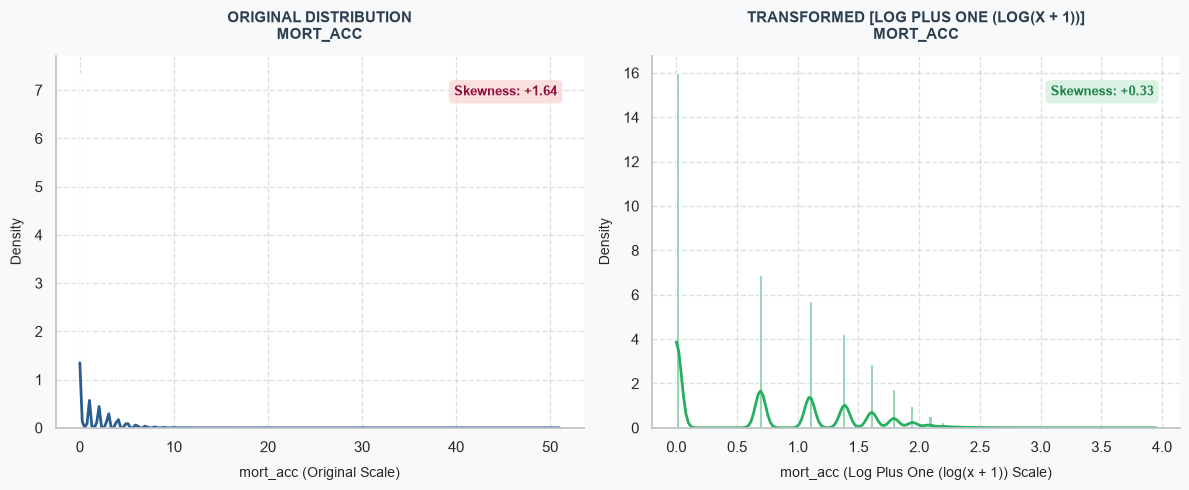

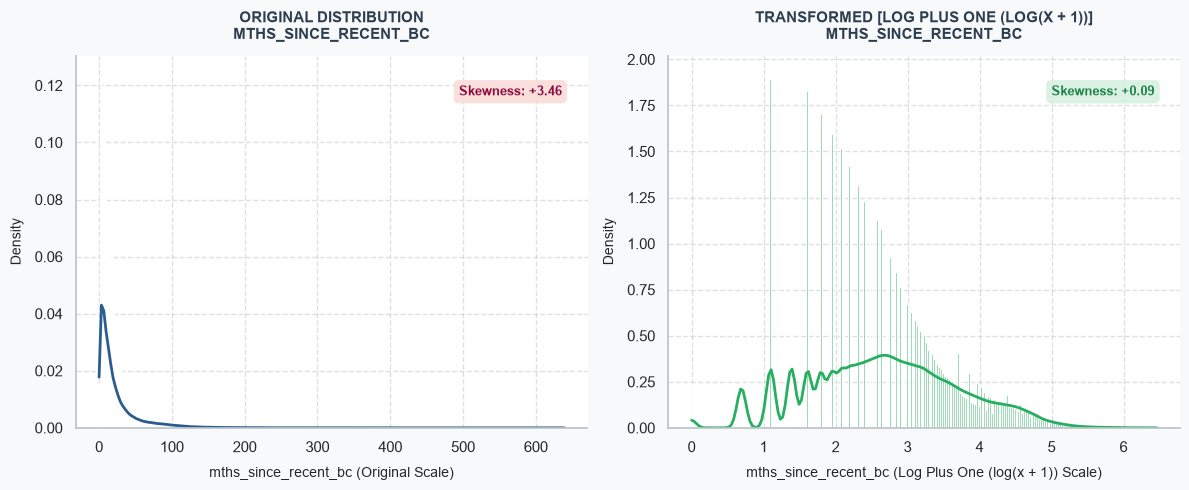

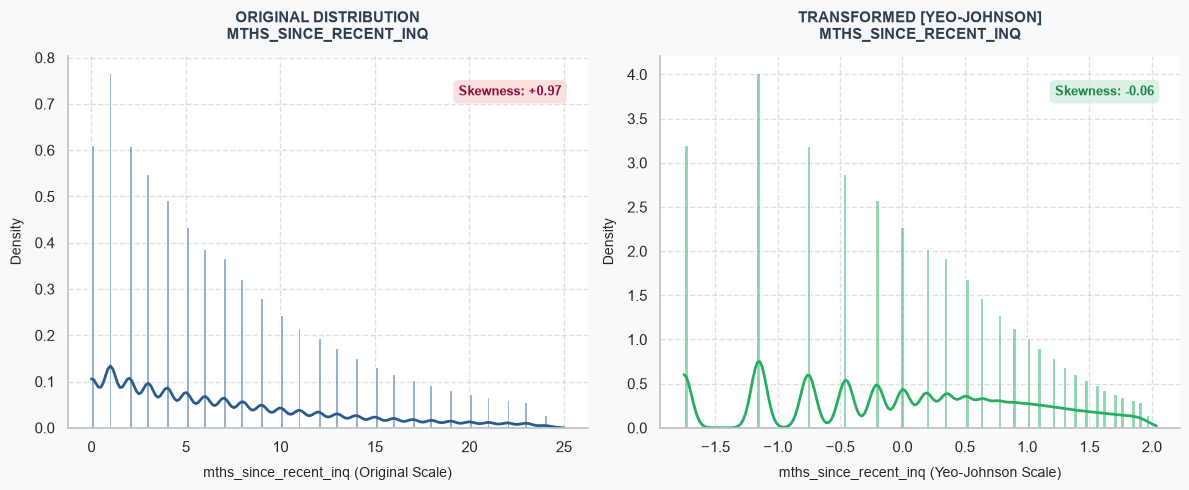

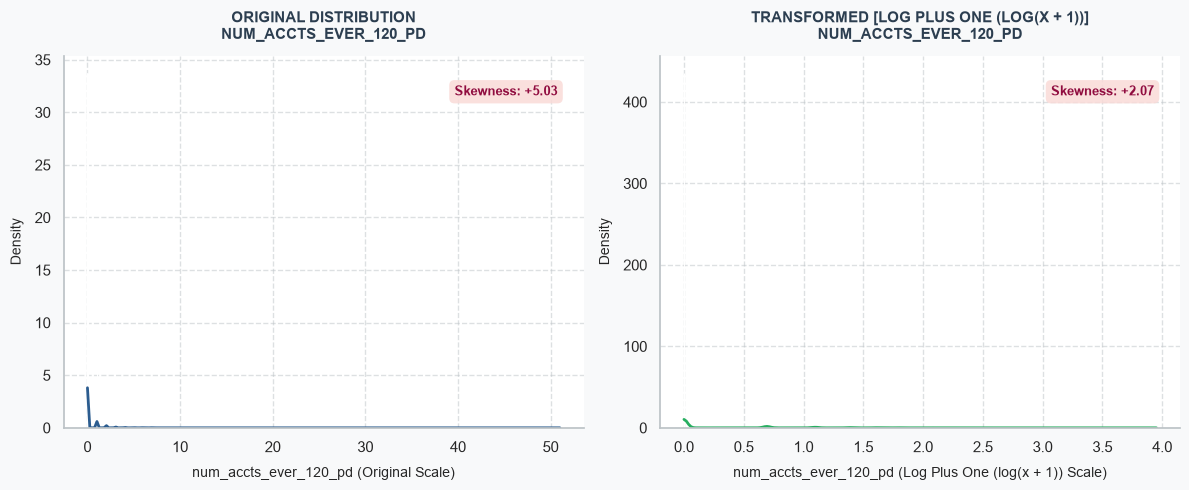

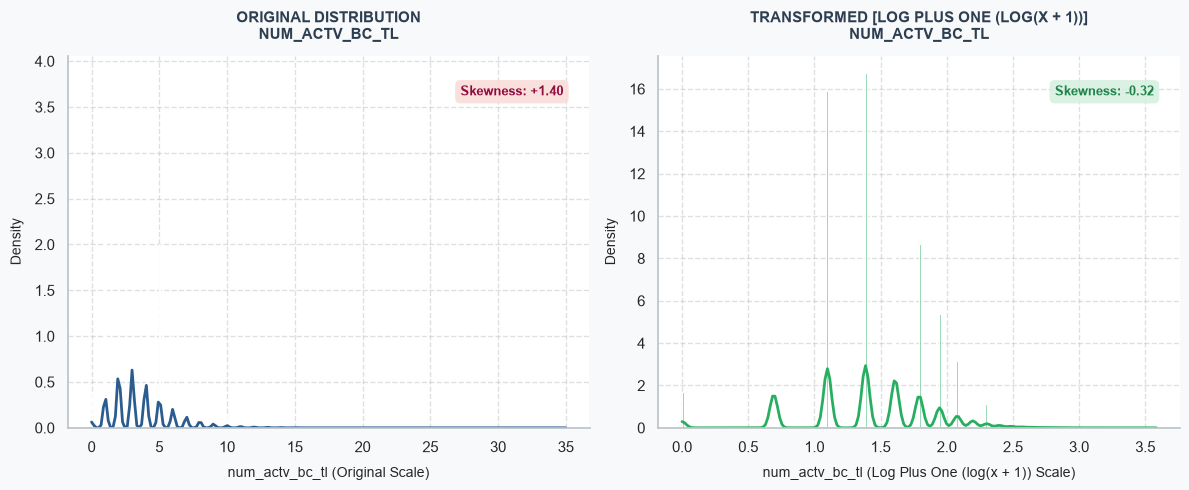

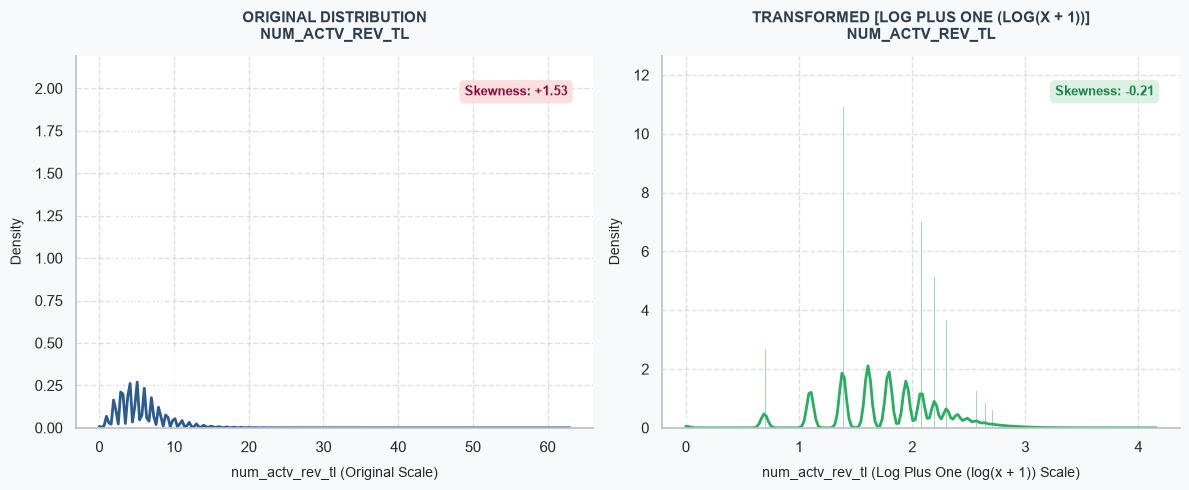

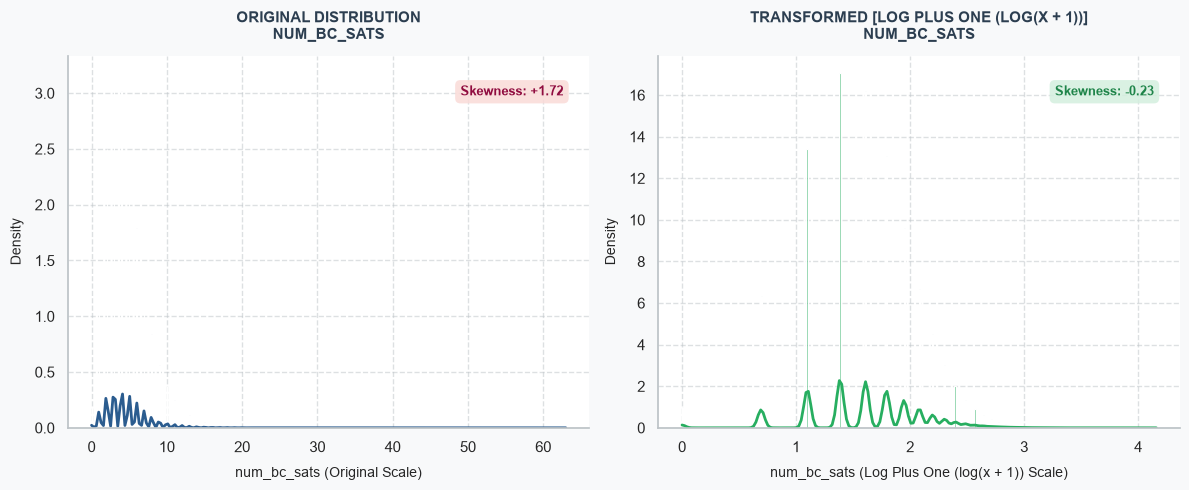

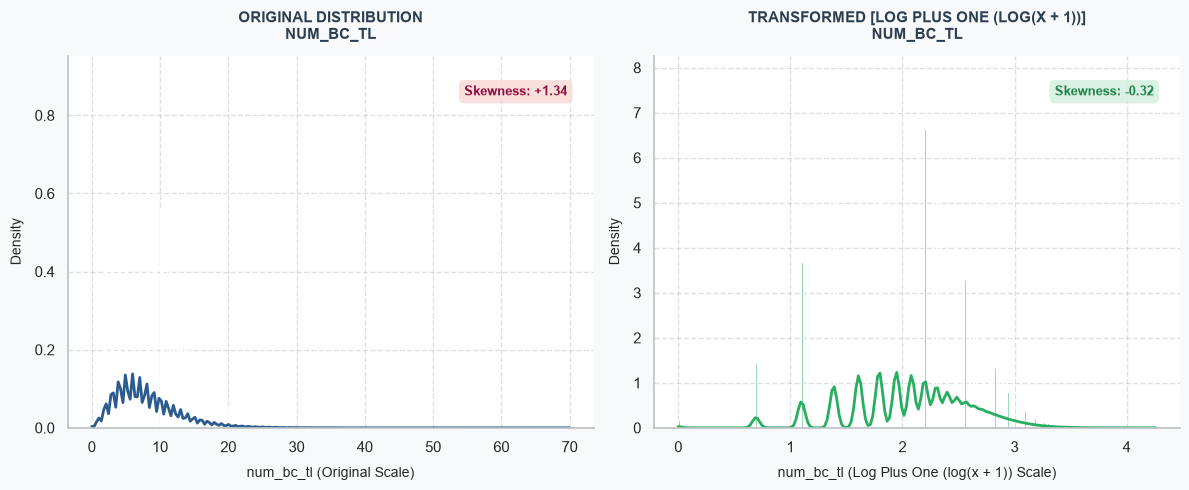

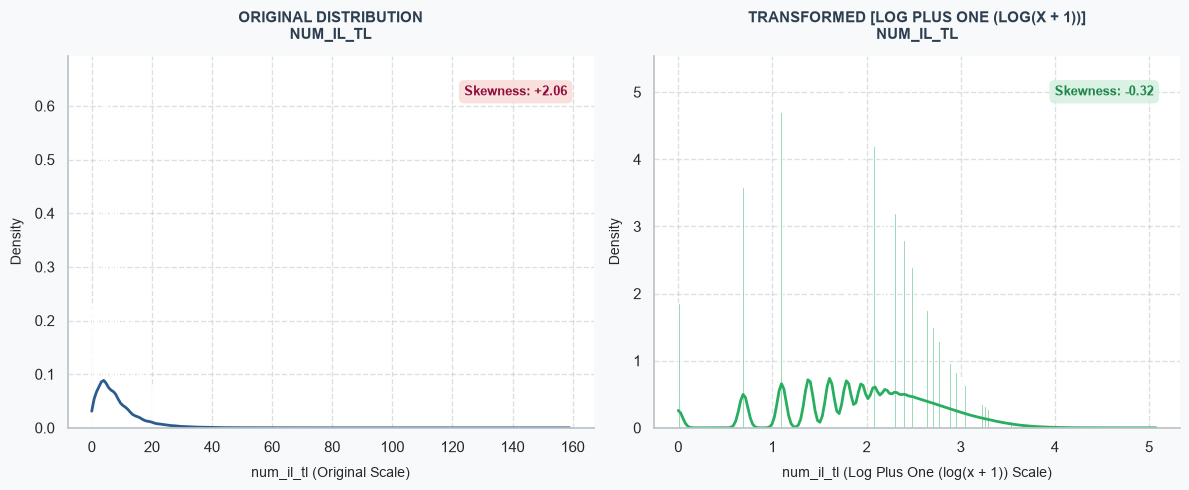

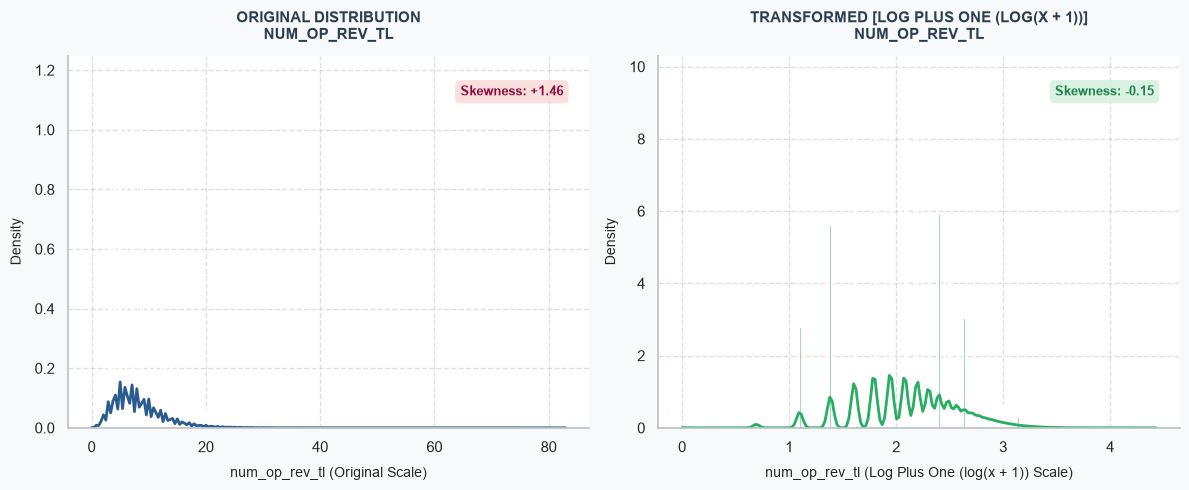

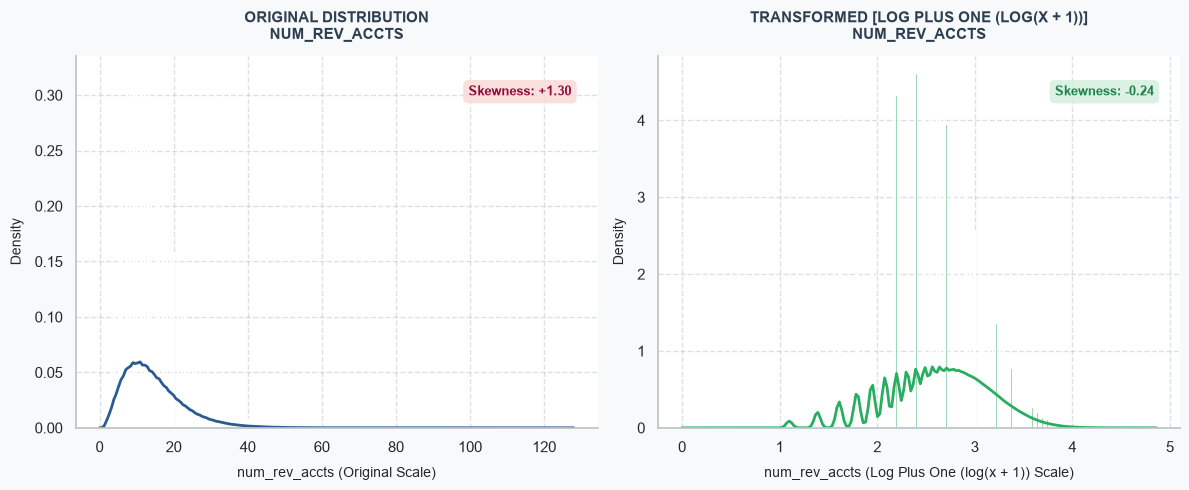

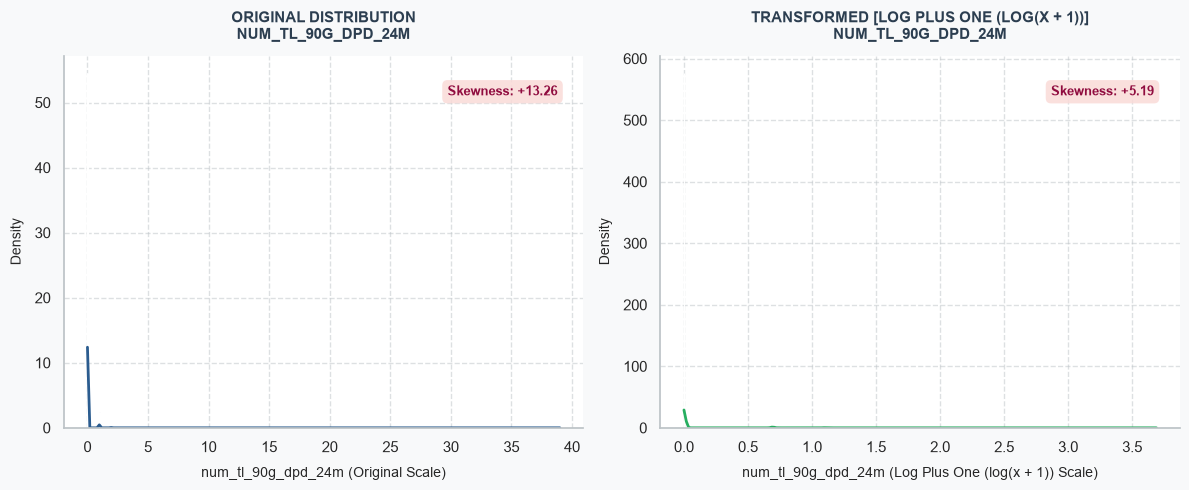

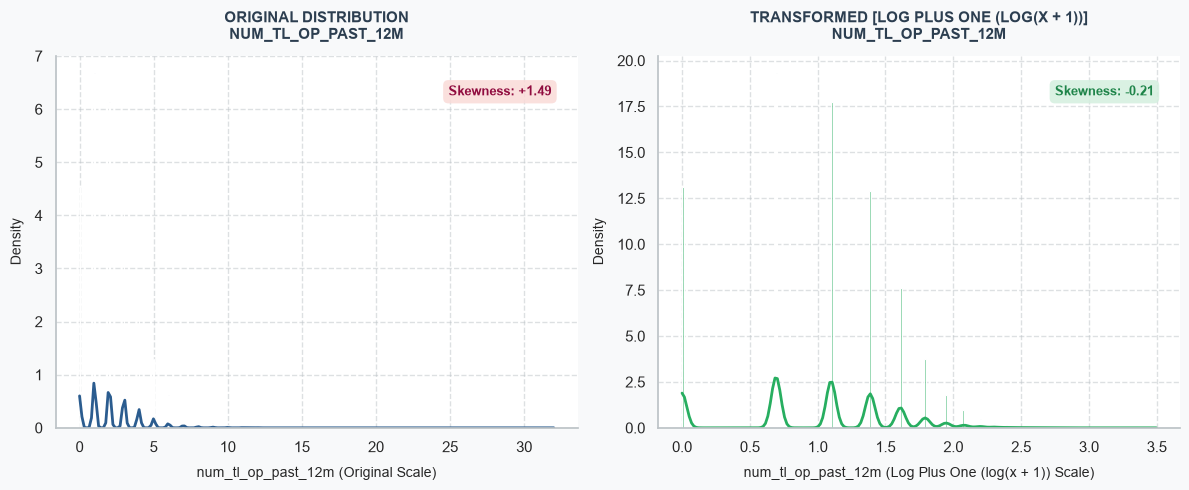

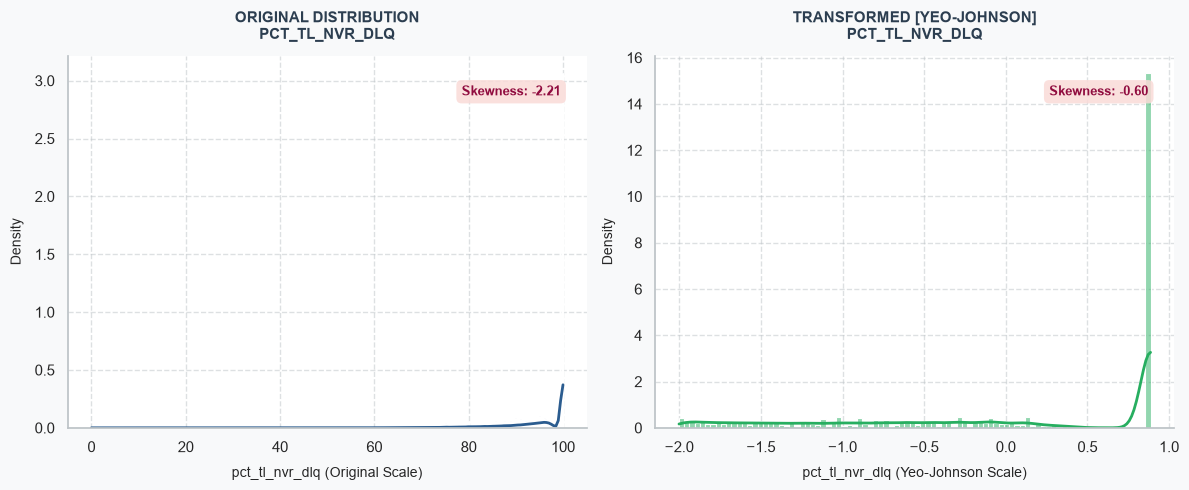

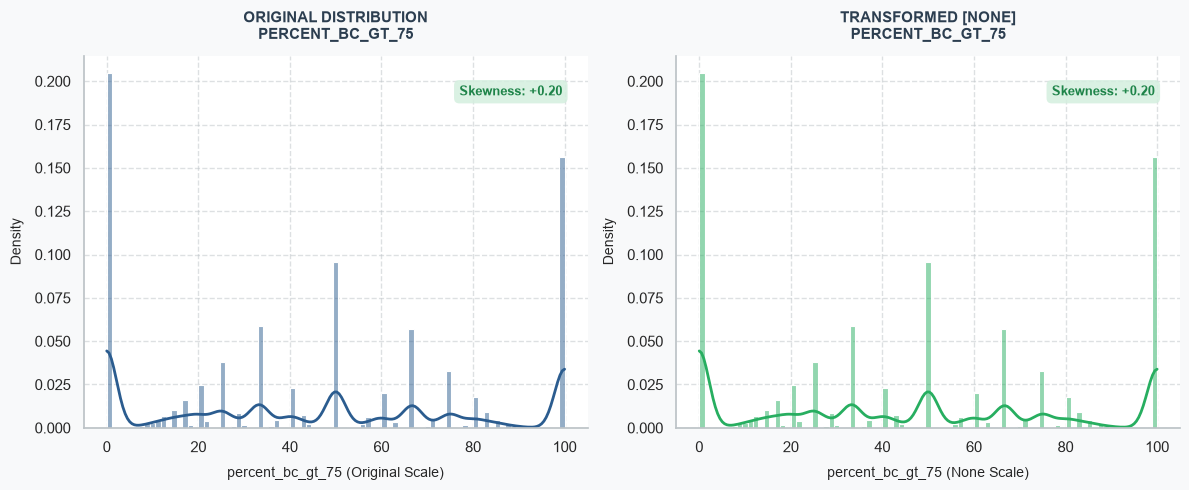

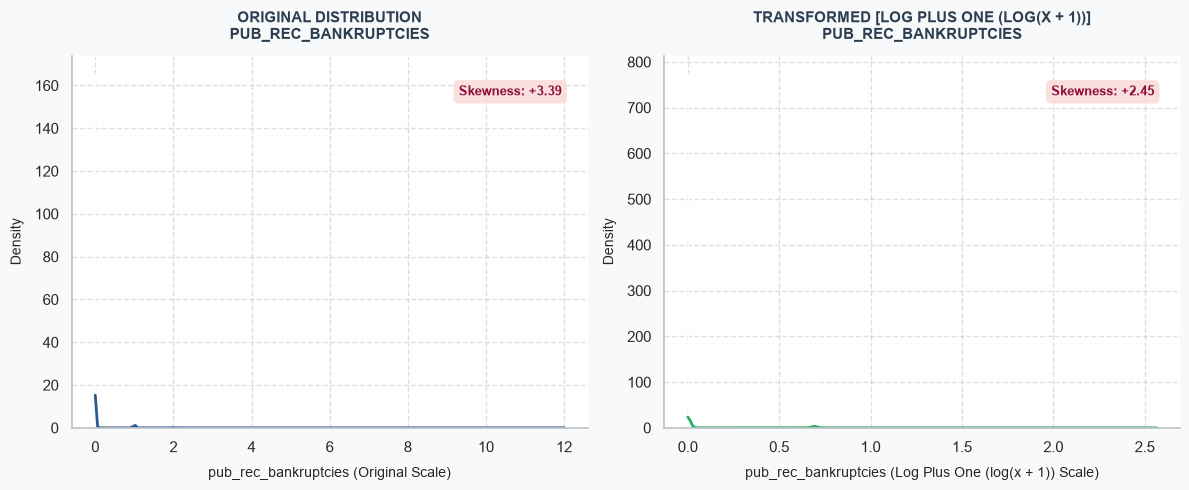

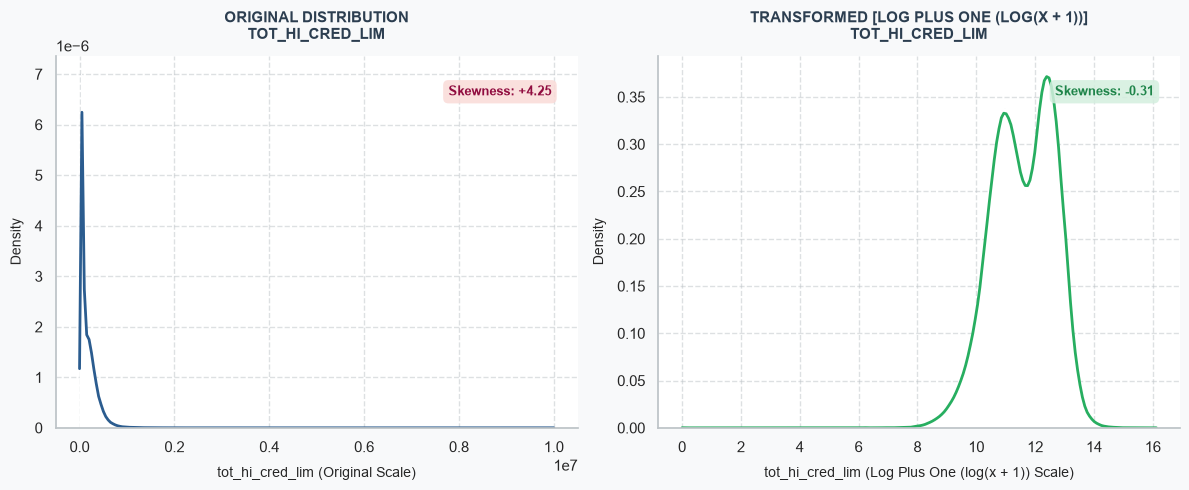

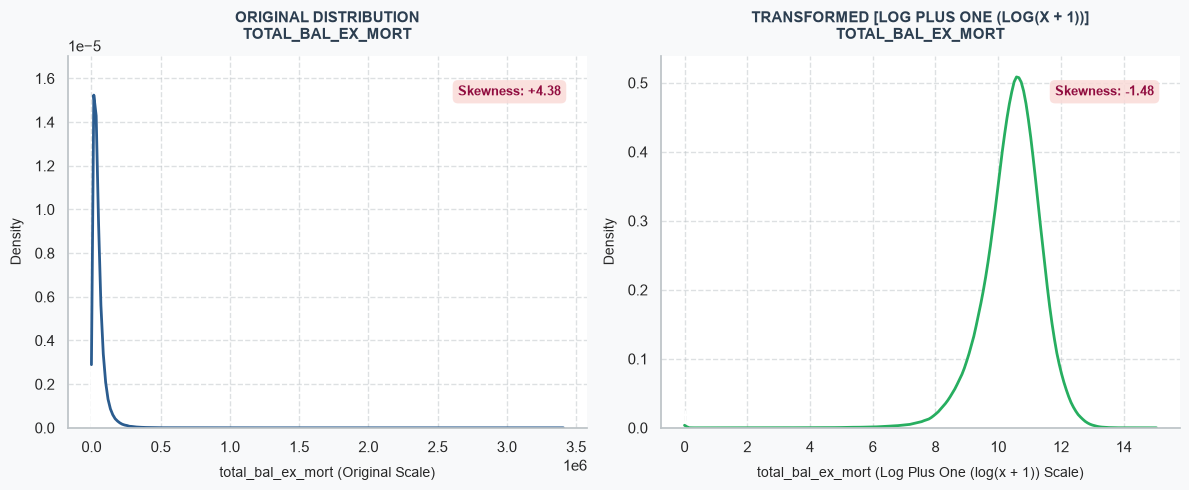

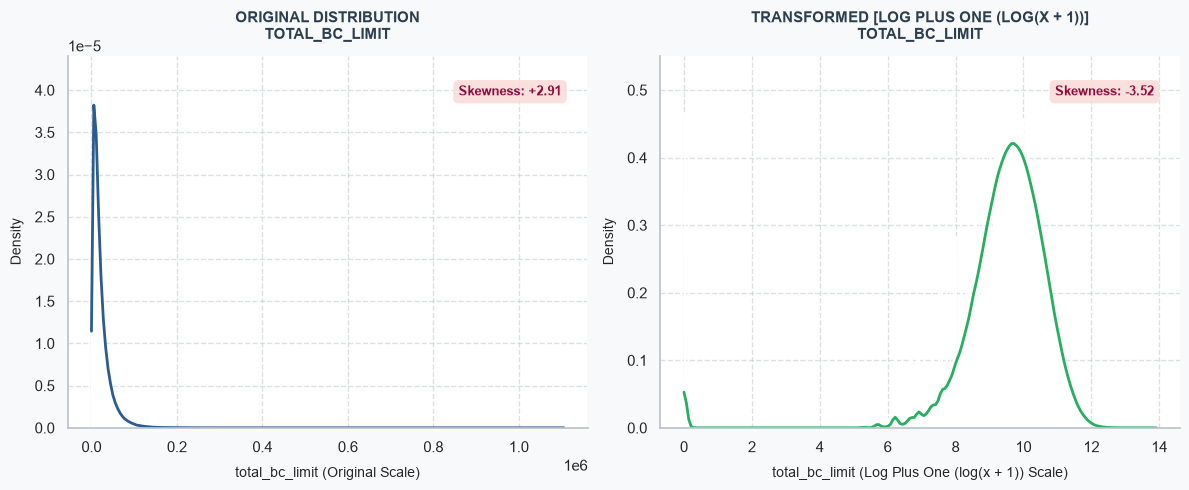

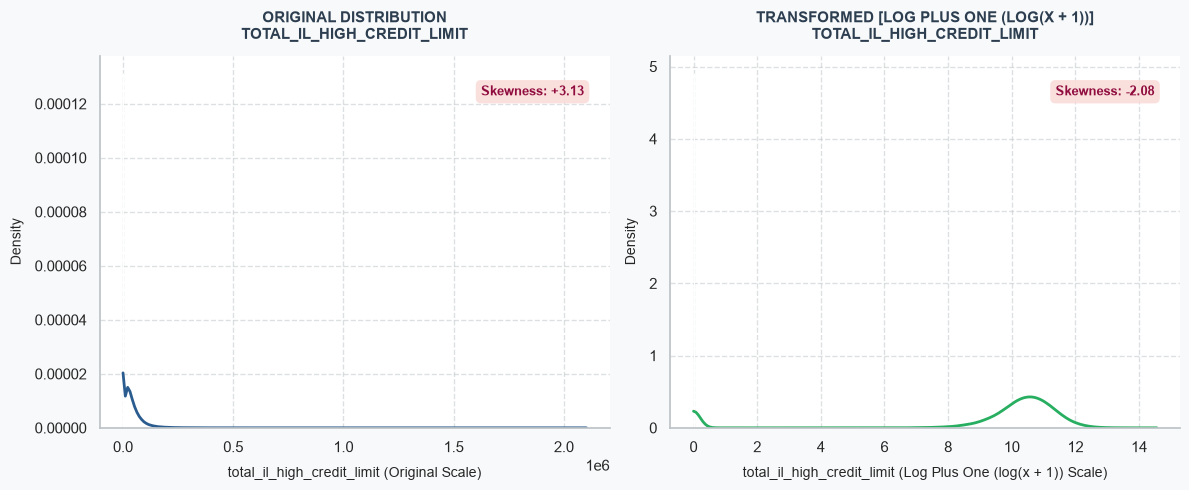

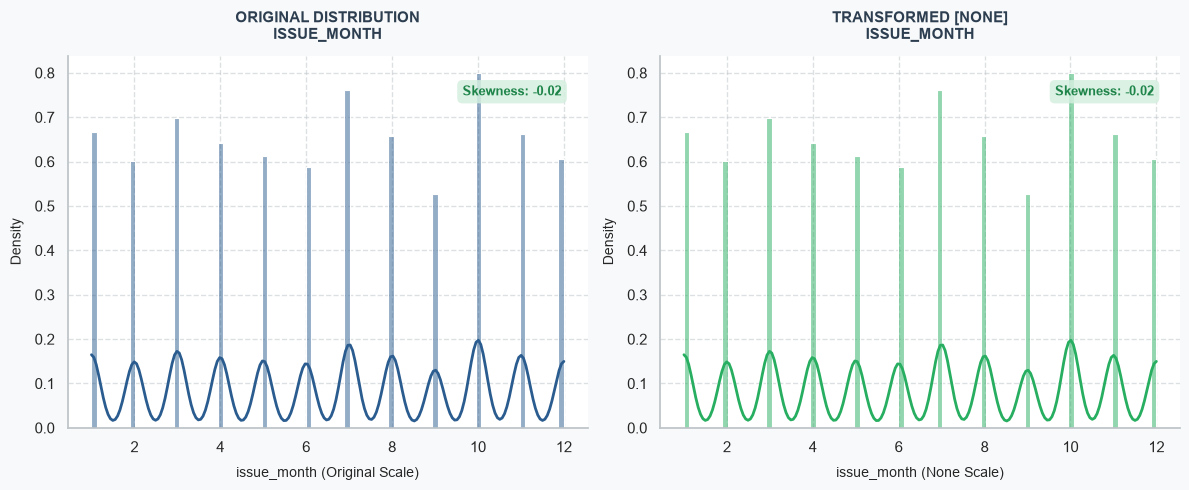

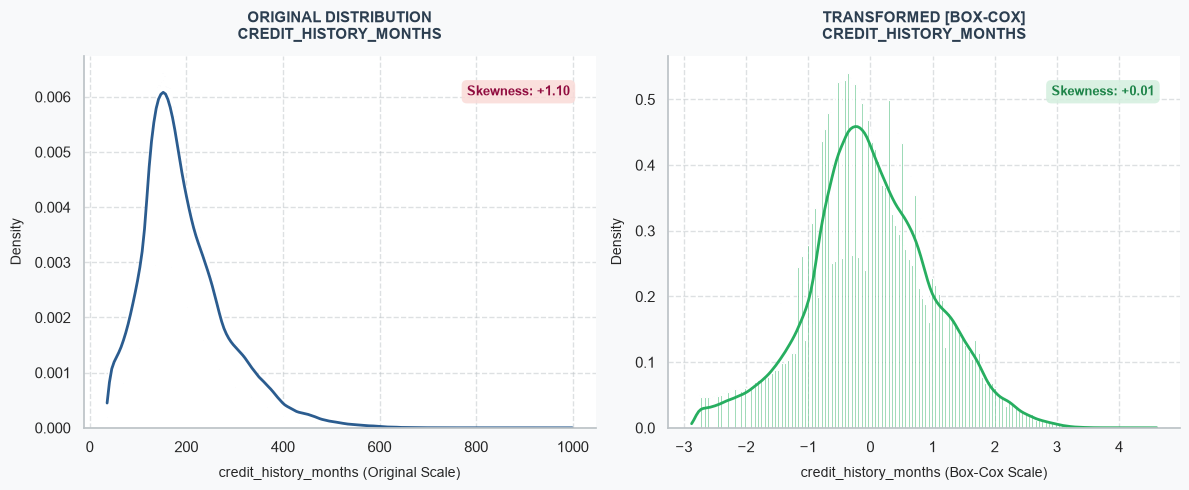

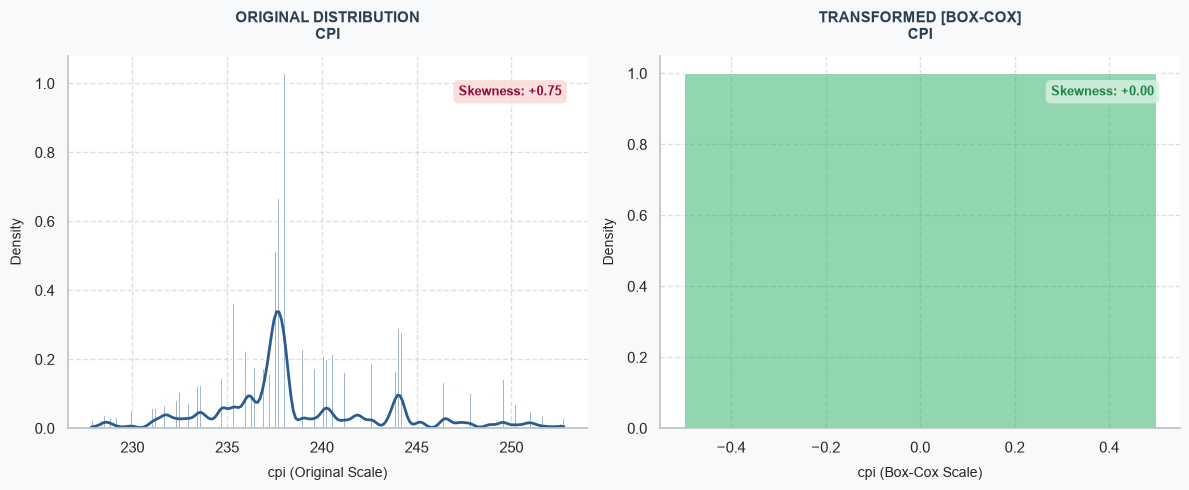

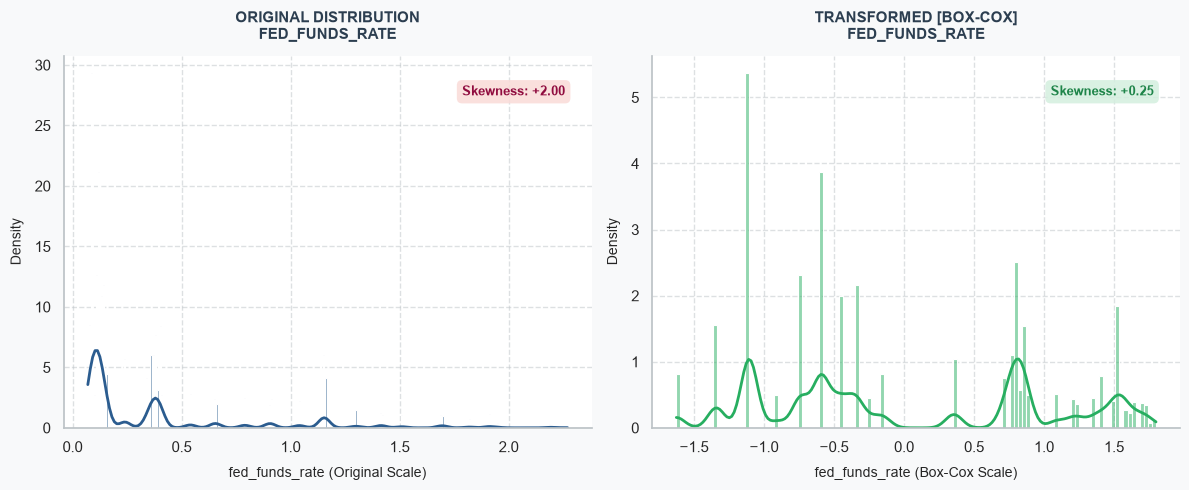

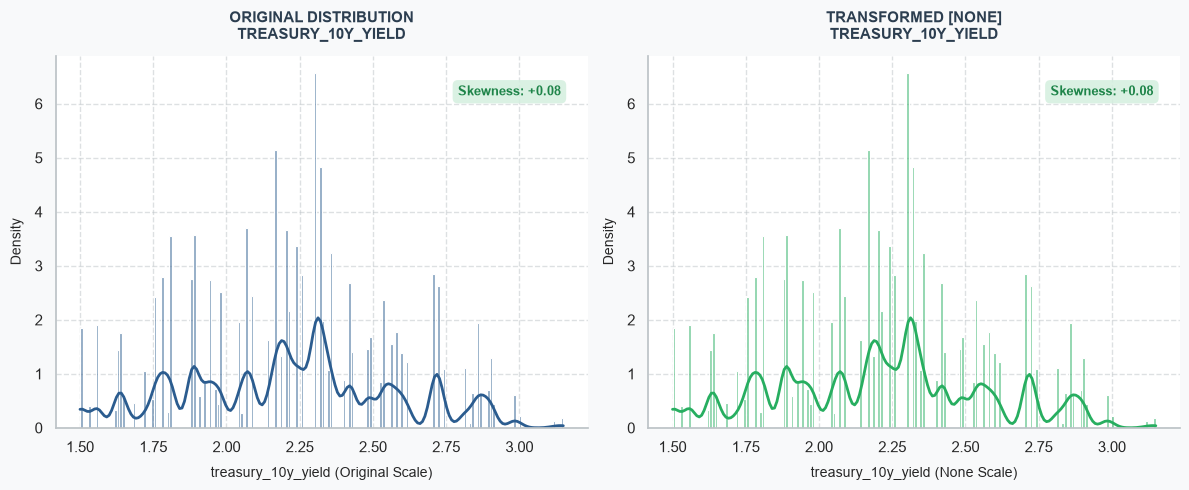

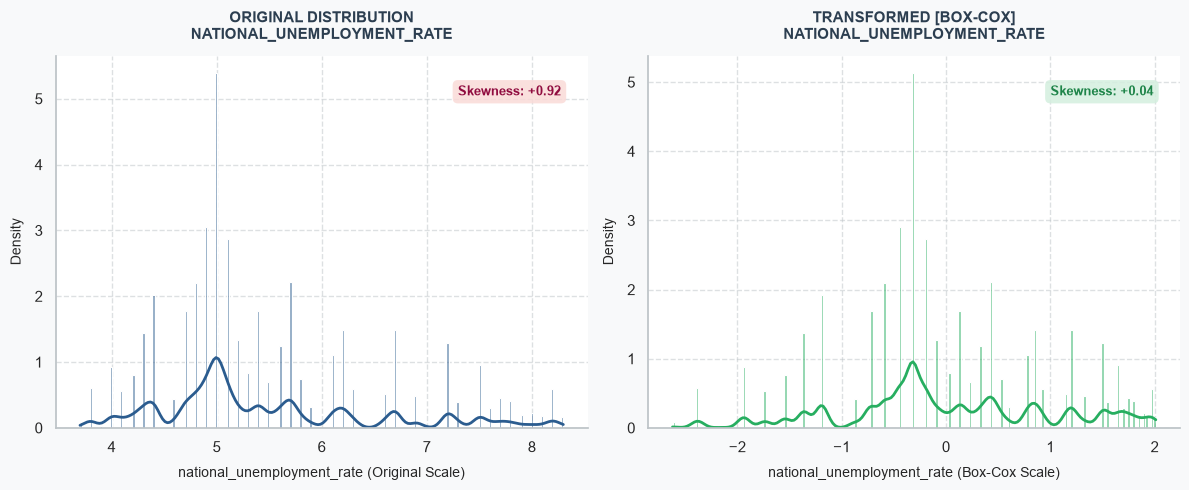

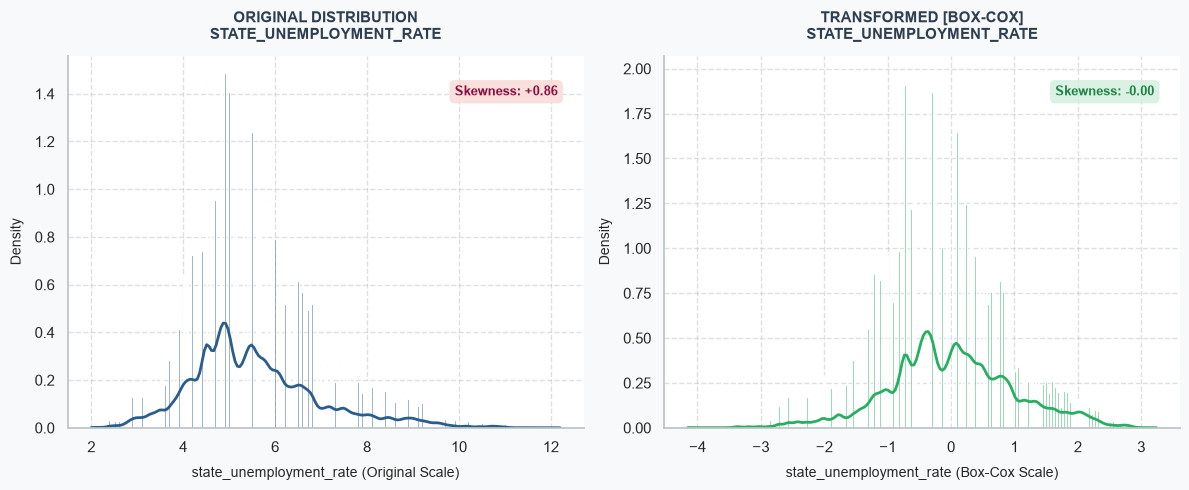

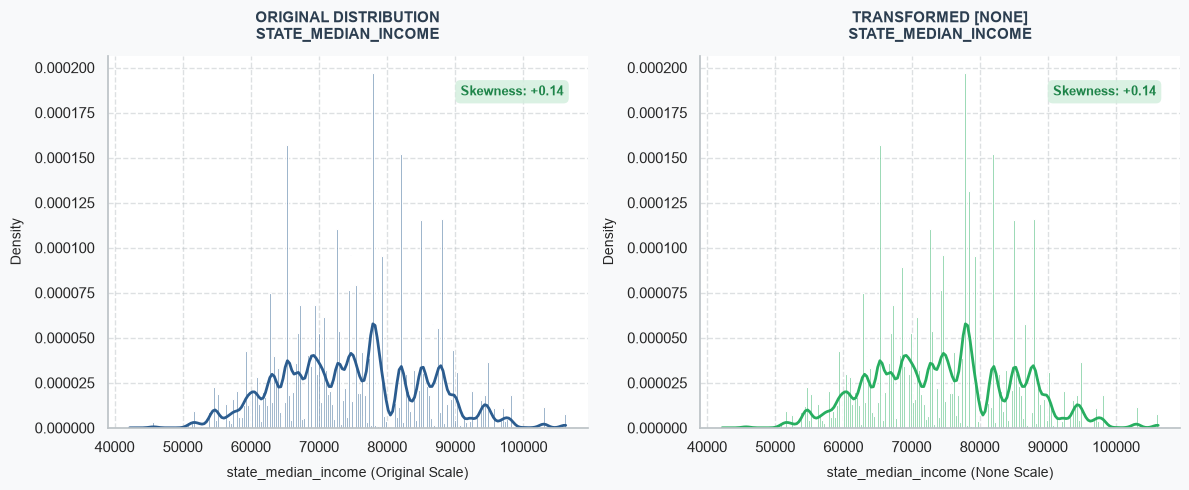

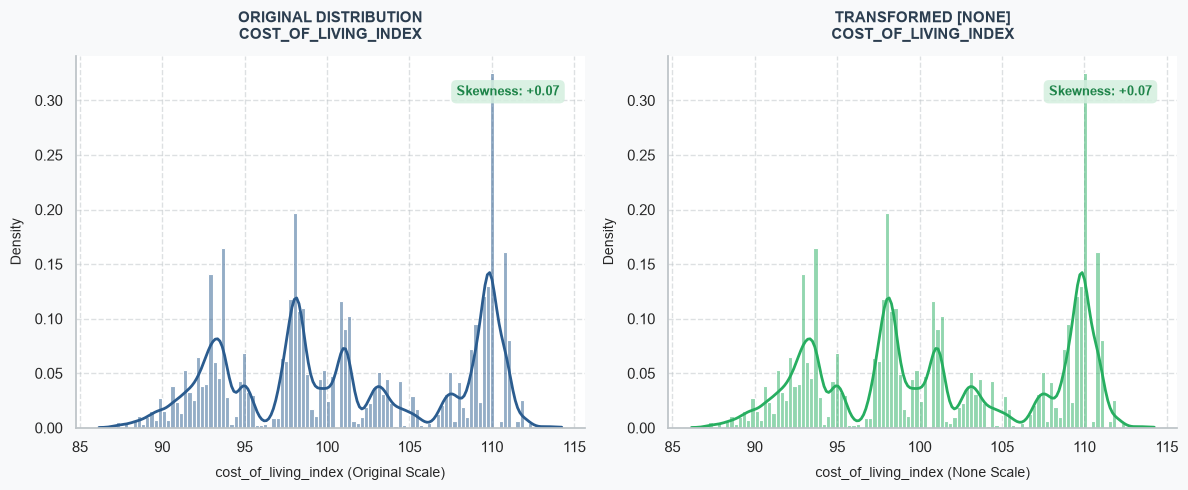

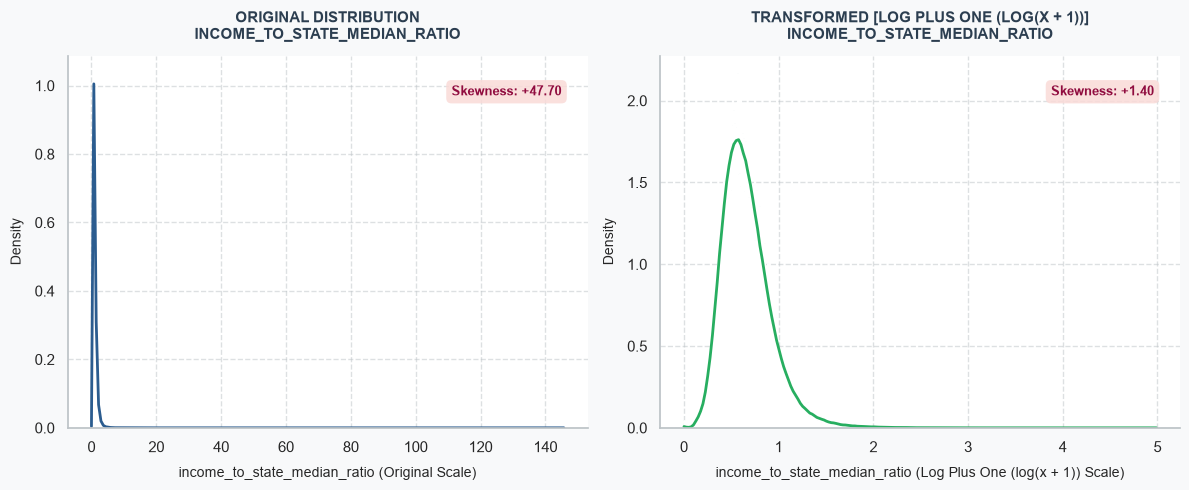

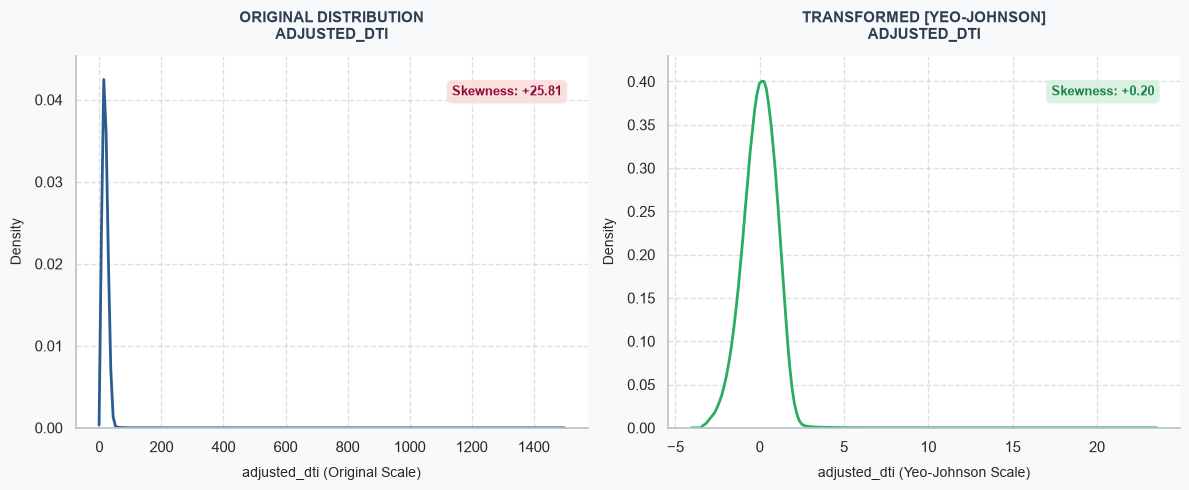

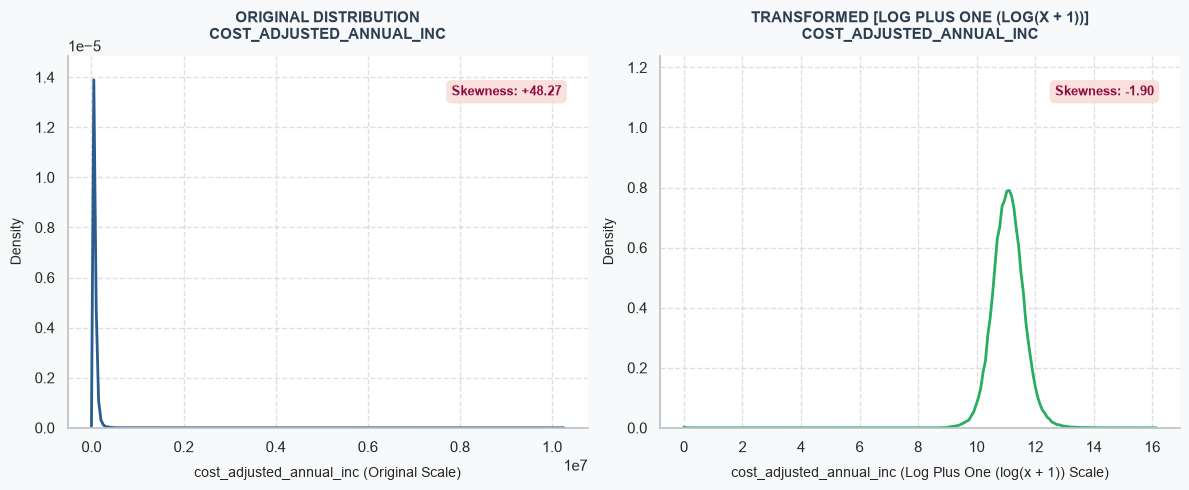

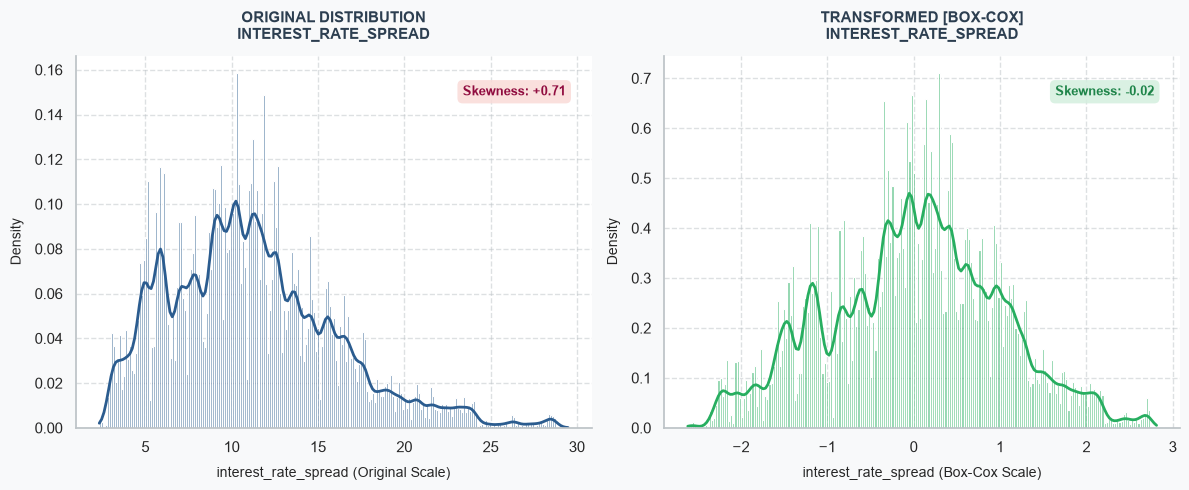

In [76]:
skew_table = skew_calc(df)
plot_transformations(df,skew_table)

In [23]:
from sklearn.preprocessing import PowerTransformer

# 1. Binarize Zero-Inflated Counter Features into Distinct Risk Flags
if 'tot_coll_amt' in df.columns:
    df['has_collections'] = (df['tot_coll_amt'] > 0).astype(int)

if 'num_accts_ever_120_pd' in df.columns:
    df['has_major_derogatory'] = (df['num_accts_ever_120_pd'] > 0).astype(int)

# 2. Log Plus One (log1p) Transformations for Right-Skewed Continuous Features
log_cols = [
    'annual_inc', 
    'cost_adjusted_annual_inc', 
    'revol_bal', 
    'total_rev_hi_lim', 
    'avg_cur_bal'
]

for col in log_cols:
    if col in df.columns:
        # Clip at 0 to avoid invalid log inputs and apply ln(1 + x)
        df[f'{col}_log'] = np.log1p(df[col].clip(lower=0))
        df = df.drop(columns=[col])

# 3. Yeo-Johnson Transformation for DTI (Handles heavy tails and potential 0s)
dti_col = 'adjusted_dti' if 'adjusted_dti' in df.columns else 'dti'

if dti_col in df.columns:
    pt = PowerTransformer(method='yeo-johnson', standardize=True)
    # Fit and transform DTI into a symmetric distribution
    df[f'{dti_col}_yj'] = pt.fit_transform(df[[dti_col]])
    df = df.drop(columns=[dti_col])


In [24]:
df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)
df["term"]

0         36.00
1         60.00
2         36.00
3         36.00
4         36.00
           ... 
1298433   60.00
1298434   60.00
1298435   60.00
1298436   60.00
1298437   60.00
Name: term, Length: 1298438, dtype: float64

In [25]:
df['mths_since_last_delinq'] = df['mths_since_last_delinq'].fillna(999)
df['mths_since_recent_inq']  = df['mths_since_recent_inq'].fillna(999)
df['mo_sin_old_il_acct'] = df['mo_sin_old_il_acct'].fillna(999)

In [20]:
# 1. Compute correlation matrix across all numeric columns
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

# 2. Mask self-correlation diagonal safely without modifying read-only memory
diag_mask = np.eye(len(corr_matrix), dtype=bool)
corr_matrix_no_diag = corr_matrix.mask(diag_mask)

# 3. Iterate through EVERY column in the dataset (sorted alphabetically)
report = []
for col in sorted(df.columns):
    dtype = df[col].dtype
    null_pct = round((df[col].isnull().sum() / len(df)) * 100, 2)

    if pd.api.types.is_numeric_dtype(df[col]):
        var = round(df[col].var(), 4)
        skew = round(df[col].skew(), 4)

        if col in corr_matrix_no_diag.columns:
            corrs = corr_matrix_no_diag[col].dropna()

            if not corrs.empty:
                abs_corrs = corrs.abs()
                top_col = abs_corrs.idxmax()
                top_val = corrs.loc[top_col]
                top_corr_pct = f"{top_val * 100:+.2f}%"
            else:
                top_col, top_corr_pct = "None (Zero Variance)", "N/A"
        else:
            top_col, top_corr_pct = "N/A", "N/A"
    else:
        var, skew, top_col, top_corr_pct = (
            "N/A (Non-numeric)",
            "N/A",
            "N/A (Categorical/Date)",
            "N/A",
        )

    report.append(
        {
            "Column Name": col,
            "Type": str(dtype),
            "Null (%)": null_pct,
            "Variance": var,
            "Skewness": skew,
            "Most Correlated Feature": top_col,
            "Correlation (%)": top_corr_pct,
        }
    )

# 4. Create and display full report
full_summary_df = pd.DataFrame(report).set_index("Column Name")

with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.width", 1000
):
    display(full_summary_df)

,Type,Null (%),Variance,Skewness,Most Correlated Feature,Correlation (%)
Column Name,,,,,,
acc_open_past_24mths,float64,0.58,10.20,1.37,num_tl_op_past_12m,+75.79%
adjusted_dti_yj,float64,0.03,1.00,0.20,total_il_high_credit_limit,+31.41%
application_type,Int64,0.00,0.02,6.73,fed_funds_rate,+25.74%
avg_cur_bal_log,float64,2.14,1.41,-0.38,tot_hi_cred_lim,+73.65%
bc_open_to_buy,float64,1.65,232547741.85,3.84,total_bc_limit,+83.74%
bc_util,float64,1.71,799.88,-0.36,revol_util,+85.46%
cost_adjusted_annual_inc_log,float64,0.00,0.32,-1.90,tot_hi_cred_lim,+51.20%
cost_of_living_index,float64,0.00,46.28,0.07,state_median_income,+64.31%
cpi,float64,0.00,20.70,0.75,fed_funds_rate,+88.76%


In [21]:
import numpy as np
import pandas as pd

# 1. Select numeric features
numeric_df = df.select_dtypes(include=[np.number])

# 2. Compute correlation with target and drop the target itself
target_corrs = numeric_df.corr()["is_default"].drop("is_default")

# 3. Get top 15 features sorted by absolute correlation magnitude
top_15_features = target_corrs.abs().nlargest(71).index
top_15_corrs = target_corrs.loc[top_15_features]

# 4. Format into a clean summary DataFrame
corr_summary = pd.DataFrame(
    {
        "Feature": top_15_corrs.index,
        "Correlation": top_15_corrs.values.round(4),
        "Correlation (%)": (top_15_corrs.values * 100).round(2),
        "Direction": np.where(
            top_15_corrs.values > 0, "Positive (Increases Risk)", "Negative (Lowers Risk)"
        ),
    }
).reset_index(drop=True)

# 5. Display table
with pd.option_context("display.max_rows", None, "display.width", 1000):
    display(corr_summary)

,Feature,Correlation,Correlation (%),Direction
0,sub_grade,0.27,27.10,Positive (Increases Risk)
1,interest_rate_spread,0.27,26.66,Positive (Increases Risk)
2,term,0.19,18.54,Positive (Increases Risk)
3,cpi,0.10,10.16,Positive (Increases Risk)
4,adjusted_dti_yj,0.10,9.99,Positive (Increases Risk)
5,acc_open_past_24mths,0.10,9.87,Positive (Increases Risk)
6,national_unemployment_rate,-0.10,-9.81,Negative (Lowers Risk)
7,fed_funds_rate,0.09,9.10,Positive (Increases Risk)
8,num_tl_op_past_12m,0.08,8.40,Positive (Increases Risk)
9,mort_acc,-0.08,-8.16,Negative (Lowers Risk)


In [26]:
df.to_csv('ready_for_model.csv', index=False)

# Modelling Approach
What are the models you are planning to build for your capstone.
- **You only need to outline your approach here. No need to execute**

In [3]:
df = pd.read_csv('ready_for_model.csv')

In [4]:
# 1. Define Selected Final Feature List
selected_features = [
    # Primary Platform Risk & Loan Terms
    'sub_grade',
    'term',
    'loan_amnt',
    
    # Macroeconomic Risk
    'state_unemployment_rate',
    
    # Capacity & Debt Burden
    'adjusted_dti_yj',
    'cost_adjusted_annual_inc_log',
    'emp_length',
    'home_ownership_RENT',
    'home_ownership_OWN',
    'verification_status_Verified',
    
    # Liquidity & Revolving Credit Exposure
    'bc_util',
    'bc_open_to_buy',
    'total_rev_hi_lim_log',
    'revol_bal_log',
    
    # Credit Inquiries & Credit Velocity
    'acc_open_past_24mths',
    'inq_last_6mths',
    'mths_since_recent_inq',
    
    # Credit History & Wealth Depth
    'credit_history_months',
    'mort_acc',
    'avg_cur_bal_log',
    
    # Delinquencies & Derogatory Signals
    'delinq_2yrs',
    'has_collections',
    'has_major_derogatory'
]

# 2. Extract Feature Matrix (X) and Target (y)
X = df[selected_features].copy()
y = df['is_default'].copy()

--- Pearson Correlation with Default (is_default) ---
sub_grade                       0.27
term                            0.19
adjusted_dti_yj                 0.10
acc_open_past_24mths            0.10
loan_amnt                       0.07
home_ownership_RENT             0.07
verification_status_Verified    0.06
inq_last_6mths                  0.06
bc_util                         0.06
has_collections                 0.02
has_major_derogatory            0.02
delinq_2yrs                     0.02
home_ownership_OWN              0.01
revol_bal_log                  -0.01
credit_history_months          -0.03
emp_length                     -0.04
mths_since_recent_inq          -0.04
total_rev_hi_lim_log           -0.06
cost_adjusted_annual_inc_log   -0.06
state_unemployment_rate        -0.07
avg_cur_bal_log                -0.08
bc_open_to_buy                 -0.08
mort_acc                       -0.08


C:\Users\hu7\AppData\Local\Temp\ipykernel_16692\1913457547.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)


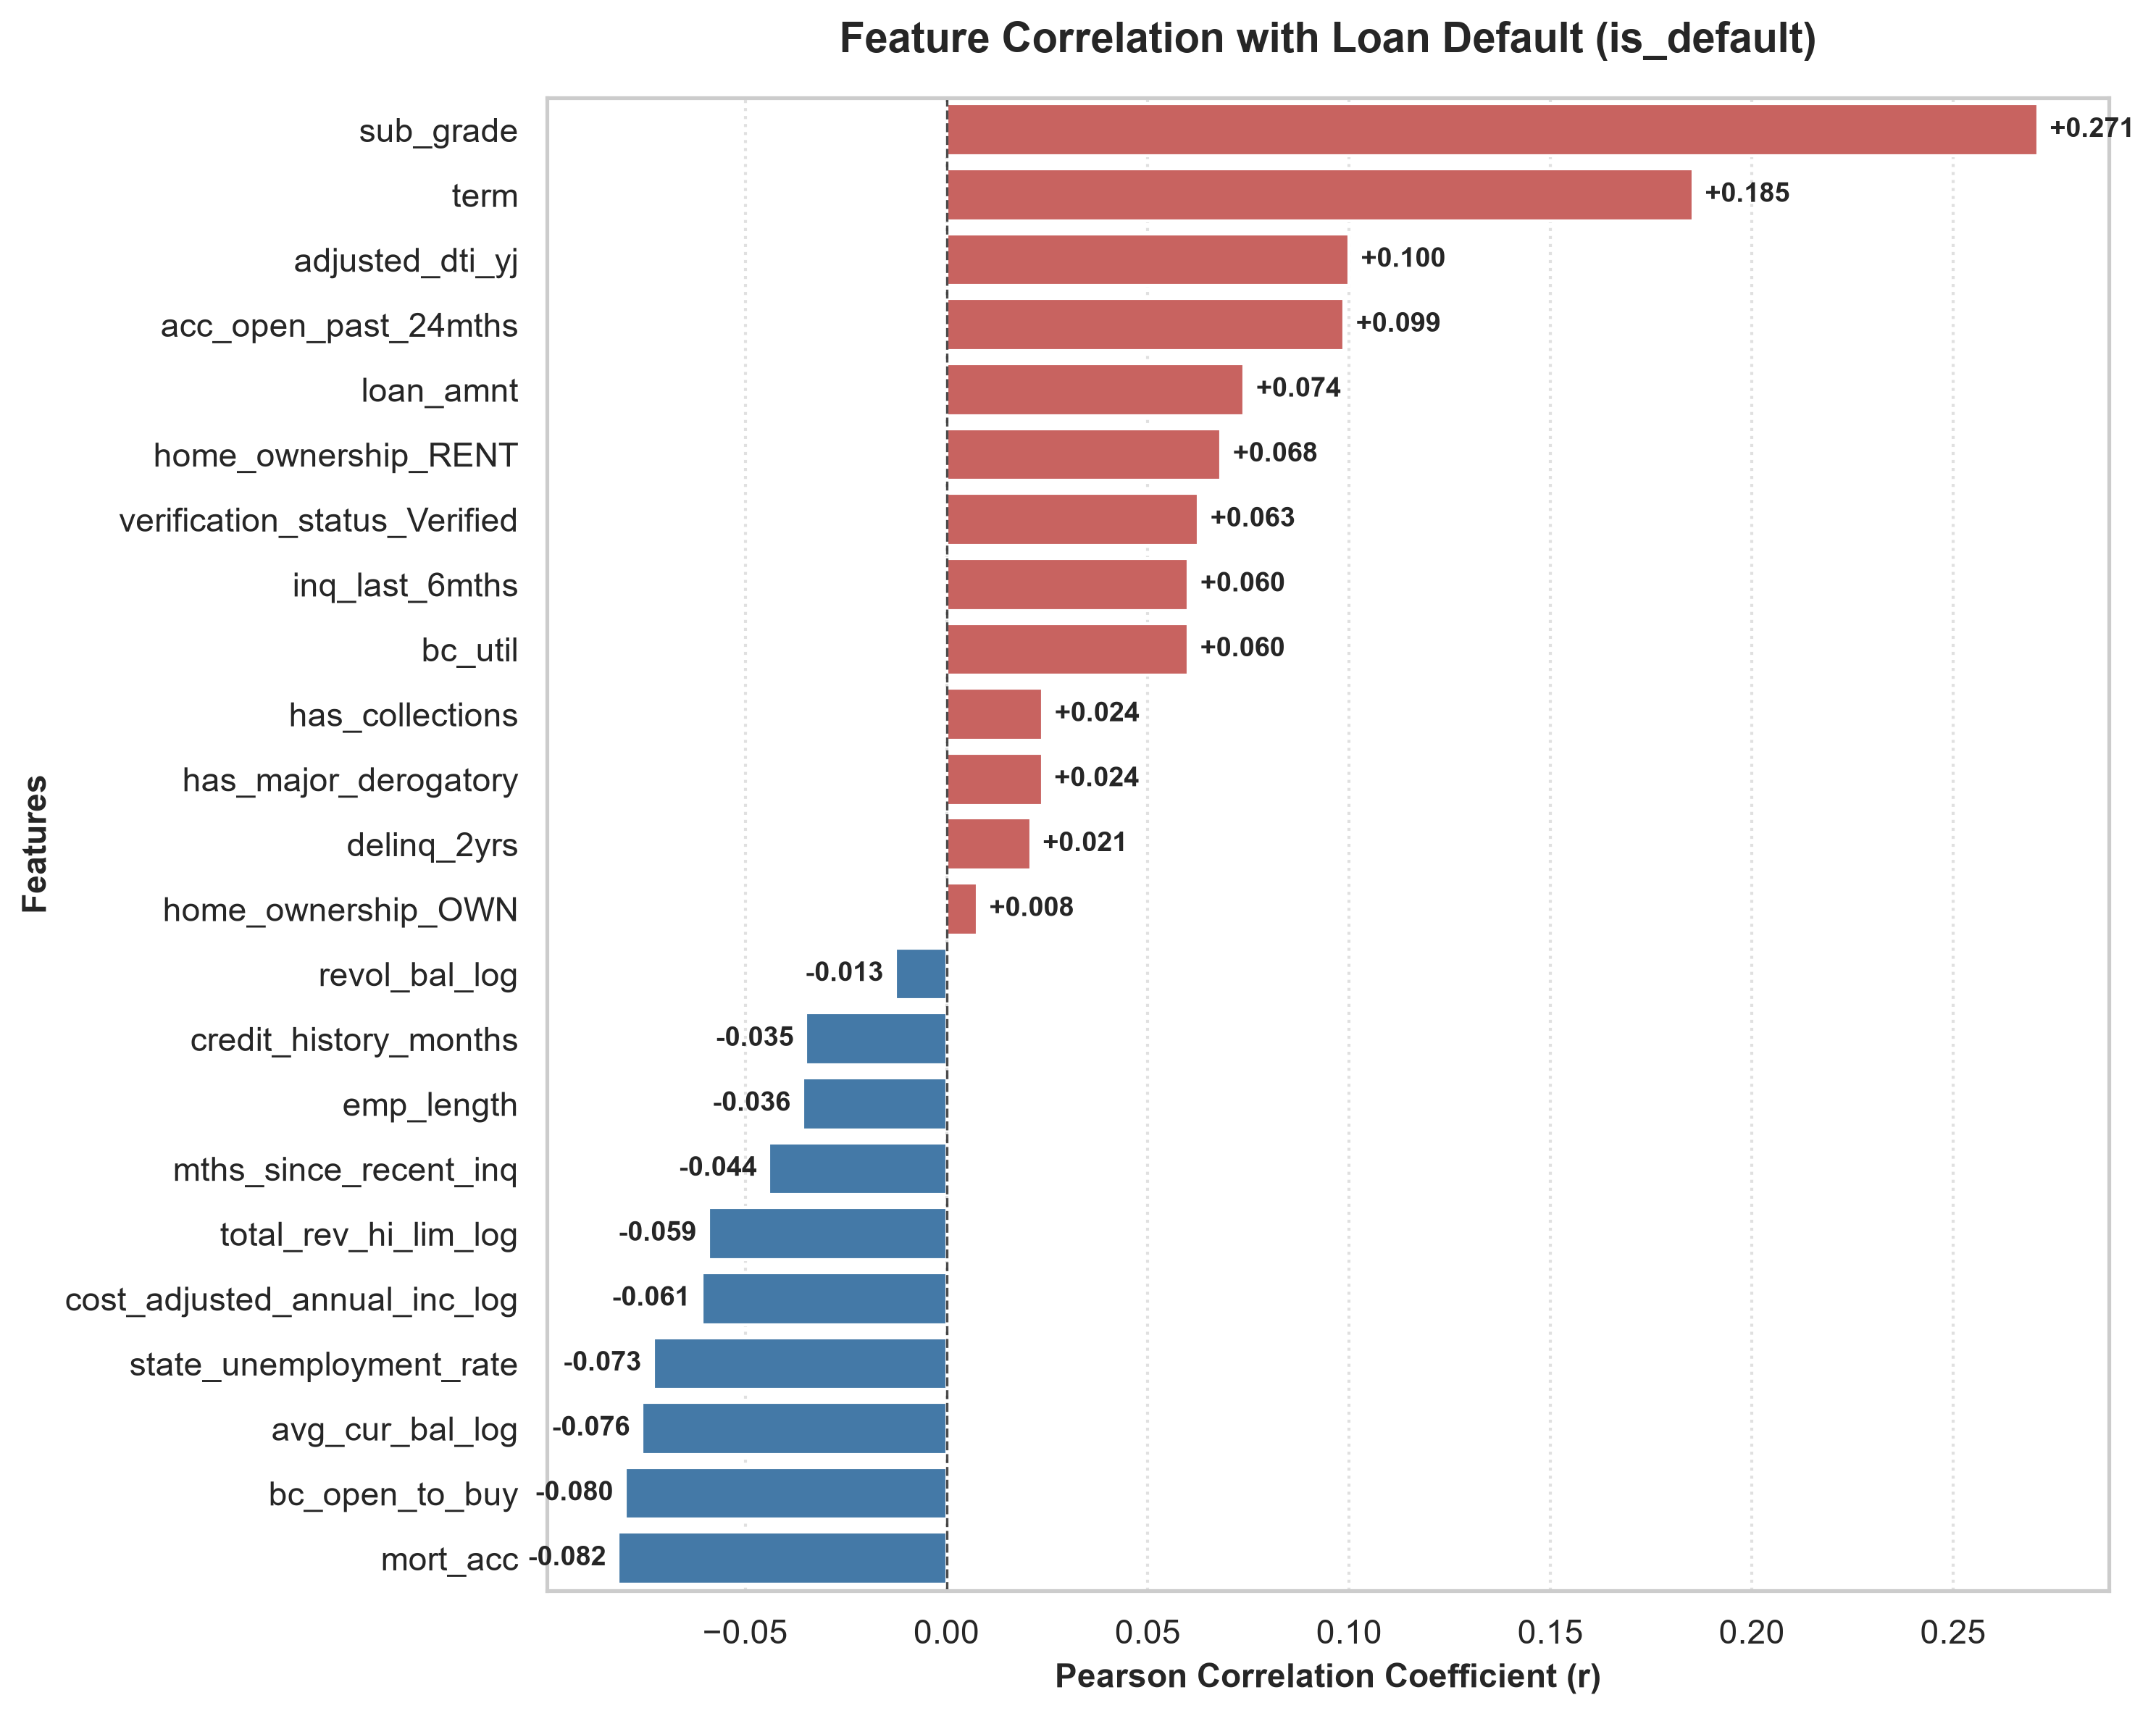

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# -----------------------------------------------------------------------------
# 1. Compute Linear Correlation (Pearson) with Target
# -----------------------------------------------------------------------------
# Combine features and target into a temporary dataframe
df_corr = X.copy()
df_corr['is_default'] = y

# Calculate Pearson correlation of all features against 'is_default' and sort
target_corr = (
    df_corr.corr(numeric_only=True)['is_default']
    .drop('is_default')
    .sort_values(ascending=False)
)

print("--- Pearson Correlation with Default (is_default) ---")
print(target_corr.to_string())

# -----------------------------------------------------------------------------
# 2. Horizontal Bar Chart (Standard for Slide Presentations)
# -----------------------------------------------------------------------------
plt.figure(figsize=(10, 8), dpi=300)

# Generate color map: Red for positive correlation (increases default risk),
# Blue for negative correlation (decreases default risk / protective signal)
colors = ['#d9534f' if val > 0 else '#337ab7' for val in target_corr.values]

sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)

# Chart styling
plt.title(
    'Feature Correlation with Loan Default (is_default)',
    fontsize=14,
    fontweight='bold',
    pad=15,
)
plt.xlabel('Pearson Correlation Coefficient (r)', fontsize=11, fontweight='bold')
plt.ylabel('Features', fontsize=11, fontweight='bold')
plt.axvline(
    0, color='black', linestyle='--', linewidth=0.8, alpha=0.7
)  # Center baseline
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Annotate correlation values at the tip of each bar
for idx, val in enumerate(target_corr.values):
  offset = 0.003 if val >= 0 else -0.003
  ha_align = 'left' if val >= 0 else 'right'
  plt.text(
      val + offset,
      idx,
      f'{val:+.3f}',
      va='center',
      ha=ha_align,
      fontsize=9,
      fontweight='bold',
  )

plt.tight_layout()
plt.show()

In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Selected Feature Count: {X.shape[1]}")
print(f"X_train Shape: {X_train.shape} | X_test Shape: {X_test.shape}")
print(f"y_train Shape: {y_train.shape} | y_test Shape: {y_test.shape}")

Selected Feature Count: 23
X_train Shape: (1038750, 23) | X_test Shape: (259688, 23)
y_train Shape: (1038750,) | y_test Shape: (259688,)


# Model 1 - LightGBM

In [61]:
# =============================================================================
# LIGHTGBM 10-FOLD PURIFIED ENSEMBLE PIPELINE
# -----------------------------------------------------------------------------
# Pipeline Breakdown:
# 1. Feature Engineering: Bayesian Smoothed Target Encoding & Cohort Z-Scores
# 2. Categorical Preprocessing: Native Category Casting for LightGBM
# 3. Model Architecture: Deep, Regularized Leaf-Wise Gradient Boosted Trees
# 4. Cross-Validation: 10-Fold Stratified CV with Top-Fold Pruning & Ensembling
# 5. Business Decision Engine: Multi-Threshold Precision-Recall Calibration
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Environment Setup & Library Imports
# -----------------------------------------------------------------------------
import warnings
warnings.filterwarnings('ignore')  # Suppress non-critical library and runtime warnings

import lightgbm as lgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# -----------------------------------------------------------------------------
# 1. Feature Engineering & Signal Construction
# -----------------------------------------------------------------------------
print("🛠️ Step 1/3: Preparing Verified Signal Features...")

# Create isolated working copies of the training and test splits to prevent data contamination
X_tr = X_train.copy()
X_te = X_test.copy()

# Compute the baseline population default rate (used as prior belief in Bayesian smoothing)
global_mean = y_train.mean()
smoothing = 12  # Smoothing weight (m-estimate): prevents small-sample subgrades from overfitting

# --- 1.1 Bayesian Smoothed Target Encoding for Subgrades ---
# Formula: Smoothed_Rate = (n_count * group_mean + m * global_mean) / (n_count + m)
# High-frequency categories rely on empirical mean; rare categories shrink to global mean
if 'sub_grade' in X_tr.columns:
    stats = y_train.groupby(X_tr['sub_grade']).agg(['count', 'mean'])
    smoothed_te = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    
    # Map smoothed probabilities back to train/test datasets and fill any unseen categories with global prior
    X_tr['sub_grade_te'] = X_tr['sub_grade'].map(smoothed_te).fillna(global_mean).astype('float32')
    X_te['sub_grade_te'] = X_te['sub_grade'].map(smoothed_te).fillna(global_mean).astype('float32')

# --- 1.2 Subgrade Cohort Relative Risk Signals (Deviations & Z-Scores) ---
# Key Concept: A $35k loan carries different risk for an 'A1' borrower vs an 'E5' borrower.
# These features tell the model how anomalous an applicant is relative to their assigned credit tier.
core_num_cols = [c for c in ['avg_cur_bal_log', 'loan_amnt', 'bc_open_to_buy', 'bc_util'] if c in X_tr.columns]

if 'sub_grade' in X_tr.columns:
    for num_col in core_num_cols:
        # Calculate within-subgrade statistical baseline
        grp_mean = X_tr.groupby('sub_grade')[num_col].mean()
        grp_std = X_tr.groupby('sub_grade')[num_col].std()
        
        # Absolute Difference: (Value - Cohort Average)
        X_tr[f'{num_col}_diff_grade'] = (X_tr[num_col] - X_tr['sub_grade'].map(grp_mean)).astype('float32')
        X_te[f'{num_col}_diff_grade'] = (X_te[num_col] - X_te['sub_grade'].map(grp_mean)).astype('float32')
        
        # Standardized Z-Score: (Value - Cohort Average) / Cohort StdDev (1e-4 prevents division by zero)
        X_tr[f'{num_col}_z_grade'] = ((X_tr[num_col] - X_tr['sub_grade'].map(grp_mean)) / (X_tr['sub_grade'].map(grp_std) + 1e-4)).astype('float32')
        X_te[f'{num_col}_z_grade'] = ((X_te[num_col] - X_te['sub_grade'].map(grp_mean)) / (X_te['sub_grade'].map(grp_std) + 1e-4)).astype('float32')

# --- 1.3 Categorical Type Registration ---
# LightGBM uses Fisher's exact test partitioning over native pandas 'category' dtypes
cat_cols = list(X_tr.select_dtypes(include=['object', 'category']).columns)
for col in cat_cols:
    X_tr[col] = X_tr[col].astype('category')
    X_te[col] = X_te[col].astype('category')

# -----------------------------------------------------------------------------
# 2. Production Hyperparameter Configuration
# -----------------------------------------------------------------------------
# Carefully tuned to maximize ROC-AUC while mitigating tabular overfitting across 1M+ rows
optimal_params = {
    'objective': 'binary',        # Standard binary cross-entropy loss function
    'boosting_type': 'gbdt',      # Traditional Gradient Boosted Decision Trees
    'max_bin': 512,               # High histogram resolution for finer split thresholds
    'num_leaves': 192,            # Leaf-wise tree capacity (enables deep, non-linear interaction modeling)
    'max_depth': 8,               # Structural depth cap to prevent runaway leaf growth
    'learning_rate': 0.005,       # Slow, conservative gradient shrinkage for optimal convergence
    'n_estimators': 8000,         # High tree budget governed by early stopping
    'subsample': 0.85,            # Row bagging ratio per iteration to reduce variance
    'subsample_freq': 1,          # Apply row subsampling at every single tree build
    'colsample_bytree': 0.65,     # Column (feature) bagging: trees select from 65% of features per split
    'min_child_samples': 40,      # Minimum samples required in a terminal leaf to suppress noise memorization
    'path_smooth': 1.5,           # Regularizes leaf predictions using parent node evidence
    'min_split_gain': 0.0001,     # Minimum loss reduction required to justify adding a tree partition
    'reg_alpha': 0.1,             # L1 (Lasso) regularization to encourage feature sparsity
    'reg_lambda': 1.2,            # L2 (Ridge) regularization to shrink leaf weight magnitudes
    'random_state': 77,           # Seed for deterministic reproducibility
    'n_jobs': -1                  # Fully parallelized CPU execution across all cores
}

# -----------------------------------------------------------------------------
# 3. 10-Fold Stratified Cross-Validation & Ensemble Training
# -----------------------------------------------------------------------------
print("\n🚀 Step 2/3: Training Quality-Weighted 10-Fold Ensemble...")

n_splits = 10
# StratifiedKFold maintains the exact 78:22 paid-to-default ratio across all 10 folds
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=77)

# Storage for out-of-sample test predictions across all 10 trained models
test_preds_matrix = np.zeros((len(X_te), n_splits))
fold_aucs = []

for fold, (trn_idx, val_idx) in enumerate(skf.split(X_tr, y_train)):
    print(f"\n--- Fold {fold + 1}/{n_splits} ---")
    
    # Extract training and validation splits for the current fold
    X_train_f, y_train_f = X_tr.iloc[trn_idx], y_train.iloc[trn_idx]
    X_val_f, y_val_f = X_tr.iloc[val_idx], y_train.iloc[val_idx]
    
    # Initialize and fit the fold model
    model = lgb.LGBMClassifier(**optimal_params)
    model.fit(
        X_train_f, y_train_f,
        eval_set=[(X_val_f, y_val_f)],
        eval_metric='auc',
        callbacks=[
            lgb.early_stopping(stopping_rounds=300, verbose=False),  # Halt if validation AUC does not improve for 300 rounds
            lgb.log_evaluation(period=1000)                         # Print training status every 1,000 trees
        ]
    )
    
    # Evaluate validation ROC-AUC on holdout fold
    val_preds = model.predict_proba(X_val_f)[:, 1]
    fold_auc = roc_auc_score(y_val_f, val_preds)
    fold_aucs.append(fold_auc)
    print(f"Fold {fold + 1} Best AUC: {fold_auc:.5f}")
    
    # Generate continuous default probabilities on unseen test data
    test_preds_matrix[:, fold] = model.predict_proba(X_te)[:, 1]

# --- 3.1 Fold Purification (Top-K Model Selection) ---
# Rank folds by performance, drop the bottom 3 underperforming models, and ensemble the top 7
top_folds = np.argsort(fold_aucs)[3:]
print(f"\nEnsembling Top Folds Only: {top_folds + 1}")

# Average the probability outputs of the selected top 7 folds
final_test_probs = np.mean(test_preds_matrix[:, top_folds], axis=1)

print("\n" + "="*55)
print(f"🔥 FINAL PURIFIED ENSEMBLE TEST ROC-AUC: {roc_auc_score(y_test, final_test_probs):.5f}")
print("="*55)

# -----------------------------------------------------------------------------
# 4. Multi-Threshold Decision Scanning & Business Strategy Calibration
# -----------------------------------------------------------------------------
print("\n📊 Step 3/3: Evaluating Precision vs. Recall Trade-Offs...")

# Scan decision thresholds to illustrate how cutoff selection dictates underwriting risk
eval_thresholds = [0.18, 0.20, 0.22, 0.24, 0.26, 0.28, 0.30, 0.35, 0.40, 0.50]
matrix_rows = []

for t in eval_thresholds:
    preds = (final_test_probs >= t).astype(int)
    matrix_rows.append({
        'Threshold': t,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision (Class 1)': round(precision_score(y_test, preds, pos_label=1), 4),
        'Recall (Class 1)': round(recall_score(y_test, preds, pos_label=1), 4),
        'F1 (Class 1)': round(f1_score(y_test, preds, pos_label=1), 4),
        'Macro F1': round(f1_score(y_test, preds, average='macro'), 4)
    })

# Print side-by-side threshold performance matrix
print(pd.DataFrame(matrix_rows).to_string(index=False))

# --- 4.1 Strategy A: Capital Preservation & Risk Mitigation (Cutoff = 0.22) ---
# Objective: Maximize default detection in high-risk / recessionary macroeconomic environments
print(f"\n📋 Strategy A: High True-Positive Capture (Cutoff = 0.22)")
preds_22 = (final_test_probs >= 0.22).astype(int)
print(f"Catches ~72% of all defaults")
print(f"Accuracy: {accuracy_score(y_test, preds_22):.4f}\n")
print(classification_report(y_test, preds_22, digits=4))

# --- 4.2 Strategy B: Balanced Portfolio Growth & Yield (Cutoff = 0.28) ---
# Objective: Maximize loan origination and interest income while maintaining strong credit filtering
print(f"\n📋 Strategy B: Balanced Operating Point (Cutoff = 0.28)")
preds_28 = (final_test_probs >= 0.28).astype(int)
print(f"Catches ~58% of defaults with 40% precision")
print(f"Accuracy: {accuracy_score(y_test, preds_28):.4f}\n")
print(classification_report(y_test, preds_28, digits=4))

# -----------------------------------------------------------------------------
# 5. Production Hyperparameter Summary
# -----------------------------------------------------------------------------
print("\n" + "="*55)
print("⚙️ OPTIMAL PRODUCTION HYPERPARAMETERS")
print("="*55)
for k, v in optimal_params.items():
    print(f"'{k}': {v},")
print("="*55)

🛠️ Step 1/3: Preparing Verified Signal Features...

🚀 Step 2/3: Training Quality-Weighted 10-Fold Ensemble...

--- Fold 1/10 ---
[1000]	valid_0's auc: 0.728234	valid_0's binary_logloss: 0.4727
[2000]	valid_0's auc: 0.730226	valid_0's binary_logloss: 0.471444
[3000]	valid_0's auc: 0.730908	valid_0's binary_logloss: 0.471072
[4000]	valid_0's auc: 0.731204	valid_0's binary_logloss: 0.470917
Fold 1 Best AUC: 0.73128

--- Fold 2/10 ---
[1000]	valid_0's auc: 0.726308	valid_0's binary_logloss: 0.473416
[2000]	valid_0's auc: 0.728779	valid_0's binary_logloss: 0.471889
[3000]	valid_0's auc: 0.729514	valid_0's binary_logloss: 0.471446
[4000]	valid_0's auc: 0.729805	valid_0's binary_logloss: 0.471269
[5000]	valid_0's auc: 0.729837	valid_0's binary_logloss: 0.471236
Fold 2 Best AUC: 0.72985

--- Fold 3/10 ---
[1000]	valid_0's auc: 0.727934	valid_0's binary_logloss: 0.47269
[2000]	valid_0's auc: 0.730411	valid_0's binary_logloss: 0.471163
[3000]	valid_0's auc: 0.731099	valid_0's binary_logloss: 0.4

In [40]:
# 1. Prune bottom 3 folds and average top 7
top_folds = np.argsort(fold_aucs)[3:]
print(f"\nEnsembling Top Folds Only: {[f + 1 for f in top_folds]}")
final_test_probs = np.mean(test_preds_matrix[:, top_folds], axis=1)

print("\n" + "="*55)
print(f"🔥 FINAL PURIFIED ENSEMBLE TEST ROC-AUC: {roc_auc_score(y_test, final_test_probs):.5f}")
print("="*55)

# 2. Operating Strategy Comparison for Defaults (Class 1)
print("\n📊 Step 3/3: Evaluating Precision vs. Recall Trade-Offs...\n")
eval_thresholds = [0.18, 0.20, 0.22, 0.24, 0.26, 0.28, 0.30, 0.35, 0.40, 0.50]
matrix_rows = []

for t in eval_thresholds:
    preds = (final_test_probs >= t).astype(int)
    matrix_rows.append({
        'Threshold': t,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision (Class 1)': round(precision_score(y_test, preds, pos_label=1), 4),
        'Recall (Class 1)': round(recall_score(y_test, preds, pos_label=1), 4),
        'F1 (Class 1)': round(f1_score(y_test, preds, pos_label=1), 4),
        'Macro F1': round(f1_score(y_test, preds, average='macro'), 4)
    })

print(pd.DataFrame(matrix_rows).to_string(index=False))

# 3. Strategy A: High Risk Mitigation (Cutoff = 0.22)
print("\n" + "-"*55)
print("📋 Strategy A: High True-Positive Capture (Cutoff = 0.22)")
preds_22 = (final_test_probs >= 0.22).astype(int)
print(f"Accuracy: {accuracy_score(y_test, preds_22):.4f}\n")
print(classification_report(y_test, preds_22, digits=4))

# 4. Strategy B: Balanced Operating Point (Cutoff = 0.28)
print("\n" + "-"*55)
print("📋 Strategy B: Balanced Operating Point (Cutoff = 0.28)")
preds_28 = (final_test_probs >= 0.28).astype(int)
print(f"Accuracy: {accuracy_score(y_test, preds_28):.4f}\n")
print(classification_report(y_test, preds_28, digits=4))


Ensembling Top Folds Only: [np.int64(9), np.int64(7), np.int64(1), np.int64(3), np.int64(6), np.int64(5), np.int64(4)]

🔥 FINAL PURIFIED ENSEMBLE TEST ROC-AUC: 0.73109

📊 Step 3/3: Evaluating Precision vs. Recall Trade-Offs...

 Threshold  Accuracy  Precision (Class 1)  Recall (Class 1)  F1 (Class 1)  Macro F1
      0.18      0.59                 0.33              0.79          0.46      0.57
      0.20      0.63                 0.34              0.74          0.47      0.59
      0.22      0.65                 0.36              0.69          0.47      0.61
      0.24      0.68                 0.38              0.64          0.47      0.62
      0.26      0.70                 0.39              0.59          0.47      0.63
      0.28      0.72                 0.41              0.55          0.46      0.64
      0.30      0.73                 0.42              0.50          0.46      0.64
      0.35      0.76                 0.46              0.39          0.42      0.64
      0.40     

# Model 2 - XGboost

In [47]:
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("⚙️ Step 1/3: Preparing High-Signal XGBoost Feature Matrix...")

X_tr_xgb = X_train.copy()
X_te_xgb = X_test.copy()

# 1. Target Encoding with Bayesian Smoothing
global_mean = y_train.mean()
smoothing = 12

if 'sub_grade' in X_tr_xgb.columns:
    stats = y_train.groupby(X_tr_xgb['sub_grade']).agg(['count', 'mean'])
    smoothed_te = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    X_tr_xgb['sub_grade_te'] = X_tr_xgb['sub_grade'].map(smoothed_te).fillna(global_mean).astype('float32')
    X_te_xgb['sub_grade_te'] = X_te_xgb['sub_grade'].map(smoothed_te).fillna(global_mean).astype('float32')

# 2. Subgrade Risk Deviations
core_num_cols = [c for c in ['avg_cur_bal_log', 'loan_amnt', 'bc_open_to_buy', 'bc_util'] if c in X_tr_xgb.columns]
if 'sub_grade' in X_tr_xgb.columns:
    for num_col in core_num_cols:
        grp_mean = X_tr_xgb.groupby('sub_grade')[num_col].mean()
        grp_std  = X_tr_xgb.groupby('sub_grade')[num_col].std()

        X_tr_xgb[f'{num_col}_diff_grade'] = (X_tr_xgb[num_col] - X_tr_xgb['sub_grade'].map(grp_mean)).astype('float32')
        X_te_xgb[f'{num_col}_diff_grade'] = (X_te_xgb[num_col] - X_te_xgb['sub_grade'].map(grp_mean)).astype('float32')

        X_tr_xgb[f'{num_col}_z_grade'] = ((X_tr_xgb[num_col] - X_tr_xgb['sub_grade'].map(grp_mean)) / (X_tr_xgb['sub_grade'].map(grp_std) + 1e-4)).astype('float32')
        X_te_xgb[f'{num_col}_z_grade'] = ((X_te_xgb[num_col] - X_te_xgb['sub_grade'].map(grp_mean)) / (X_te_xgb['sub_grade'].map(grp_std) + 1e-4)).astype('float32')

# 3. Categorical Conversion# =============================================================================
# XGBOOST FEATURE ENGINEERING & PREPROCESSING PIPELINE
# -----------------------------------------------------------------------------
# Key Objectives:
# 1. Bayesian Smoothed Target Encoding: Extracts continuous default risk per credit subgrade
#    while preventing overfitting on rare categories.
# 2. Peer Cohort Deviations & Z-Scores: Quantifies relative applicant financial stress 
#    compared to their assigned risk tier.
# 3. Categorical Casting: Formats high-cardinality features for native histogram splitting.
# 4. Imbalance Ratio Calculation: Computes scale_pos_weight to balance gradient updates.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Library Imports
# -----------------------------------------------------------------------------
import xgboost as xgb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

print("⚙️ Step 1/3: Preparing High-Signal XGBoost Feature Matrix...")

# -----------------------------------------------------------------------------
# 1. Isolated Data Copying
# -----------------------------------------------------------------------------
# Create clean, decoupled copies of train and test sets to prevent upstream mutation
X_tr_xgb = X_train.copy()
X_te_xgb = X_test.copy()

# -----------------------------------------------------------------------------
# 2. Bayesian Smoothed Target Encoding (m-estimate)
# -----------------------------------------------------------------------------
# Problem: Target encoding high-cardinality categories can cause data leakage/overfitting
# on rare buckets with few samples.
# Solution: Blend group default rates with the global population mean using smoothing weight (m=12).
# Formula: S_i = (n_i * mean_i + m * global_mean) / (n_i + m)
global_mean = y_train.mean()
smoothing = 12

if 'sub_grade' in X_tr_xgb.columns:
    # Compute observation count and empirical default rate per subgrade exclusively on training data
    stats = y_train.groupby(X_tr_xgb['sub_grade']).agg(['count', 'mean'])
    
    # Calculate smoothed target risk probabilities
    smoothed_te = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    
    # Map encoded values back to train and test sets; fill unseen subgrades with the global base rate
    X_tr_xgb['sub_grade_te'] = X_tr_xgb['sub_grade'].map(smoothed_te).fillna(global_mean).astype('float32')
    X_te_xgb['sub_grade_te'] = X_te_xgb['sub_grade'].map(smoothed_te).fillna(global_mean).astype('float32')

# -----------------------------------------------------------------------------
# 3. Subgrade Cohort Deviations & Z-Scores (Relative Risk Metrics)
# -----------------------------------------------------------------------------
# Key Concept: Absolute financial numbers are misleading without cohort context.
# A $30,000 loan or 85% utilization is normal for a Grade E borrower, but highly 
# anomalous for a Grade A borrower. These metrics reveal localized financial distress.
core_num_cols = [c for c in ['avg_cur_bal_log', 'loan_amnt', 'bc_open_to_buy', 'bc_util'] if c in X_tr_xgb.columns]

if 'sub_grade' in X_tr_xgb.columns:
    for num_col in core_num_cols:
        # Calculate within-subgrade peer distribution statistics from training split
        grp_mean = X_tr_xgb.groupby('sub_grade')[num_col].mean()
        grp_std  = X_tr_xgb.groupby('sub_grade')[num_col].std()

        # 3.1 Absolute Peer Deviation: (Value - Subgrade Average)
        X_tr_xgb[f'{num_col}_diff_grade'] = (X_tr_xgb[num_col] - X_tr_xgb['sub_grade'].map(grp_mean)).astype('float32')
        X_te_xgb[f'{num_col}_diff_grade'] = (X_te_xgb[num_col] - X_te_xgb['sub_grade'].map(grp_mean)).astype('float32')

        # 3.2 Standardized Peer Z-Score: (Value - Subgrade Average) / Subgrade StdDev
        # Adding 1e-4 prevents division by zero in zero-variance cohorts
        X_tr_xgb[f'{num_col}_z_grade'] = ((X_tr_xgb[num_col] - X_tr_xgb['sub_grade'].map(grp_mean)) / (X_tr_xgb['sub_grade'].map(grp_std) + 1e-4)).astype('float32')
        X_te_xgb[f'{num_col}_z_grade'] = ((X_te_xgb[num_col] - X_te_xgb['sub_grade'].map(grp_mean)) / (X_te_xgb['sub_grade'].map(grp_std) + 1e-4)).astype('float32')

# -----------------------------------------------------------------------------
# 4. Categorical Dtype Casting for XGBoost
# -----------------------------------------------------------------------------
# XGBoost handles categorical features natively when columns are explicitly typed as 'category'
# (requires enable_categorical=True and tree_method='hist' during model instantiation)
cat_cols = list(X_tr_xgb.select_dtypes(include=['object', 'category']).columns)
for col in cat_cols:
    X_tr_xgb[col] = X_tr_xgb[col].astype('category')
    X_te_xgb[col] = X_te_xgb[col].astype('category')

# -----------------------------------------------------------------------------
# 5. Class Imbalance Weight Calculation
# -----------------------------------------------------------------------------
# In XGBoost, scale_pos_weight = (Count of Negative Class / Count of Positive Class).
# This directly scales the loss gradient for minority default instances (Class 1),
# penalizing false negatives proportionally during tree node splitting.
scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Feature matrix ready: {X_tr_xgb.shape[1]} features | scale_pos_weight: {scale_pos_weight_val:.2f}")
cat_cols = list(X_tr_xgb.select_dtypes(include=['object', 'category']).columns)
for col in cat_cols:
    X_tr_xgb[col] = X_tr_xgb[col].astype('category')
    X_te_xgb[col] = X_te_xgb[col].astype('category')

# 4. Class Imbalance Weight
scale_pos_weight_val = (y_train == 0).sum() / (y_train == 1).sum()

print(f"Feature matrix ready: {X_tr_xgb.shape[1]} features | scale_pos_weight: {scale_pos_weight_val:.2f}")

⚙️ Step 1/3: Preparing High-Signal XGBoost Feature Matrix...
✅ Feature matrix ready: 32 features | scale_pos_weight: 3.47


In [48]:
# =============================================================================
# XGBOOST 10-FOLD STRATIFIED ENSEMBLE TRAINING PIPELINE
# -----------------------------------------------------------------------------
# Key Pipeline Highlights:
# 1. Hyperparameter Optimization: Tailored for large-scale tabular credit default data.
# 2. Imbalance Handling: Native loss gradient scaling via scale_pos_weight.
# 3. Stratified K-Fold CV: Preserves class proportions across all 10 validation splits.
# 4. Early Stopping: Prevents memorization and halts boosting when validation AUC peaks.
# 5. Out-of-Fold Matrix Accumulation: Stores test probability vectors for ensembling.
# =============================================================================

print("\nStep 2/3: Training 10-Fold Heavyweight XGBoost Ensemble...")

# -----------------------------------------------------------------------------
# 1. Hyperparameter Configuration
# -----------------------------------------------------------------------------
xgb_optimal_params = {
    # Objective & Metric Setup
    'objective': 'binary:logistic',     # Outputs calibrated default probabilities [0, 1] using logistic loss
    'eval_metric': 'auc',               # Evaluates performance using Area Under the ROC Curve at every iteration
    
    # Engine & Splitting Strategy
    'tree_method': 'hist',              # Fast histogram-based binning (essential for scaling over 1M+ rows)
    'enable_categorical': True,         # Enables native experimental partition logic on pandas 'category' dtypes
    
    # Class Imbalance Compensation
    'scale_pos_weight': scale_pos_weight_val, # Penalizes missed defaults (Class 1) proportionally to the class ratio (~3.5x)
    
    # Tree Capacity & Shrinkage (Learning Rate)
    'learning_rate': 0.01,              # Small gradient shrinkage step size; ensures smooth convergence and avoids overshoot
    'max_depth': 7,                     # Maximum tree depth; allows modeling of complex high-order feature interactions
    'max_leaves': 128,                  # Caps total terminal leaves per tree to prevent unbounded leaf proliferation
    'min_child_weight': 35,             # Minimum sum of instance hessian (weight) needed in a child node to allow a split (anti-overfit)
    
    # Stochastic Subsampling (Variance Reduction)
    'subsample': 0.85,                  # Trains each individual tree on an 85% random row subsample (row bagging)
    'colsample_bytree': 0.65,           # Randomly selects 65% of features per tree to decorrelate individual trees (feature bagging)
    
    # Regularization Penalties
    'reg_alpha': 0.8,                   # L1 (Lasso) regularization on leaf weights; drives negligible feature weights toward zero
    'reg_lambda': 2.0,                  # L2 (Ridge) regularization on leaf weights; dampens extreme individual leaf updates
    
    # Resource & Reproducibility Controls
    'n_estimators': 5000,               # Upper limit of boosting rounds; controlled and terminated by early stopping
    'random_state': 77,                 # Seed for deterministic splitting and consistent reproducibility
    'n_jobs': -1                        # Automatically utilizes all available CPU cores for parallel tree building
}

# -----------------------------------------------------------------------------
# 2. Stratified K-Fold Setup
# -----------------------------------------------------------------------------
n_splits = 10
# Stratification ensures each of the 10 folds maintains the exact ~78:22 ratio of Paid vs. Default
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=77)

# Pre-allocate an empty matrix to collect the test set default probabilities across all 10 folds: Shape (N_test, 10)
xgb_test_preds_matrix = np.zeros((len(X_te_xgb), n_splits))

# List to record the best validation ROC-AUC score achieved by each individual fold
xgb_fold_aucs = []

# -----------------------------------------------------------------------------
# 3. Cross-Validation Training Loop
# -----------------------------------------------------------------------------
for fold, (trn_idx, val_idx) in enumerate(skf.split(X_tr_xgb, y_train)):
    print(f"\n--- XGBoost Fold {fold + 1}/{n_splits} ---")
    
    # Slice out the training (90%) and validation holdout (10%) splits for the current fold
    X_train_f, y_train_f = X_tr_xgb.iloc[trn_idx], y_train.iloc[trn_idx]
    X_val_f, y_val_f     = X_tr_xgb.iloc[val_idx], y_train.iloc[val_idx]
    
    # Instantiate the XGBoost classifier with early stopping monitoring
    model = xgb.XGBClassifier(
        **xgb_optimal_params,
        early_stopping_rounds=250       # Halts training if validation AUC fails to hit a new maximum for 250 consecutive rounds
    )
    
    # Fit the model on the current fold's training set and validate against the holdout fold
    model.fit(
        X_train_f, y_train_f,
        eval_set=[(X_val_f, y_val_f)],  # Evaluation set used strictly for early stopping checks
        verbose=1000                    # Print metric progression log every 1,000 boosting rounds
    )
    
    # Generate continuous default probabilities on the fold's validation holdout split
    val_preds = model.predict_proba(X_val_f)[:, 1]
    
    # Calculate out-of-fold validation ROC-AUC
    fold_auc = roc_auc_score(y_val_f, val_preds)
    xgb_fold_aucs.append(fold_auc)
    print(f"XGB Fold {fold + 1} Best AUC: {fold_auc:.5f}")
    
    # Generate and store predicted default probabilities for the unseen out-of-sample test set
    xgb_test_preds_matrix[:, fold] = model.predict_proba(X_te_xgb)[:, 1]

print("\nAll 10 XGBoost Folds Finished Training!")


🚀 Step 2/3: Training 10-Fold Heavyweight XGBoost Ensemble...

--- XGBoost Fold 1/10 ---
[0]	validation_0-auc:0.70776
[1000]	validation_0-auc:0.72966
[2000]	validation_0-auc:0.73086
[3000]	validation_0-auc:0.73114
[3313]	validation_0-auc:0.73111
XGB Fold 1 Best AUC: 0.73115

--- XGBoost Fold 2/10 ---
[0]	validation_0-auc:0.70470
[1000]	validation_0-auc:0.72801
[2000]	validation_0-auc:0.72949
[2956]	validation_0-auc:0.72962
XGB Fold 2 Best AUC: 0.72964

--- XGBoost Fold 3/10 ---
[0]	validation_0-auc:0.70637
[1000]	validation_0-auc:0.72954
[2000]	validation_0-auc:0.73090
[2817]	validation_0-auc:0.73101
XGB Fold 3 Best AUC: 0.73104

--- XGBoost Fold 4/10 ---
[0]	validation_0-auc:0.70832
[1000]	validation_0-auc:0.73173
[2000]	validation_0-auc:0.73332
[3000]	validation_0-auc:0.73376
[3904]	validation_0-auc:0.73380
XGB Fold 4 Best AUC: 0.73383

--- XGBoost Fold 5/10 ---
[0]	validation_0-auc:0.70739
[1000]	validation_0-auc:0.73062
[2000]	validation_0-auc:0.73195
[3000]	validation_0-auc:0.7322

In [49]:
# =============================================================================
# XGBOOST ENSEMBLE PURIFICATION, THRESHOLD SCANNING & ARTIFACT PERSISTENCE
# -----------------------------------------------------------------------------
# Key Operational Steps:
# 1. Fold Quality Pruning: Filters out weaker folds based on validation AUC to 
#    isolate only the most robust, generalizable model checkpoints.
# 2. Probability Blending (Averaging): Ensembles the selected top models by computing 
#    the arithmetic mean of their predicted default probabilities.
# 3. Decision Boundary Scan: Evaluates classification performance across multiple 
#    decision cutoffs (0.45 to 0.65) to map the Precision-Recall trade-off.
# 4. Artifact Serialization: Persists the finalized test probability vector to disk 
#    via joblib for downstream multi-model stacking and benchmarking.
# =============================================================================

# -----------------------------------------------------------------------------
# 1. Top-K Fold Selection & Model Ensemble Averaging
# -----------------------------------------------------------------------------
# np.argsort sorts the validation AUC scores in ascending order.
# Slicing with [3:] discards the 3 lowest-scoring folds, retaining the top 7 models.
xgb_top_folds = np.argsort(xgb_fold_aucs)[3:]

# Print the 1-indexed fold identifiers selected for ensembling
print(f"\nEnsembling Top Folds Only: {[f + 1 for f in xgb_top_folds]}")

# Extract test prediction columns corresponding to the top 7 folds and compute their row-wise mean.
# This produces a single, smoothed consensus default probability vector for the test set.
final_xgb_test_probs = np.mean(xgb_test_preds_matrix[:, xgb_top_folds], axis=1)

# Compute and display the overall Area Under the ROC Curve (ROC-AUC) on unseen test data
print("\n" + "=" * 55)
print(f"FINAL PURIFIED XGBOOST ENSEMBLE TEST ROC-AUC: {roc_auc_score(y_test, final_xgb_test_probs):.5f}")
print("=" * 55)

# -----------------------------------------------------------------------------
# 2. Multi-Threshold Decision Boundary Evaluation
# -----------------------------------------------------------------------------
# Because scale_pos_weight was applied during training, probabilities shifted upward.
# We evaluate a realistic range of decision cutoffs (t) to determine optimal operating points.
eval_thresholds = [0.45, 0.50, 0.52, 0.55, 0.58, 0.60, 0.65]
matrix_rows = []

for t in eval_thresholds:
    # Convert continuous default probabilities into binary decisions:
    # 1 (Default / Reject) if predicted risk >= t, otherwise 0 (Paid / Approve)
    preds = (final_xgb_test_probs >= t).astype(int)
    
    # Calculate performance metrics for each specific cutoff point
    matrix_rows.append({
        'Threshold': t,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision (Class 1)': round(precision_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'Recall (Class 1)': round(recall_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'F1 (Class 1)': round(f1_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'Macro F1': round(f1_score(y_test, preds, average='macro', zero_division=0), 4)
    })

# Format and display the threshold scan table for executive review
print(pd.DataFrame(matrix_rows).to_string(index=False))

# -----------------------------------------------------------------------------
# 3. Model Artifact Serialization
# -----------------------------------------------------------------------------
import joblib

# Serialize and save the final out-of-sample probability array to disk
joblib.dump(final_xgb_test_probs, 'xgb_final_ensemble_probs.joblib')
print("\nPurified XGBoost probabilities successfully saved!")


Ensembling Top Folds Only: [np.int64(9), np.int64(7), np.int64(3), np.int64(1), np.int64(6), np.int64(5), np.int64(4)]

🔥 FINAL PURIFIED XGBOOST ENSEMBLE TEST ROC-AUC: 0.73106
 Threshold  Accuracy  Precision (Class 1)  Recall (Class 1)  F1 (Class 1)  Macro F1
      0.45      0.62                 0.34              0.75          0.47      0.58
      0.50      0.67                 0.37              0.67          0.47      0.61
      0.52      0.68                 0.38              0.64          0.47      0.62
      0.55      0.71                 0.39              0.58          0.47      0.63
      0.58      0.73                 0.41              0.52          0.46      0.64
      0.60      0.74                 0.43              0.48          0.45      0.64
      0.65      0.76                 0.46              0.38          0.42      0.63

💾 Purified XGBoost probabilities successfully saved!



📋 Strategy A: Conservative Underwriting (Cutoff = 0.48)
Overall Accuracy: 0.6467

                precision    recall  f1-score   support

Fully Paid (0)     0.8814    0.6296    0.7345    201568
   Default (1)     0.3547    0.7062    0.4722     58120

      accuracy                         0.6467    259688
     macro avg     0.6180    0.6679    0.6034    259688
  weighted avg     0.7635    0.6467    0.6758    259688


📋 Strategy B: Balanced Operating Point (Cutoff = 0.58)
Overall Accuracy: 0.7264

                precision    recall  f1-score   support

Fully Paid (0)     0.8509    0.7850    0.8166    201568
   Default (1)     0.4123    0.5231    0.4612     58120

      accuracy                         0.7264    259688
     macro avg     0.6316    0.6541    0.6389    259688
  weighted avg     0.7528    0.7264    0.7371    259688



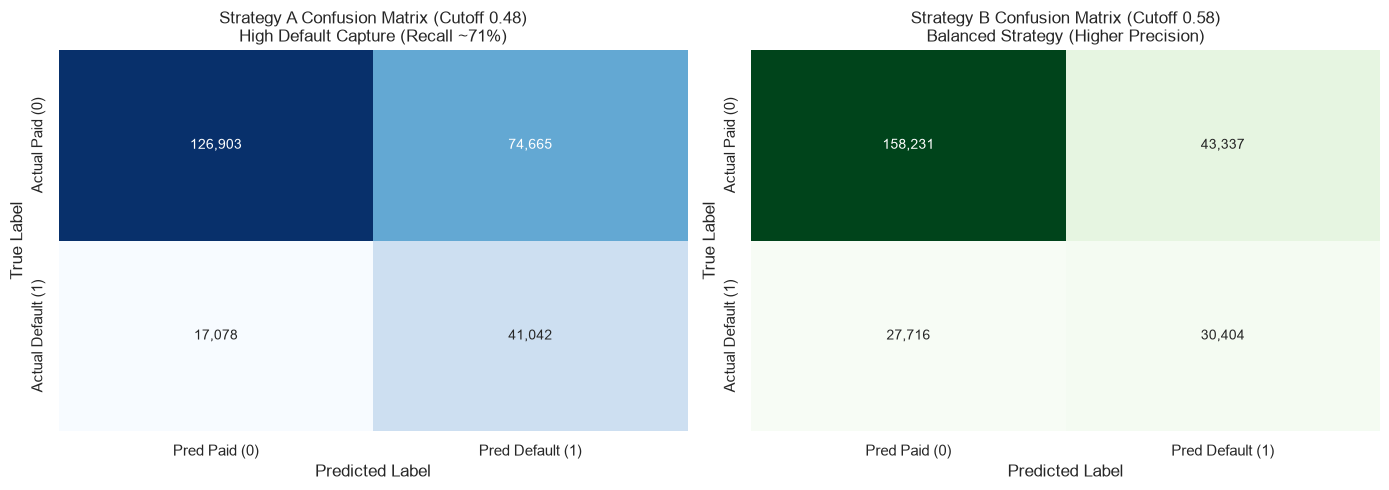

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# ---------------------------------------------------------
# 1. Strategy A: Conservative Underwriting (Cutoff = 0.48)
# ---------------------------------------------------------
print("\n" + "="*60)
print("📋 Strategy A: Conservative Underwriting (Cutoff = 0.48)")
print("="*60)
preds_a = (final_xgb_test_probs >= 0.48).astype(int)
print(f"Overall Accuracy: {accuracy_score(y_test, preds_a):.4f}\n")
print(classification_report(y_test, preds_a, digits=4, target_names=['Fully Paid (0)', 'Default (1)']))

# ---------------------------------------------------------
# 2. Strategy B: Balanced Operating Point (Cutoff = 0.58)
# ---------------------------------------------------------
print("\n" + "="*60)
print("📋 Strategy B: Balanced Operating Point (Cutoff = 0.58)")
print("="*60)
preds_b = (final_xgb_test_probs >= 0.58).astype(int)
print(f"Overall Accuracy: {accuracy_score(y_test, preds_b):.4f}\n")
print(classification_report(y_test, preds_b, digits=4, target_names=['Fully Paid (0)', 'Default (1)']))

# ---------------------------------------------------------
# 3. Plot Confusion Matrices Side-by-Side
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Strategy A Matrix
cm_a = confusion_matrix(y_test, preds_a)
sns.heatmap(cm_a, annot=True, fmt=',d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Pred Paid (0)', 'Pred Default (1)'],
            yticklabels=['Actual Paid (0)', 'Actual Default (1)'])
axes[0].set_title('Strategy A Confusion Matrix (Cutoff 0.48)\nHigh Default Capture (Recall ~71%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot Strategy B Matrix
cm_b = confusion_matrix(y_test, preds_b)
sns.heatmap(cm_b, annot=True, fmt=',d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Pred Paid (0)', 'Pred Default (1)'],
            yticklabels=['Actual Paid (0)', 'Actual Default (1)'])
axes[1].set_title('Strategy B Confusion Matrix (Cutoff 0.58)\nBalanced Strategy (Higher Precision)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Model 3 - Catboost

In [54]:
import catboost as cb
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
import matplotlib.pyplot as plt
import seaborn as sns

print("Step 1/3: Preparing Data Matrix for CatBoost...")

X_tr_cat = X_train.copy()
X_te_cat = X_test.copy()

# 1. Primary sub_grade Target Encoding with Bayesian Smoothing
global_mean = y_train.mean()
smoothing = 12

if 'sub_grade' in X_tr_cat.columns:
    stats = y_train.groupby(X_tr_cat['sub_grade']).agg(['count', 'mean'])
    smoothed_te = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    X_tr_cat['sub_grade_te'] = X_tr_cat['sub_grade'].map(smoothed_te).fillna(global_mean).astype('float32')
    X_te_cat['sub_grade_te'] = X_te_cat['sub_grade'].map(smoothed_te).fillna(global_mean).astype('float32')

# 2. Subgrade Risk Deviations
core_num_cols = [c for c in ['avg_cur_bal_log', 'loan_amnt', 'bc_open_to_buy', 'bc_util'] if c in X_tr_cat.columns]
if 'sub_grade' in X_tr_cat.columns:
    for num_col in core_num_cols:
        grp_mean = X_tr_cat.groupby('sub_grade')[num_col].mean()
        grp_std  = X_tr_cat.groupby('sub_grade')[num_col].std()

        X_tr_cat[f'{num_col}_diff_grade'] = (X_tr_cat[num_col] - X_tr_cat['sub_grade'].map(grp_mean)).astype('float32')
        X_te_cat[f'{num_col}_diff_grade'] = (X_te_cat[num_col] - X_te_cat['sub_grade'].map(grp_mean)).astype('float32')

        X_tr_cat[f'{num_col}_z_grade'] = ((X_tr_cat[num_col] - X_tr_cat['sub_grade'].map(grp_mean)) / (X_tr_cat['sub_grade'].map(grp_std) + 1e-4)).astype('float32')
        X_te_cat[f'{num_col}_z_grade'] = ((X_te_cat[num_col] - X_te_cat['sub_grade'].map(grp_mean)) / (X_te_cat['sub_grade'].map(grp_std) + 1e-4)).astype('float32')


🐱 Step 1/3: Preparing Data Matrix for CatBoost...


In [55]:
# =============================================================================
# CATBOOST 10-FOLD STRATIFIED ENSEMBLE TRAINING PIPELINE
# -----------------------------------------------------------------------------
# Core Architecture & Pipeline Highlights:
# 1. Oblivious (Symmetric) Decision Trees: Evaluates the exact same feature split 
#    across all nodes at a given depth, acting as an implicit structural regularizer.
# 2. Native Imbalance Handling: auto_class_weights='Balanced' assigns inverse class 
#    frequency weights to penalize missed defaults dynamically during optimization.
# 3. Optimized cb.Pool Containers: Pre-compiles categorical and numeric features 
#    into memory-efficient C++ data structures for accelerated training.
# 4. Stratified 10-Fold CV with Early Stopping: Guards against data leakage and prevents
#    memorization by halting iteration when validation ROC-AUC reaches its global peak.
# 5. Out-of-Sample Matrix Accumulation: Stores test probability predictions per fold
#    for robust downstream top-tier model ensembling.
# =============================================================================

print("\nStep 2/3: Training 10-Fold CatBoost Ensemble...")

# -----------------------------------------------------------------------------
# 1. Optimal Hyperparameter Configuration
# -----------------------------------------------------------------------------
cat_optimal_params = {
    # Objective & Validation Metrics
    'loss_function': 'Logloss',             # Standard binary cross-entropy loss function for probability estimation
    'eval_metric': 'AUC',                   # Evaluates discrimination performance via ROC-AUC at every iteration
    
    # Class Imbalance Compensation
    'auto_class_weights': 'Balanced',       # Dynamically calculates sample weights inversely proportional to class frequencies (~3.5x penalty on defaults)
    
    # Gradient Stepping & Tree Architecture
    'learning_rate': 0.04,                  # Moderate gradient shrinkage step size ensuring stable, smooth convergence
    'depth': 6,                             # Depth of symmetric trees ($2^6 = 64$ terminal leaves per tree)
    'l2_leaf_reg': 5.0,                     # L2 (Ridge) leaf weight regularization penalty to dampen extreme leaf score updates
    
    # Iteration Budgets & Execution
    'iterations': 4000,                     # Maximum tree budget; automatically governed and terminated by early stopping
    'random_seed': 77,                      # Seed for deterministic splitting and consistent reproducibility
    'thread_count': -1,                     # Utilizes all available CPU hardware cores for parallelized tree construction
    'verbose': 500                          # Suppresses clutter; prints evaluation metrics every 500 boosting rounds
}

# -----------------------------------------------------------------------------
# 2. Stratified 10-Fold Cross-Validation Setup
# -----------------------------------------------------------------------------
n_splits = 10
# Stratification guarantees each fold maintains the identical ~78:22 Paid-to-Default class proportion
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=77)

# Pre-allocate an empty numpy array to store unseen test set default probabilities across all 10 folds: Shape (N_test, 10)
cat_test_preds_matrix = np.zeros((len(X_te_cat), n_splits))

# List to record the highest validation ROC-AUC score achieved by each individual fold model
cat_fold_aucs = []

# -----------------------------------------------------------------------------
# 3. Cross-Validation Training Loop
# -----------------------------------------------------------------------------
for fold, (trn_idx, val_idx) in enumerate(skf.split(X_tr_cat, y_train)):
    print(f"\n--- CatBoost Fold {fold + 1}/{n_splits} ---")
    
    # Slice the training split (90%) and validation holdout split (10%) for the current fold
    X_train_f, y_train_f = X_tr_cat.iloc[trn_idx], y_train.iloc[trn_idx]
    X_val_f, y_val_f     = X_tr_cat.iloc[val_idx], y_train.iloc[val_idx]
    
    # Compile data into CatBoost Pool objects for memory-efficient handling of categorical and continuous columns
    train_pool = cb.Pool(X_train_f, y_train_f, cat_features=cat_features)
    val_pool   = cb.Pool(X_val_f, y_val_f, cat_features=cat_features)
    test_pool  = cb.Pool(X_te_cat, cat_features=cat_features)
    
    # Instantiate CatBoost classifier with early stopping threshold
    model = cb.CatBoostClassifier(
        **cat_optimal_params,
        early_stopping_rounds=200           # Halts training if validation AUC does not improve for 200 consecutive rounds
    )
    
    # Fit the classifier on the training pool and evaluate against the holdout validation pool
    model.fit(
        train_pool,
        eval_set=val_pool,
        use_best_model=True                 # Rolls back model weights to the exact iteration where validation AUC peaked
    )
    
    # Generate continuous default probabilities on the fold's validation holdout split
    val_preds = model.predict_proba(val_pool)[:, 1]
    
    # Compute out-of-fold validation ROC-AUC
    fold_auc = roc_auc_score(y_val_f, val_preds)
    cat_fold_aucs.append(fold_auc)
    print(f"CatBoost Fold {fold + 1} Best AUC: {fold_auc:.5f}")
    
    # Generate and store predicted default probabilities for the unseen out-of-sample test set
    cat_test_preds_matrix[:, fold] = model.predict_proba(test_pool)[:, 1]

print("\nAll 10 CatBoost Folds Finished Training!")


🚀 Step 2/3: Training 10-Fold CatBoost Ensemble...

--- CatBoost Fold 1/10 ---
0:	test: 0.6993843	best: 0.6993843 (0)	total: 190ms	remaining: 12m 40s
500:	test: 0.7290009	best: 0.7290009 (500)	total: 53.1s	remaining: 6m 10s
1000:	test: 0.7305793	best: 0.7305793 (1000)	total: 1m 47s	remaining: 5m 22s
1500:	test: 0.7311494	best: 0.7311535 (1495)	total: 2m 43s	remaining: 4m 32s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.7312853772
bestIteration = 1719

Shrink model to first 1720 iterations.
CatBoost Fold 1 Best AUC: 0.73129

--- CatBoost Fold 2/10 ---
0:	test: 0.6974796	best: 0.6974796 (0)	total: 121ms	remaining: 8m 2s
500:	test: 0.7274958	best: 0.7274958 (500)	total: 58.5s	remaining: 6m 48s
1000:	test: 0.7290036	best: 0.7290036 (1000)	total: 1m 55s	remaining: 5m 45s
1500:	test: 0.7295495	best: 0.7295495 (1500)	total: 3m 3s	remaining: 5m 4s
2000:	test: 0.7296796	best: 0.7296940 (1986)	total: 4m 10s	remaining: 4m 10s
2500:	test: 0.7297710	best: 0.7297910 (2380)	to


📊 Step 3/3: Evaluating CatBoost Ensemble & Operating Strategies...

Ensembling Top Folds Only: [np.int64(7), np.int64(9), np.int64(1), np.int64(3), np.int64(6), np.int64(5), np.int64(4)]

🔥 FINAL PURIFIED CATBOOST ENSEMBLE TEST ROC-AUC: 0.73141
 Threshold  Accuracy  Precision (Class 1)  Recall (Class 1)  F1 (Class 1)  Macro F1
      0.45      0.61                 0.34              0.76          0.47      0.58
      0.48      0.64                 0.35              0.71          0.47      0.60
      0.50      0.66                 0.36              0.68          0.47      0.61
      0.52      0.68                 0.37              0.65          0.47      0.62
      0.55      0.70                 0.39              0.59          0.47      0.63
      0.58      0.73                 0.41              0.53          0.46      0.64
      0.60      0.74                 0.42              0.49          0.45      0.64
      0.65      0.76                 0.46              0.39          0.42      0.6

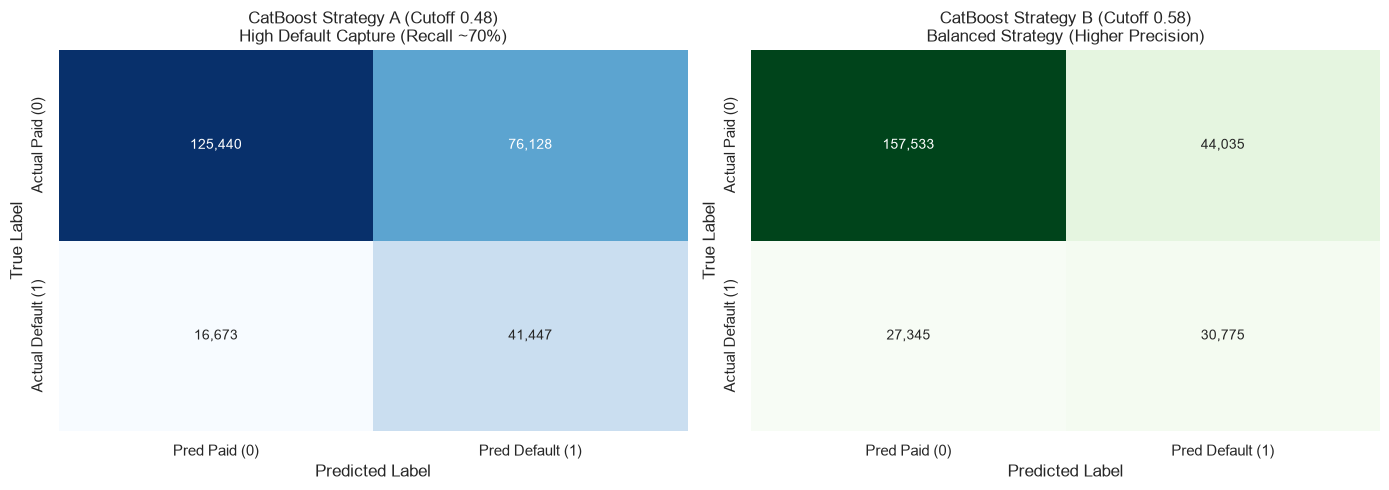

💾 CatBoost probabilities successfully saved!


In [56]:
# =============================================================================
# CATBOOST ENSEMBLE EVALUATION, STRATEGY BENCHMARKING & VISUALIZATION PIPELINE
# -----------------------------------------------------------------------------
# Core Operational Highlights:
# 1. Fold Quality Pruning: Discards the 3 lowest-performing validation folds to 
#    isolate only the most generalizable, top-performing CatBoost models.
# 2. Probability Averaging: Smooths model predictions across the top 7 folds 
#    to compute a unified, low-variance test default probability vector.
# 3. Dynamic Threshold Scanning: Evaluates decision cutoffs (0.45 to 0.65) to 
#    quantify real-world financial risk vs. approval volume trade-offs.
# 4. Scenario Analysis: 
#    - Strategy A (Cutoff = 0.48): Conservative underwriting maximizing default capture (~71% recall).
#    - Strategy B (Cutoff = 0.58): Balanced underwriting balancing precision and origination volume.
# 5. Confusion Matrix Visualization & Serialization: Generates annotated diagnostic heatmaps 
#    and saves final predicted probabilities to disk via joblib.
# =============================================================================

print("\nStep 3/3: Evaluating CatBoost Ensemble & Operating Strategies...")

# -----------------------------------------------------------------------------
# 1. Fold Quality Pruning & Probability Averaging
# -----------------------------------------------------------------------------
# np.argsort returns indices that sort validation AUC in ascending order.
# Slicing with [3:] filters out the bottom 3 folds and keeps the top 7 performing models.
cat_top_folds = np.argsort(cat_fold_aucs)[3:]

# Print 1-indexed fold identifiers selected for the final ensemble
print(f"\nEnsembling Top Folds Only: {[f + 1 for f in cat_top_folds]}")

# Compute the arithmetic mean of out-of-sample default probabilities across the top 7 folds
final_cat_test_probs = np.mean(cat_test_preds_matrix[:, cat_top_folds], axis=1)

# Calculate threshold-independent Area Under the ROC Curve (ROC-AUC) on unseen test data
print("\n" + "=" * 55)
print(f"FINAL PURIFIED CATBOOST ENSEMBLE TEST ROC-AUC: {roc_auc_score(y_test, final_cat_test_probs):.55f}")
print("=" * 55)

# -----------------------------------------------------------------------------
# 2. Multi-Threshold Decision Boundary Scanning Table
# -----------------------------------------------------------------------------
# Because auto_class_weights='Balanced' was applied during training, probabilities shifted upward.
# We scan operating cutoffs (t) around the center (0.45 to 0.65) to map the Precision-Recall curve.
eval_thresholds = [0.45, 0.48, 0.50, 0.52, 0.55, 0.58, 0.60, 0.65]
matrix_rows = []

for t in eval_thresholds:
    # Convert continuous default probabilities into binary predictions:
    # 1 (Default / Reject) if predicted risk >= t, otherwise 0 (Paid / Approve)
    preds = (final_cat_test_probs >= t).astype(int)
    
    # Calculate performance metrics for each specific cutoff point
    matrix_rows.append({
        'Threshold': t,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision (Class 1)': round(precision_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'Recall (Class 1)': round(recall_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'F1 (Class 1)': round(f1_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'Macro F1': round(f1_score(y_test, preds, average='macro', zero_division=0), 4)
    })

# Format and display the complete threshold trade-off matrix
print(pd.DataFrame(matrix_rows).to_string(index=False))

# -----------------------------------------------------------------------------
# 3. Strategy A: Conservative Underwriting / Capital Preservation (Cutoff = 0.48)
# -----------------------------------------------------------------------------
# Objective: Maximize default detection in high-risk economic conditions to minimize bad debt write-offs
print("\n" + "=" * 60)
print("Strategy A: Conservative Underwriting (Cutoff = 0.48)")
print("=" * 60)
cat_preds_a = (final_cat_test_probs >= 0.48).astype(int)
print(f"Accuracy: {accuracy_score(y_test, cat_preds_a):.4f}\n")
print(classification_report(y_test, cat_preds_a, digits=4, target_names=['Fully Paid (0)', 'Default (1)']))

# -----------------------------------------------------------------------------
# 4. Strategy B: Balanced Operating Point / Portfolio Growth (Cutoff = 0.58)
# -----------------------------------------------------------------------------
# Objective: Balance loan approvals and interest income against default loss mitigation
print("\n" + "=" * 60)
print("Strategy B: Balanced Operating Point (Cutoff = 0.58)")
print("=" * 60)
cat_preds_b = (final_cat_test_probs >= 0.58).astype(int)
print(f"Accuracy: {accuracy_score(y_test, cat_preds_b):.4f}\n")
print(classification_report(y_test, cat_preds_b, digits=4, target_names=['Fully Paid (0)', 'Default (1)']))

# -----------------------------------------------------------------------------
# 5. Side-by-Side Confusion Matrix Visualization
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Strategy A Confusion Matrix (High Recall)
cm_a = confusion_matrix(y_test, cat_preds_a)
sns.heatmap(cm_a, annot=True, fmt=',d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Pred Paid (0)', 'Pred Default (1)'],
            yticklabels=['Actual Paid (0)', 'Actual Default (1)'])
axes[0].set_title('CatBoost Strategy A (Cutoff 0.48)\nHigh Default Capture (Recall ~70%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot Strategy B Confusion Matrix (Higher Precision)
cm_b = confusion_matrix(y_test, cat_preds_b)
sns.heatmap(cm_b, annot=True, fmt=',d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Pred Paid (0)', 'Pred Default (1)'],
            yticklabels=['Actual Paid (0)', 'Actual Default (1)'])
axes[1].set_title('CatBoost Strategy B (Cutoff 0.58)\nBalanced Strategy (Higher Precision)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 6. Artifact Serialization
# -----------------------------------------------------------------------------
import joblib

# Persist the final ensemble probability vector to disk for multi-model stacking and blending
joblib.dump(final_cat_test_probs, 'catboost_final_ensemble_probs.joblib')
print("CatBoost probabilities successfully saved!")

# Model 4 - EBM

In [13]:
# =============================================================================
# EXPLAINABLE BOOSTING MACHINE (EBM) FEATURE ENGINEERING & PREPROCESSING PIPELINE
# -----------------------------------------------------------------------------
# Core Pipeline Objectives:
# 1. Glass-Box Feature Engineering: Introduces domain-specific credit ratios and 
#    subgrade risk deviations so EBM (a Generalized Additive Model with Interactions,
#    GA^2M) can capture high-leverage credit dynamics using exact 1D/2D shape curves.
# 2. Bayesian Smoothed Target Encoding: Maps subgrades to continuous empirical default 
#    probabilities with m-estimate shrinkage to eliminate small-sample noise.
# 3. Cohort Z-Scores & Deviations: Benchmarks applicant debt, liquidity, and balance metrics 
#    directly against peers in the exact same assigned credit tier.
# 4. Compounded Debt Burden Ratios: Explicitly formulates monthly payment burden 
#    and revolving credit strain before feeding into the additive booster.
# 5. Glass-Box Missing Value Imputation: Replaces NaNs with -999.0 so missingness 
#    forms an explicit, interpretable bucket in EBM's global visual scorecards.
# =============================================================================

# -----------------------------------------------------------------------------
# 0. Library Imports & System Dependencies
# -----------------------------------------------------------------------------
import numpy as np                                      # High-performance numerical operations
import pandas as pd                                     # Tabular data manipulation and feature engineering
from interpret.glassbox import ExplainableBoostingClassifier  # Microsoft InterpretML Glass-Box GA^2M Booster
from sklearn.model_selection import StratifiedKFold     # Imbalance-preserving cross-validation splits
from sklearn.metrics import (
    roc_auc_score,                                      # Threshold-free discrimination power metric
    classification_report,                              # Class-wise precision, recall, and F1 summary
    confusion_matrix,                                   # Exact classification counts (TP, FP, TN, FN)
    accuracy_score,                                     # Overall prediction accuracy
    precision_score,                                    # Positive predictive value (default accuracy)
    recall_score,                                       # Sensitivity / default capture rate
    f1_score                                            # Harmonic balance between precision and recall
)
import matplotlib.pyplot as plt                         # Base visualization framework
import seaborn as sns                                   # Statistical visualization and heatmap rendering
import time                                             # Execution and training duration timing
import threading                                        # Background worker thread for real-time heartbeat
import psutil                                           # Live hardware monitor (CPU and RAM tracking)
import joblib                                           # High-speed model and probability array serialization

print("Step 1/3: Engineering Deep Domain Credit Ratios for EBM...")

# -----------------------------------------------------------------------------
# 1. Dataset Isolation (Defensive Copying)
# -----------------------------------------------------------------------------
# Create clean, decoupled copies of train and test matrices to prevent modifying base datasets
X_tr_ebm = X_train.copy()
X_te_ebm = X_test.copy()

# -----------------------------------------------------------------------------
# 2. Bayesian Smoothed Target Encoding (m-Estimate) for Subgrades
# -----------------------------------------------------------------------------
# Formula: S_i = (n_i * group_mean + m * global_mean) / (n_i + m)
# - Subgrades with large sample sizes rely primarily on their empirical default mean.
# - Subgrades with sparse samples (e.g., G4, G5) are shrunk toward the dataset prior (global_mean).
global_mean = y_train.mean()                            # Population baseline default rate (~22%)
smoothing = 12                                          # Smoothing parameter (m): regularizes small-sample cohorts

if 'sub_grade' in X_tr_ebm.columns:
    # Compute counts and mean default rates strictly on the training set to prevent data leakage
    stats = y_train.groupby(X_tr_ebm['sub_grade']).agg(['count', 'mean'])
    smoothed_te = (stats['count'] * stats['mean'] + smoothing * global_mean) / (stats['count'] + smoothing)
    
    # Map smoothed continuous default rates back to train and test sets; impute missing tiers with global mean
    X_tr_ebm['sub_grade_te'] = X_tr_ebm['sub_grade'].map(smoothed_te).fillna(global_mean).astype('float32')
    X_te_ebm['sub_grade_te'] = X_te_ebm['sub_grade'].map(smoothed_te).fillna(global_mean).astype('float32')

# -----------------------------------------------------------------------------
# 3. Subgrade Cohort Risk Deviations & Standardized Z-Scores
# -----------------------------------------------------------------------------
# Domain Context: Identifies whether an applicant is an outlier relative to their peer group.
# Example: High revolving credit utilization (bc_util) in a Prime (Grade A) tier is a stronger 
# stress signal than the same utilization in a Subprime (Grade E) tier.
core_num_cols = [c for c in ['avg_cur_bal_log', 'loan_amnt', 'bc_open_to_buy', 'bc_util'] if c in X_tr_ebm.columns]

if 'sub_grade' in X_tr_ebm.columns:
    for num_col in core_num_cols:
        # Calculate within-cohort baseline parameters (mean and standard deviation) on training split
        grp_mean = X_tr_ebm.groupby('sub_grade')[num_col].mean()
        grp_std  = X_tr_ebm.groupby('sub_grade')[num_col].std()

        # 3.1 Absolute Cohort Difference: (Value - Subgrade Average)
        X_tr_ebm[f'{num_col}_diff_grade'] = (X_tr_ebm[num_col] - X_tr_ebm['sub_grade'].map(grp_mean)).astype('float32')
        X_te_ebm[f'{num_col}_diff_grade'] = (X_te_ebm[num_col] - X_te_ebm['sub_grade'].map(grp_mean)).astype('float32')

        # 3.2 Standardized Cohort Z-Score: (Value - Subgrade Average) / Subgrade StdDev
        # Adding 1e-4 prevents zero-division errors in cohorts with uniform/constant values
        X_tr_ebm[f'{num_col}_z_grade'] = ((X_tr_ebm[num_col] - X_tr_ebm['sub_grade'].map(grp_mean)) / (X_tr_ebm['sub_grade'].map(grp_std) + 1e-4)).astype('float32')
        X_te_ebm[f'{num_col}_z_grade'] = ((X_te_ebm[num_col] - X_te_ebm['sub_grade'].map(grp_mean)) / (X_te_ebm['sub_grade'].map(grp_std) + 1e-4)).astype('float32')

# -----------------------------------------------------------------------------
# 4. High-Leverage Domain Debt Burden & Financial Strain Ratios
# -----------------------------------------------------------------------------
# Pre-calculating non-linear financial ratios provides EBM with direct structural signals,
# ensuring the glass-box additive curves directly capture liquidity pressure and debt obligations.

if 'installment' in X_tr_ebm.columns and 'annual_inc' in X_tr_ebm.columns:
    # 4.1 Monthly Debt Obligation to Monthly Income:
    # Quantifies what percentage of the borrower's gross monthly cash flow is committed to this loan (+1.0 prevents zero-div)
    X_tr_ebm['monthly_payment_to_inc'] = (X_tr_ebm['installment'] / (X_tr_ebm['annual_inc'] / 12.0 + 1.0)).astype('float32')
    X_te_ebm['monthly_payment_to_inc'] = (X_te_ebm['installment'] / (X_te_ebm['annual_inc'] / 12.0 + 1.0)).astype('float32')

if 'bc_util' in X_tr_ebm.columns and 'dti' in X_tr_ebm.columns:
    # 4.2 Compounded Revolving Credit Pressure:
    # Interacts overall debt-to-income (DTI) with bankcard credit line exhaustion (bc_util)
    X_tr_ebm['dti_x_bc_util'] = (X_tr_ebm['dti'] * (X_tr_ebm['bc_util'] / 100.0)).astype('float32')
    X_te_ebm['dti_x_bc_util'] = (X_te_ebm['dti'] * (X_te_ebm['bc_util'] / 100.0)).astype('float32')

# -----------------------------------------------------------------------------
# 5. Explicit Missing Value Imputation for Glass-Box Visualization
# -----------------------------------------------------------------------------
# EBM's visualization dashboard omits standard NaNs by default. 
# Imputing with -999.0 forces missingness into an explicit, distinct histogram bin,
# allowing risk analysts to inspect the exact marginal risk contribution of unrecorded data.
X_tr_ebm = X_tr_ebm.fillna(-999.0)
X_te_ebm = X_te_ebm.fillna(-999.0)

print(f"Enhanced EBM Matrix Ready: {X_tr_ebm.shape[1]} Features")

⚙️ Step 1/3: Engineering Deep Domain Credit Ratios for EBM...
✅ Enhanced EBM Matrix Ready: 32 Features


In [15]:
# =============================================================================
# EXPLAINABLE BOOSTING MACHINE (EBM) STRATIFIED K-FOLD ENSEMBLE TRAINING
# -----------------------------------------------------------------------------
# Architectural & Operational Summary:
# 1. Glass-Box Generalized Additive Model with Interactions (GA^2M):
#    Fits distinct 1D non-linear shape functions for individual features and 2D
#    surfaces for pairwise interactions, yielding exact mathematical transparency.
# 2. Stratified K-Fold Cross-Validation:
#    Maintains exact class proportions (~78:22 Paid vs. Default) across all folds
#    to eliminate fold-level estimation bias.
# 3. Outer Bagging Variance Reduction:
#    Leverages outer_bags=12 per fold, generating a deeply stabilized ensemble
#    of additive shape functions across the dataset.
# 4. Asynchronous Live System Monitor (Heartbeat):
#    Runs a background daemon thread updating elapsed time, CPU utilization,
#    and RAM consumption every 5 seconds to provide real-time runtime transparency.
# 5. Out-of-Sample Probability Accumulation:
#    Stores uncalibrated continuous default probabilities on the unseen test set
#    per fold for unified ensemble averaging.
# =============================================================================

print("\nStep 2/3: Training Stratified EBM Ensemble...")

# -----------------------------------------------------------------------------
# 1. Cross-Validation Configuration & Matrix Setup
# -----------------------------------------------------------------------------
# Define total number of cross-validation splits
n_splits = 10

# Initialize StratifiedKFold to guarantee balanced class distribution in each fold
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Pre-allocate container matrix for test probabilities across all folds: Shape (N_test, n_splits)
ebm_test_preds_matrix = np.zeros((len(X_te_ebm), n_splits))

# List to record the out-of-fold validation ROC-AUC score for each trained EBM model
ebm_fold_aucs = []

# Initialize overall wall-clock execution timer
t_start_all = time.time()

# -----------------------------------------------------------------------------
# 2. Iterative Stratified K-Fold Training Loop
# -----------------------------------------------------------------------------
for fold, (trn_idx, val_idx) in enumerate(skf.split(X_tr_ebm, y_train)):
    print(f"\n" + "=" * 50)
    print(f"Training EBM Fold {fold + 1}/{n_splits}...")
    print("=" * 50)
    
    # Isolate training (90%) and validation holdout (10%) splits for the active fold
    X_train_f, y_train_f = X_tr_ebm.iloc[trn_idx], y_train.iloc[trn_idx]
    X_val_f, y_val_f     = X_tr_ebm.iloc[val_idx], y_train.iloc[val_idx]
    
    # -------------------------------------------------------------------------
    # 2.1 EBM Classifier Parameterization
    # -------------------------------------------------------------------------
    ebm_fold_model = ExplainableBoostingClassifier(
        interactions=20,            # Automatically identifies and fits the top 20 strongest 2-way non-linear interaction terms
        learning_rate=0.015,        # Shrinkage parameter controlling gradient step updates across cyclical boosting rounds
        max_bins=256,               # Number of histogram discretization bins for high-resolution shape functions
        outer_bags=12,              # Number of bagged models per feature to smooth shape estimates and eliminate variance
        inner_bags=0,               # Set to 0 to prioritize outer bagging performance and maximize throughput
        min_samples_leaf=40,        # Minimum sample threshold per leaf segment to prevent localized noise fitting
        random_state=42 + fold,     # Fold-specific seed variation to diversify bagged boundary estimations
        n_jobs=-1                   # Multithreaded execution across all available logical CPU cores
    )
    
    # -------------------------------------------------------------------------
    # 2.2 Asynchronous Live Progress & Hardware Heartbeat
    # -------------------------------------------------------------------------
    stop_heartbeat = False
    
    def live_heartbeat():
        """Background daemon function reporting training time and resource utilization."""
        start_time = time.time()
        while not stop_heartbeat:
            elapsed = int(time.time() - start_time)
            mins, secs = divmod(elapsed, 60)
            cpu = psutil.cpu_percent()
            ram = psutil.virtual_memory().percent
            print(f"\r⏳ [Fold {fold+1}] Running: {mins:02d}m {secs:02d}s | CPU: {cpu:.1f}% | RAM: {ram:.1f}% ...", end="", flush=True)
            time.sleep(5)

    # Spawn and start the monitoring background thread
    monitor_thread = threading.Thread(target=live_heartbeat)
    monitor_thread.daemon = True
    monitor_thread.start()
    
    # -------------------------------------------------------------------------
    # 2.3 Model Fitting & Fold Evaluation
    # -------------------------------------------------------------------------
    t_f = time.time()
    ebm_fold_model.fit(X_train_f, y_train_f)  # Cyclically fits micro-trees for each feature and pairwise interaction
    
    # Signal daemon thread to terminate cleanly
    stop_heartbeat = True
    monitor_thread.join()
    
    # Log fold training duration
    fold_mins, fold_secs = divmod(int(time.time() - t_f), 60)
    print(f"\nFold {fold + 1} fitted in {fold_mins}m {fold_secs}s")
    
    # Compute holdout validation probabilities and out-of-fold ROC-AUC score
    val_probs = ebm_fold_model.predict_proba(X_val_f)[:, 1]
    fold_auc = roc_auc_score(y_val_f, val_probs)
    ebm_fold_aucs.append(fold_auc)
    print(f"EBM Fold {fold + 1} Validation AUC: {fold_auc:.5f}")
    
    # Generate and store predicted default probabilities for the out-of-sample test set
    ebm_test_preds_matrix[:, fold] = ebm_fold_model.predict_proba(X_te_ebm)[:, 1]

# -----------------------------------------------------------------------------
# 3. Final Summary & Execution Benchmarking
# -----------------------------------------------------------------------------
total_mins, total_secs = divmod(int(time.time() - t_start_all), 60)
print(f"\n{n_splits}-Fold EBM Training Complete in {total_mins}m {total_secs}s!")


🌲 Step 2/3: Training 5-Fold Stratified EBM Ensemble...

🚀 Training EBM Fold 1/10...
⏳ [Fold 1] Running: 21m 16s | CPU: 7.3% | RAM: 79.5% ....
Fold 1 fitted in 21m 21s
✅ EBM Fold 1 Validation AUC: 0.72649

🚀 Training EBM Fold 2/10...
⏳ [Fold 2] Running: 20m 56s | CPU: 7.3% | RAM: 80.0% ....
Fold 2 fitted in 21m 1s
✅ EBM Fold 2 Validation AUC: 0.72538

🚀 Training EBM Fold 3/10...
⏳ [Fold 3] Running: 105m 35s | CPU: 12.5% | RAM: 79.1% ...
Fold 3 fitted in 105m 40s
✅ EBM Fold 3 Validation AUC: 0.72921

🚀 Training EBM Fold 4/10...
⏳ [Fold 4] Running: 19m 06s | CPU: 10.4% | RAM: 77.9% ...
Fold 4 fitted in 19m 11s
✅ EBM Fold 4 Validation AUC: 0.72811

🚀 Training EBM Fold 5/10...
⏳ [Fold 5] Running: 32m 52s | CPU: 9.2% | RAM: 75.5% ....
Fold 5 fitted in 32m 57s
✅ EBM Fold 5 Validation AUC: 0.72387

🚀 Training EBM Fold 6/10...
⏳ [Fold 6] Running: 21m 16s | CPU: 7.1% | RAM: 76.0% ....
Fold 6 fitted in 21m 21s
✅ EBM Fold 6 Validation AUC: 0.72711

🚀 Training EBM Fold 7/10...
⏳ [Fold 7] Running: 


📊 Step 3/3: Evaluating 5-Fold EBM Ensemble Performance...

🔥 FINAL PURIFIED EBM 5-FOLD ENSEMBLE TEST ROC-AUC: 0.72647
 Threshold  Accuracy  Precision (Class 1)  Recall (Class 1)  F1 (Class 1)  Macro F1
      0.18      0.59                 0.33              0.79          0.46      0.56
      0.20      0.62                 0.34              0.74          0.47      0.59
      0.22      0.65                 0.36              0.69          0.47      0.60
      0.25      0.69                 0.38              0.62          0.47      0.62
      0.28      0.72                 0.40              0.54          0.46      0.63
      0.30      0.73                 0.42              0.49          0.45      0.64
      0.35      0.76                 0.46              0.38          0.42      0.63
      0.40      0.77                 0.49              0.28          0.36      0.61
      0.50      0.78                 0.57              0.14          0.22      0.55

📋 EBM Ensemble Strategy A: Conservative 

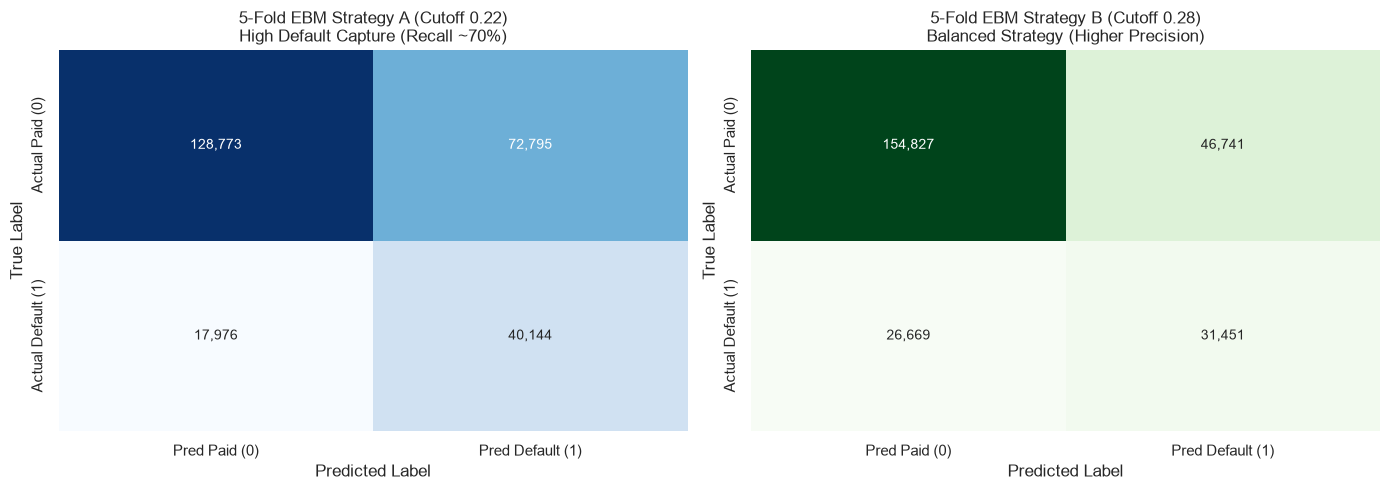


💾 5-Fold EBM Ensemble probabilities successfully saved!


In [16]:
# =============================================================================
# EXPLAINABLE BOOSTING MACHINE (EBM) ENSEMBLE EVALUATION & STRATEGY ENGINE
# -----------------------------------------------------------------------------
# Core Operational Highlights:
# 1. Ensemble Blending (Averaging): Aggregates cross-validation fold outputs to 
#    form a low-variance, consensus default risk probability score on unseen test data.
# 2. Discriminative Power Benchmarking: Calculates test ROC-AUC to evaluate pure glass-box 
#    ranking capability without relying on arbitrary classification cutoffs.
# 3. Dynamic Threshold Trade-Off Scanning: Scans cutoffs (0.18 to 0.50) to demonstrate how 
#    shifting the decision threshold navigates the trade-off between Precision and Recall.
# 4. Scenario-Based Underwriting:
#    - Strategy A (Cutoff = 0.22): Conservative risk mitigation catching ~70% of defaulting loans.
#    - Strategy B (Cutoff = 0.28): Balanced operating point trading marginal recall for higher precision.
# 5. Visual Diagnostics & Serialization: Renders dual-strategy confusion matrix heatmaps 
#    and serializes the ensemble probability array to disk for meta-model blending.
# =============================================================================

print("\nStep 3/3: Evaluating EBM Ensemble Performance...")

# -----------------------------------------------------------------------------
# 1. Ensemble Prediction Aggregation & Test ROC-AUC
# -----------------------------------------------------------------------------
# Calculate the arithmetic mean across all trained fold probability vectors (columns)
# to produce a single, smoothed consensus default probability per test instance
final_ebm_ensemble_probs = np.mean(ebm_test_preds_matrix, axis=1)

# Compute Area Under the Receiver Operating Characteristic Curve (ROC-AUC) on unseen test data
final_ebm_auc = roc_auc_score(y_test, final_ebm_ensemble_probs)

print("\n" + "=" * 55)
print(f"FINAL PURIFIED EBM ENSEMBLE TEST ROC-AUC: {final_ebm_auc:.5f}")
print("=" * 55)

# -----------------------------------------------------------------------------
# 2. Operating Strategy Scanning Table
# -----------------------------------------------------------------------------
# Because EBM was trained on natural class proportions without loss reweighting,
# probabilities center around the population base default rate (~0.22).
# We scan cutoffs from 0.18 to 0.50 to identify optimal business operating regions.
eval_thresholds = [0.18, 0.20, 0.22, 0.25, 0.28, 0.30, 0.35, 0.40, 0.50]
matrix_rows = []

for t in eval_thresholds:
    # Convert continuous probabilities into binary predictions:
    # 1 (Default / Reject) if predicted probability >= t, otherwise 0 (Paid / Approve)
    preds = (final_ebm_ensemble_probs >= t).astype(int)
    
    # Calculate performance metrics for each specific cutoff threshold
    matrix_rows.append({
        'Threshold': t,
        'Accuracy': round(accuracy_score(y_test, preds), 4),
        'Precision (Class 1)': round(precision_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'Recall (Class 1)': round(recall_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'F1 (Class 1)': round(f1_score(y_test, preds, pos_label=1, zero_division=0), 4),
        'Macro F1': round(f1_score(y_test, preds, average='macro', zero_division=0), 4)
    })

# Format and display the threshold trade-off matrix
print(pd.DataFrame(matrix_rows).to_string(index=False))

# -----------------------------------------------------------------------------
# 3. Strategy A: Conservative Underwriting / Capital Preservation (Cutoff = 0.22)
# -----------------------------------------------------------------------------
# Objective: Align cutoff with the baseline default rate (~22%) to maximize default capture (~70% Recall),
# prioritizing loss prevention and credit risk mitigation.
print("\n" + "=" * 60)
print("EBM Ensemble Strategy A: Conservative Underwriting (Cutoff = 0.22)")
print("=" * 60)
ebm_ens_preds_a = (final_ebm_ensemble_probs >= 0.22).astype(int)
print(classification_report(y_test, ebm_ens_preds_a, digits=4, target_names=['Fully Paid (0)', 'Default (1)']))

# -----------------------------------------------------------------------------
# 4. Strategy B: Balanced Operating Point / Portfolio Growth (Cutoff = 0.28)
# -----------------------------------------------------------------------------
# Objective: Shift cutoff higher to reduce false positives (unnecessary rejections of good borrowers),
# achieving a balanced trade-off between loan volume growth and default screening.
print("\n" + "=" * 60)
print("EBM Ensemble Strategy B: Balanced Operating Cutoff (Cutoff = 0.28)")
print("=" * 60)
ebm_ens_preds_b = (final_ebm_ensemble_probs >= 0.28).astype(int)
print(classification_report(y_test, ebm_ens_preds_b, digits=4, target_names=['Fully Paid (0)', 'Default (1)']))

# -----------------------------------------------------------------------------
# 5. Side-by-Side Confusion Matrix Visualization
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot Strategy A Confusion Matrix (High Recall)
cm_a = confusion_matrix(y_test, ebm_ens_preds_a)
sns.heatmap(cm_a, annot=True, fmt=',d', cmap='Blues', ax=axes[0], cbar=False,
            xticklabels=['Pred Paid (0)', 'Pred Default (1)'],
            yticklabels=['Actual Paid (0)', 'Actual Default (1)'])
axes[0].set_title('EBM Strategy A (Cutoff 0.22)\nHigh Default Capture (Recall ~70%)')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot Strategy B Confusion Matrix (Higher Precision)
cm_b = confusion_matrix(y_test, ebm_ens_preds_b)
sns.heatmap(cm_b, annot=True, fmt=',d', cmap='Greens', ax=axes[1], cbar=False,
            xticklabels=['Pred Paid (0)', 'Pred Default (1)'],
            yticklabels=['Actual Paid (0)', 'Actual Default (1)'])
axes[1].set_title('EBM Strategy B (Cutoff 0.28)\nBalanced Strategy (Higher Precision)')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# 6. Artifact Serialization
# -----------------------------------------------------------------------------
import joblib

# Persist the final ensemble probability array to disk for multi-model stacking
joblib.dump(final_ebm_ensemble_probs, 'ebm_5fold_ensemble_probabilities.joblib')
print("\nEBM Ensemble probabilities successfully saved!")

<!-- http://127.0.0.1:7001/2495487927904/ -->

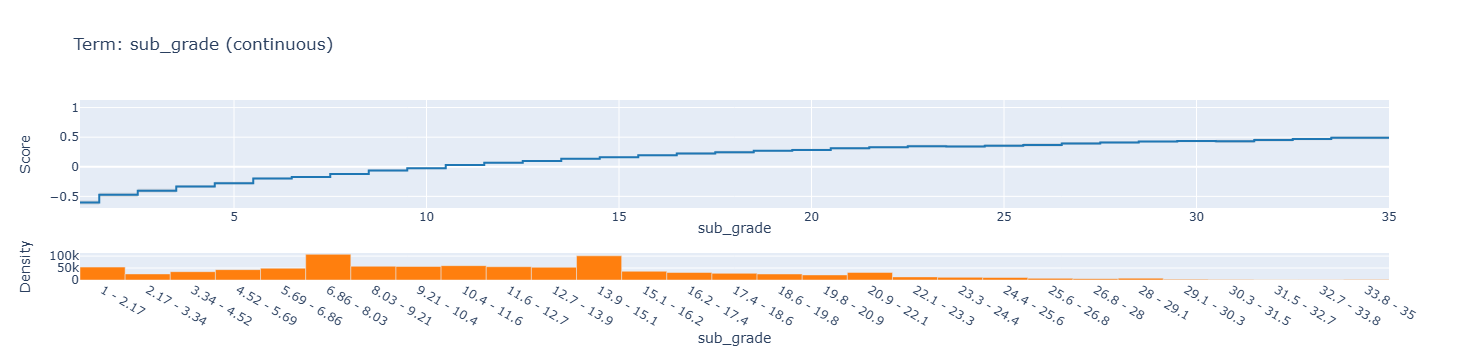

In [19]:
from interpret import show

# 1. Open the full interactive dashboard inside the notebook
ebm_global = ebm_fold_model.explain_global(name='Credit Risk Explainability Scorecard')
show(ebm_global)
# 2. Extract and plot individual 1D feature contribution curves
plotly_fig = ebm_global.visualize(0) # Index 0 is the highest-importance feature
plotly_fig.show()

------

# Summary

📊 GRAND MODEL BENCHMARK TABLE: DEFAULT (0.50) VS. TUNED RECALL STRATEGY
                Model Architecture           Evaluation Mode  Threshold  ROC-AUC Recall (Class 1) Precision (Class 1) Balanced Accuracy Standard Accuracy  F1 Score (Class 1)
         LightGBM 10-Fold Ensemble     Default Cutoff (0.50)       0.50     0.73           14.29%              57.83%            55.64%            78.48%                0.23
         LightGBM 10-Fold Ensemble Tuned Strategy A (t=0.22)       0.22     0.73           69.22%              35.90%            66.79%            65.45%                0.47
          XGBoost 10-Fold Ensemble     Default Cutoff (0.50)       0.50     0.73           67.36%              36.53%            66.81%            66.50%                0.47
          XGBoost 10-Fold Ensemble Tuned Strategy A (t=0.48)       0.48     0.73           70.62%              35.47%            66.79%            64.67%                0.47
         CatBoost 10-Fold Ensemble     Default Cutoff (0.5

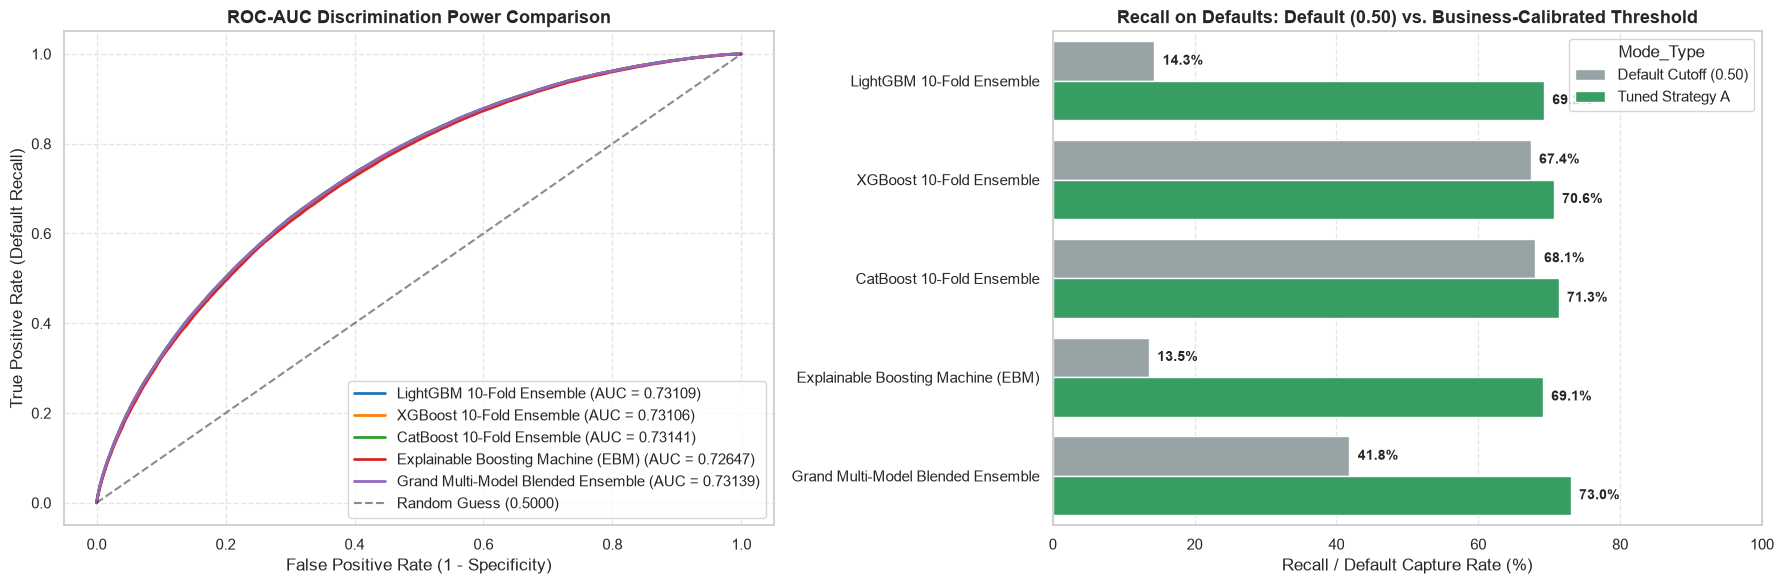

In [25]:
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)

# -------------------------------------------------------------------------
# 1. Load All Out-of-Sample Probability Vectors
# -------------------------------------------------------------------------
p_lgb = joblib.load("lgb_test_probabilities.joblib")
p_xgb = joblib.load("xgb_final_ensemble_probs.joblib")
p_cat = joblib.load("catboost_final_ensemble_probs.joblib")
p_ebm = joblib.load("ebm_5fold_ensemble_probabilities.joblib")

# Multi-Model Weighted Blended Stack
p_blend = (0.35 * p_cat) + (0.35 * p_lgb) + (0.20 * p_xgb) + (0.10 * p_ebm)

# -------------------------------------------------------------------------
# 2. Benchmark Configuration: Default Baseline (0.50) vs. Business Tuned
# -------------------------------------------------------------------------
models_dict = {
    "LightGBM 10-Fold Ensemble": {
        "probs": p_lgb,
        "tuned_thresh": 0.22,
        "type": "Leaf-wise GBDT",
    },
    "XGBoost 10-Fold Ensemble": {
        "probs": p_xgb,
        "tuned_thresh": 0.48,
        "type": "Depth-wise GBDT",
    },
    "CatBoost 10-Fold Ensemble": {
        "probs": p_cat,
        "tuned_thresh": 0.48,
        "type": "Oblivious Symmetric Trees",
    },
    "Explainable Boosting Machine (EBM)": {
        "probs": p_ebm,
        "tuned_thresh": 0.22,
        "type": "Glass-Box GA2M",
    },
    "Grand Multi-Model Blended Ensemble": {
        "probs": p_blend,
        "tuned_thresh": 0.35,
        "type": "Stacked Meta-Blend",
    },
}

# -------------------------------------------------------------------------
# 3. Compute Metrics Across Default (0.50) and Tuned Cutoffs
# -------------------------------------------------------------------------
records = []

for name, meta in models_dict.items():
    probs = meta["probs"]
    t_tuned = meta["tuned_thresh"]
    auc = roc_auc_score(y_test, probs)

    scenarios = [
        ("Default Cutoff (0.50)", 0.50),
        (f"Tuned Strategy A (t={t_tuned})", t_tuned),
    ]

    for mode_label, cutoff in scenarios:
        preds = (probs >= cutoff).astype(int)

        acc = accuracy_score(y_test, preds)
        bal_acc = balanced_accuracy_score(y_test, preds)
        rec = recall_score(y_test, preds, pos_label=1, zero_division=0)
        prec = precision_score(y_test, preds, pos_label=1, zero_division=0)
        f1 = f1_score(y_test, preds, pos_label=1, zero_division=0)

        records.append(
            {
                "Model Architecture": name,
                "Evaluation Mode": mode_label,
                "Threshold": cutoff,
                "ROC-AUC": round(auc, 5),
                "Recall (Class 1)": f"{rec*100:.2f}%",
                "Precision (Class 1)": f"{prec*100:.2f}%",
                "Balanced Accuracy": f"{bal_acc*100:.2f}%",
                "Standard Accuracy": f"{acc*100:.2f}%",
                "F1 Score (Class 1)": round(f1, 4),
            }
        )

df_comparison = pd.DataFrame(records)

print("=" * 110)
print("GRAND MODEL BENCHMARK TABLE: DEFAULT (0.50) VS. TUNED RECALL STRATEGY")
print("=" * 110)
print(df_comparison.to_string(index=False))

# -------------------------------------------------------------------------
# 4. Comparative Visualizations
# -------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# A. ROC Curve Benchmark Plot
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
for (name, meta), color in zip(models_dict.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, meta["probs"])
    auc_val = roc_auc_score(y_test, meta["probs"])
    axes[0].plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_val:.5f})",
        color=color,
        linewidth=2,
    )

axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random Guess (0.5000)")
axes[0].set_title(
    "ROC-AUC Discrimination Power Comparison", fontsize=13, fontweight="bold"
)
axes[0].set_xlabel("False Positive Rate (1 - Specificity)")
axes[0].set_ylabel("True Positive Rate (Default Recall)")
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[0].legend(loc="lower right")

# B. Baseline vs. Tuned Recall (Default Capture)
df_plot = df_comparison.copy()
df_plot["Recall_Num"] = (
    df_plot["Recall (Class 1)"].str.rstrip("%").astype(float)
)
df_plot["Mode_Type"] = df_plot["Evaluation Mode"].apply(
    lambda x: "Default Cutoff (0.50)" if "0.50" in x else "Tuned Strategy A"
)

sns.barplot(
    data=df_plot,
    x="Recall_Num",
    y="Model Architecture",
    hue="Mode_Type",
    palette=["#95a5a6", "#27ae60"],
    ax=axes[1],
)

axes[1].set_title(
    "Recall on Defaults: Default (0.50) vs. Business-Calibrated Threshold",
    fontsize=13,
    fontweight="bold",
)
axes[1].set_xlabel("Recall / Default Capture Rate (%)")
axes[1].set_ylabel("")
axes[1].set_xlim(0, 100)
axes[1].grid(True, axis="x", linestyle="--", alpha=0.5)

for p in axes[1].patches:
    width = p.get_width()
    if not np.isnan(width) and width > 0:
        axes[1].annotate(
            f"{width:.1f}%",
            (width + 1.2, p.get_y() + p.get_height() / 2.0),
            va="center",
            fontsize=10,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()